# Fase 0 — Preparação de Dados: Candidatos à Deputado Federal do nordeste 2026 (TSE)

ETL dos dados de candidados das Eleições 2026, gravando no final um **dataset limpo(gold)** para ser utilizado nas fases 1 a 4.

## Configuração

A base se abranje além de apenas deputados federais do nordeste, portanto iremos criar 3 constantes para filtrar apenas os deputados federais do nordeste.

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ["AL","BA","CE","MA","PB","PE","PI","RN","SE" ]
ANO_ELEICAO = 2026

## 1) Preparação do ambiente

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

os.makedirs('dados', exist_ok=True)
import os
os.makedirs('images/notebook0', exist_ok=True)


## 2) Obter os dados

1. Baixe os arquivos pelo navegador (Portal de Dados Abertos do TSE):
   - Candidatos: 
   - Bens: 
   - Prestação de Contas: 
2. Salve os arquivos **dentro da pasta **, com esses nomes exatos:
   - 
   - 
   - 
3. Rode as células abaixo — elas conferem se os arquivos estão no lugar certo e descompactam.

In [3]:
ZIP_CAND = f"dados/consulta_cand_{ANO_ELEICAO}.zip"
ZIP_BEM = f"dados/bem_candidato_{ANO_ELEICAO}.zip"
ZIP_PRESTACAO = f"dados/prestacao_de_contas_eleitorais_candidatos_{ANO_ELEICAO}.zip"

def conferir_zip(caminho):
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Não encontrei {caminho}. Baixe o arquivo pelo navegador e salve exatamente nesse caminho "
            "(veja os links na célula de markdown acima)."
        )
    if not zipfile.is_zipfile(caminho):
        raise ValueError(f"{caminho} existe, mas não é um .zip válido — baixe de novo pelo navegador.")
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"OK: {caminho} ({tamanho_mb:.1f} MB)")

def descompactar(nome_arquivo_zip, destino):
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(destino)
    print(f"Descompactado em {destino}")

conferir_zip(ZIP_CAND)
conferir_zip(ZIP_BEM)
conferir_zip(ZIP_PRESTACAO)

OK: dados/consulta_cand_2026.zip (3.0 MB)
OK: dados/bem_candidato_2026.zip (3.6 MB)
OK: dados/prestacao_de_contas_eleitorais_candidatos_2026.zip (130.8 MB)


In [4]:
descompactar(ZIP_CAND, './files_cand')
descompactar(ZIP_BEM, './files_bem')

Descompactado em ./files_cand
Descompactado em ./files_bem


## 3) Filtrar candidatos (CARGO + UF)

In [5]:
df = pd.read_csv(f'./files_cand/consulta_cand_{ANO_ELEICAO}_BRASIL.csv', sep=';', encoding='latin-1')

# Rastreabilidade: o próprio TSE grava quando gerou este extrato — assim dá pra saber
# exatamente qual snapshot da base está sendo usado, mesmo que o arquivo mude no futuro.
print(f"Extrato gerado pelo TSE em: {df['DT_GERACAO'].iloc[0]} {df['HH_GERACAO'].iloc[0]}")

print("\nCargos disponíveis:")
print(df.DS_CARGO.value_counts())

dfCargo = df[df['DS_CARGO'] == CARGO].copy()
if UF is not None:
    dfCargo = dfCargo[dfCargo['SG_UF'].isin(UF)].copy()

# uma linha por candidato: fica com o turno mais avançado (2º turno quando existir)
dfCargoFinal = dfCargo.loc[dfCargo.groupby('SQ_CANDIDATO')['NR_TURNO'].idxmax()]

print()
print(f"CARGO={CARGO!r}  UF={UF!r}  ->  {dfCargoFinal.shape[0]} candidatos")
dfCargoFinal[['SQ_CANDIDATO', 'NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'DT_NASCIMENTO']].head()

Extrato gerado pelo TSE em: 23/08/2026 19:30:42

Cargos disponíveis:
DS_CARGO
DEPUTADO ESTADUAL     11191
DEPUTADO FEDERAL       7707
DEPUTADO DISTRITAL      429
2º SUPLENTE             327
1º SUPLENTE             326
SENADOR                 317
VICE-GOVERNADOR         202
GOVERNADOR              199
PRESIDENTE               13
VICE-PRESIDENTE          13
Name: count, dtype: int64

CARGO='DEPUTADO FEDERAL'  UF=['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']  ->  2193 candidatos


,SQ_CANDIDATO,NM_CANDIDATO,SG_UF,SG_PARTIDO,DT_NASCIMENTO
12463,20002532430,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,NOVO,10/11/1991
2153,20002532431,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,NOVO,07/06/1985
4722,20002532432,JOÃO CARLOS LIMA UCHÔA,AL,NOVO,12/02/1965
7324,20002532433,ANA CAROLINA BELTRÃO PEIXOTO,AL,NOVO,21/09/1978
4721,20002532434,JOSÉ ALEX BRANDÃO SILVEIRA,AL,NOVO,03/08/1981


## 4) Patrimônio declarado (bens)

In [6]:
dfBem = pd.read_csv('./files_bem/bem_candidato_%d_BRASIL.csv' % ANO_ELEICAO, sep=';', encoding='latin-1')
dfBem['VR_BEM_CANDIDATO'] = dfBem['VR_BEM_CANDIDATO'].str.replace(',', '.').astype(float)

def categorize_assets(asset):
    a = asset.lower()
    if 'veículo' in a or 'moto' in a or 'aeronave' in a or 'embarcação' in a:
        return 'BENS MÓVEIS'
    elif 'casa' in a or 'terreno' in a or 'apartamento' in a or 'prédio' in a or 'loja' in a or 'terra nua' in a:
        return 'BENS IMÓVEIS'
    elif 'poupança' in a or 'renda fixa' in a or 'cdb' in a or 'rdb' in a:
        return 'INVESTIMENTOS RENDA FIXA'
    elif 'ações' in a or 'fundo' in a or 'investimento' in a or 'mercado' in a:
        return 'INVESTIMENTOS RENDA VARIÁVEL'
    elif 'dinheiro' in a or 'depósito bancário' in a or 'numerário' in a:
        return 'DINHEIRO'
    else:
        return 'OUTROS BENS'

dfBem['Categoria_BEM'] = dfBem['DS_TIPO_BEM_CANDIDATO'].apply(categorize_assets)

dfBem_pivot = dfBem.pivot_table(
    index='SQ_CANDIDATO', columns='Categoria_BEM', values='VR_BEM_CANDIDATO', aggfunc='sum'
)
dfBem_pivot.fillna(0, inplace=True)
dfBem_pivot['Total_Bens'] = dfBem_pivot.sum(axis=1)
dfBem_pivot['Total_Bens_Log'] = np.log1p(dfBem_pivot['Total_Bens'])

dfBem_pivot[['Total_Bens', 'Total_Bens_Log']].describe()

Categoria_BEM,Total_Bens,Total_Bens_Log
count,1.373000e+04,13730.000000
mean,2.496684e+06,12.693722
std,2.771848e+07,2.044055
min,0.000000e+00,0.000000
25%,1.165086e+05,11.665729
50%,4.014611e+05,12.902868
75%,1.130000e+06,13.937729
max,2.075000e+09,21.453227


## 5) Prestação de contas eleitorais (despesas contratadas e pagas)

Extraímos as despesas eleitorais diretamente do zip compactado  para os 9 estados do Nordeste.
- **Despesas Contratadas**: representa os compromissos financeiros e gastos totais contratados pela campanha (foco analítico principal do estudo).
- **Despesas Pagas**: representa a parcela financeira já liquidada/desembolsada.
- Realizamos o mapeamento relacional entre  e  para garantir agregação rigorosa 1:1 por candidato.

In [7]:
z_prestacao = zipfile.ZipFile(ZIP_PRESTACAO)

contratadas_dfs = []
prestador_candidato_maps = []

print("Extraindo e processando mapa de candidatos e despesas contratadas do Nordeste...")
for uf in UF:
    fname = f"despesas_contratadas_candidatos_{ANO_ELEICAO}_{uf}.csv"
    with z_prestacao.open(fname) as f:
        df_c = pd.read_csv(f, sep=";", encoding="latin-1",
                           usecols=["SQ_PRESTADOR_CONTAS", "SQ_CANDIDATO", "DS_CARGO", "VR_DESPESA_CONTRATADA"])
        prestador_candidato_maps.append(df_c[["SQ_PRESTADOR_CONTAS", "SQ_CANDIDATO"]].drop_duplicates())
        df_c_fed = df_c[df_c["DS_CARGO"].str.upper() == CARGO].copy()
        contratadas_dfs.append(df_c_fed)

df_contratadas = pd.concat(contratadas_dfs, ignore_index=True)
map_prestador_cand = pd.concat(prestador_candidato_maps, ignore_index=True).drop_duplicates()
df_contratadas["VR_DESPESA_CONTRATADA"] = (
    df_contratadas["VR_DESPESA_CONTRATADA"].astype(str).str.replace(",", ".").astype(float)
)
despesas_contratadas = df_contratadas.groupby("SQ_CANDIDATO")["VR_DESPESA_CONTRATADA"].sum().reset_index()
despesas_contratadas.rename(columns={"VR_DESPESA_CONTRATADA": "Total_Despesas_Contratadas"}, inplace=True)

print("Extraindo e processando despesas pagas do Nordeste...")
pagas_dfs = []
for uf in UF:
    fname = f"despesas_pagas_candidatos_{ANO_ELEICAO}_{uf}.csv"
    with z_prestacao.open(fname) as f:
        df_p = pd.read_csv(f, sep=";", encoding="latin-1",
                           usecols=["SQ_PRESTADOR_CONTAS", "VR_PAGTO_DESPESA"])
        pagas_dfs.append(df_p)

df_pagas = pd.concat(pagas_dfs, ignore_index=True)
df_pagas["VR_PAGTO_DESPESA"] = (
    df_pagas["VR_PAGTO_DESPESA"].astype(str).str.replace(",", ".").astype(float)
)
pagas_prestador = df_pagas.groupby("SQ_PRESTADOR_CONTAS")["VR_PAGTO_DESPESA"].sum().reset_index()
pagas_cand = pagas_prestador.merge(map_prestador_cand, on="SQ_PRESTADOR_CONTAS", how="inner")
despesas_pagas = pagas_cand.groupby("SQ_CANDIDATO")["VR_PAGTO_DESPESA"].sum().reset_index()
despesas_pagas.rename(columns={"VR_PAGTO_DESPESA": "Total_Despesas_Pagas"}, inplace=True)

df_despesas_totais = pd.merge(despesas_contratadas, despesas_pagas, on="SQ_CANDIDATO", how="outer").fillna(0.0)
print(f"Candidatos com movimentação financeira identificada: {df_despesas_totais.shape[0]}")
df_despesas_totais.head()

Extraindo e processando mapa de candidatos e despesas contratadas do Nordeste...
Extraindo e processando despesas pagas do Nordeste...
Candidatos com movimentação financeira identificada: 3929


,SQ_CANDIDATO,Total_Despesas_Contratadas,Total_Despesas_Pagas
0,20002532430,15500.00,15500.00
1,20002532431,14099.27,14099.27
2,20002532432,19635.06,19635.06
3,20002532433,51044.66,51043.66
4,20002532434,21932.67,21932.67


## 6) Juntar tudo, calcular idade, escolaridade e limpar

A idade mínima elegível para Deputado Federal é 21 anos.
Preservamos todos os candidatos via , atribuindo  em bens e despesas para quem não declarou movimentação.

In [8]:
IDADE_MINIMA_POR_CARGO = {
    "PRESIDENTE": 35, "VICE-PRESIDENTE": 35,
    "GOVERNADOR": 30, "VICE-GOVERNADOR": 30,
    "SENADOR": 35,
    "DEPUTADO FEDERAL": 21, "DEPUTADO ESTADUAL": 21, "DEPUTADO DISTRITAL": 21,
    "PREFEITO": 21, "VICE-PREFEITO": 21,
    "VEREADOR": 18,
}
idade_minima = IDADE_MINIMA_POR_CARGO.get(CARGO, 18)
print(f"Idade mínima elegível para {CARGO}: {idade_minima} anos")

# 1. Merge com bens
dfCandBem = dfCargoFinal.merge(dfBem_pivot, on="SQ_CANDIDATO", how="left")
dfCandBem["Total_Bens"] = dfCandBem["Total_Bens"].fillna(0)
dfCandBem["Total_Bens_Log"] = dfCandBem["Total_Bens_Log"].fillna(0)

# 2. Merge com despesas eleitorais (LEFT JOIN)
dfCandBem = dfCandBem.merge(df_despesas_totais, on="SQ_CANDIDATO", how="left")
dfCandBem["Total_Despesas_Contratadas"] = dfCandBem["Total_Despesas_Contratadas"].fillna(0.0)
dfCandBem["Total_Despesas_Pagas"] = dfCandBem["Total_Despesas_Pagas"].fillna(0.0)
dfCandBem["Total_Despesas_Contratadas_Log"] = np.log1p(dfCandBem["Total_Despesas_Contratadas"])
dfCandBem["Total_Despesas_Pagas_Log"] = np.log1p(dfCandBem["Total_Despesas_Pagas"])

# 3. Mapeamento intervalar de escolaridade (anos de estudo formal)
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
}
dfCandBem["ANOS_ESTUDO"] = dfCandBem["DS_GRAU_INSTRUCAO"].map(ANOS_ESTUDO_POR_GRAU)

# 4. Cálculo da idade na data da eleição
dfCandBem["DT_ELEICAO"] = pd.to_datetime(dfCandBem["DT_ELEICAO"], format="%d/%m/%Y")
dfCandBem["DT_NASCIMENTO"] = pd.to_datetime(dfCandBem["DT_NASCIMENTO"], format="%d/%m/%Y")
dfCandBem["IDADE"] = (dfCandBem["DT_ELEICAO"] - dfCandBem["DT_NASCIMENTO"]).dt.days // 365

# 5. Filtragem por idade válida para o cargo
antes = dfCandBem.shape[0]
dfCandBem = dfCandBem[dfCandBem["IDADE"].between(idade_minima, 100)].copy()
print(f"Candidatos removidos por idade inválida: {antes - dfCandBem.shape[0]}")

print(f"Base consolidada final: {dfCandBem.shape[0]} candidatos x {dfCandBem.shape[1]} colunas")
display(dfCandBem[["NM_CANDIDATO", "SG_UF", "IDADE", "ANOS_ESTUDO", "Total_Bens", "Total_Despesas_Contratadas", "Total_Despesas_Contratadas_Log"]].head())

Idade mínima elegível para DEPUTADO FEDERAL: 21 anos
Candidatos removidos por idade inválida: 4
Base consolidada final: 2189 candidatos x 64 colunas


,NM_CANDIDATO,SG_UF,IDADE,ANOS_ESTUDO,Total_Bens,Total_Despesas_Contratadas,Total_Despesas_Contratadas_Log
0,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,34,16,0.00,15500.00,9.648660
1,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,41,16,115000.00,14099.27,9.553949
2,JOÃO CARLOS LIMA UCHÔA,AL,61,16,3768482.01,19635.06,9.885123
3,ANA CAROLINA BELTRÃO PEIXOTO,AL,48,16,630000.00,51044.66,10.840476
4,JOSÉ ALEX BRANDÃO SILVEIRA,AL,45,16,1092000.00,21932.67,9.995778


> Não removemos os outliers para que na fase 1 (análise descritiva) possamos vê-los para serem discutidos, e o tratamento de outliers é específico de cada técnica, faremos isso na fase 2 (clusterização).

## 7) Salvar o dataset limpo

Salvamos a base final unificada (candidatos + bens + despesas eleitorais + escolaridade) em  para abastecer as Fases 1 a 4.

In [9]:
nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo_saida = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

dfCandBem.to_csv(arquivo_saida, index=False)
print(f"Dataset salvo em: {arquivo_saida}  ({dfCandBem.shape[0]} candidatos, {dfCandBem.shape[1]} colunas)")

Dataset salvo em: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  (2189 candidatos, 64 colunas)


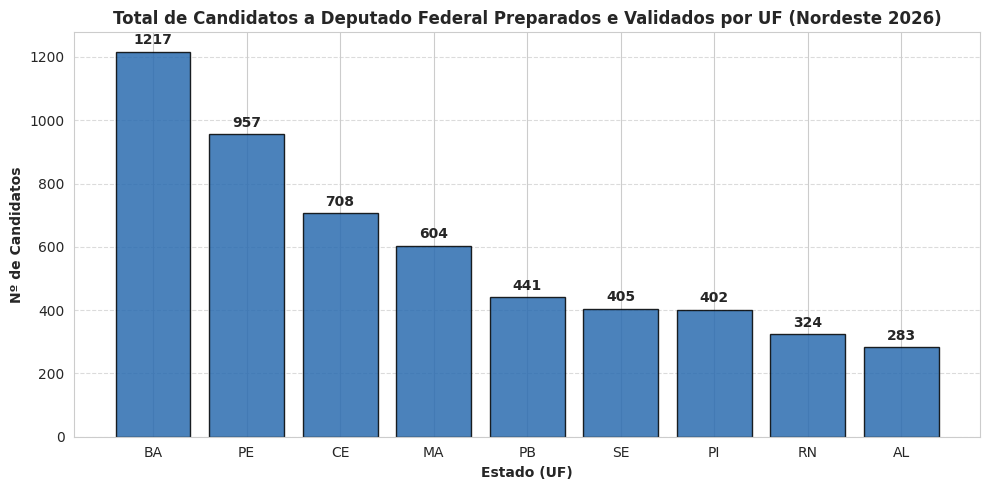

Imagem salva com sucesso: images/notebook0/01_candidatos_por_uf_preparados.png
Arquivo ZIP gerado: images/notebook0.zip


In [10]:
# ── Exportação de Imagens para Apresentação ────────────────────────────────────
import os
import zipfile
import matplotlib.pyplot as plt

os.makedirs('images/notebook0', exist_ok=True)

# 1. Gráfico de síntese: Total de candidatos validados por UF
fig, ax = plt.subplots(figsize=(10, 5))

# Filtra pela lista de UF e faz a contagem somente na coluna SG_UF
cand_por_uf = df[df['SG_UF'].isin(UF)]['SG_UF'].value_counts()

bars = ax.bar(cand_por_uf.index, cand_por_uf.values, color='#2b6cb0', edgecolor='black', alpha=0.85)
ax.bar_label(bars, fmt='%d', padding=3, fontweight='bold')
ax.set_title('Total de Candidatos a Deputado Federal Preparados e Validados por UF (Nordeste 2026)', fontsize=12, fontweight='bold')
ax.set_xlabel('Estado (UF)', fontweight='bold')
ax.set_ylabel('Nº de Candidatos', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

img_path = 'images/notebook0/01_candidatos_por_uf_preparados.png'
plt.savefig(img_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Imagem salva com sucesso: {img_path}")

# Compactar imagens do notebook 0 em zip para download fácil
zip_path = 'images/notebook0.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook0'):
        for file in files:
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)
print(f"Arquivo ZIP gerado: {zip_path}")

# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()
import os
os.makedirs('images/notebook1', exist_ok=True)

Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2189 candidatos, 64 colunas


2189 candidatos x 64 colunas



object     31
int64      21
float64    12
Name: nº de colunas, dtype: int64

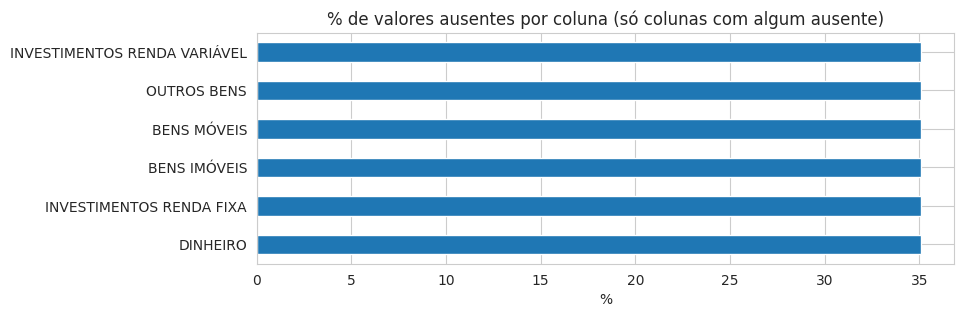

In [12]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.savefig('images/notebook1/01_valores_ausentes.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo (`df.columns` mostra tudo o que está disponível).

In [13]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
...,...
59,Total_Despesas_Pagas
60,Total_Despesas_Contratadas_Log
61,Total_Despesas_Pagas_Log
62,ANOS_ESTUDO


In [14]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'Total_Despesas_Contratadas',
    'Total_Despesas_Contratadas_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'SG_PARTIDO',
    'SG_UF',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print(f"{len(colunas_numericas)} numéricas: {colunas_numericas}")
print(f"{len(colunas_categoricas)} categóricas: {colunas_categoricas}")

11 numéricas: ['IDADE', 'Total_Bens', 'Total_Bens_Log', 'Total_Despesas_Contratadas', 'Total_Despesas_Contratadas_Log', 'BENS MÓVEIS', 'BENS IMÓVEIS', 'DINHEIRO', 'INVESTIMENTOS RENDA FIXA', 'INVESTIMENTOS RENDA VARIÁVEL', 'OUTROS BENS']
6 categóricas: ['DS_GENERO', 'DS_GRAU_INSTRUCAO', 'DS_ESTADO_CIVIL', 'DS_COR_RACA', 'SG_PARTIDO', 'SG_UF']


---
## 3) As 4 Variáveis da Clusterização

Visão geral aprofundada da distribuição das **quatro variáveis motrizes** da clusterização, conforme orientação do professor:
1. **Idade** (contínua/simétrica);
2. **Tempo de Estudo / Grau de Instrução** (categórica ordinal / anos de estudo);
3. **Total de Bens Declarados** (contínua em escala logarítmica com 43% de zeros);
4. **Total de Despesas Contratadas** (contínua em escala logarítmica com 26% de zeros).


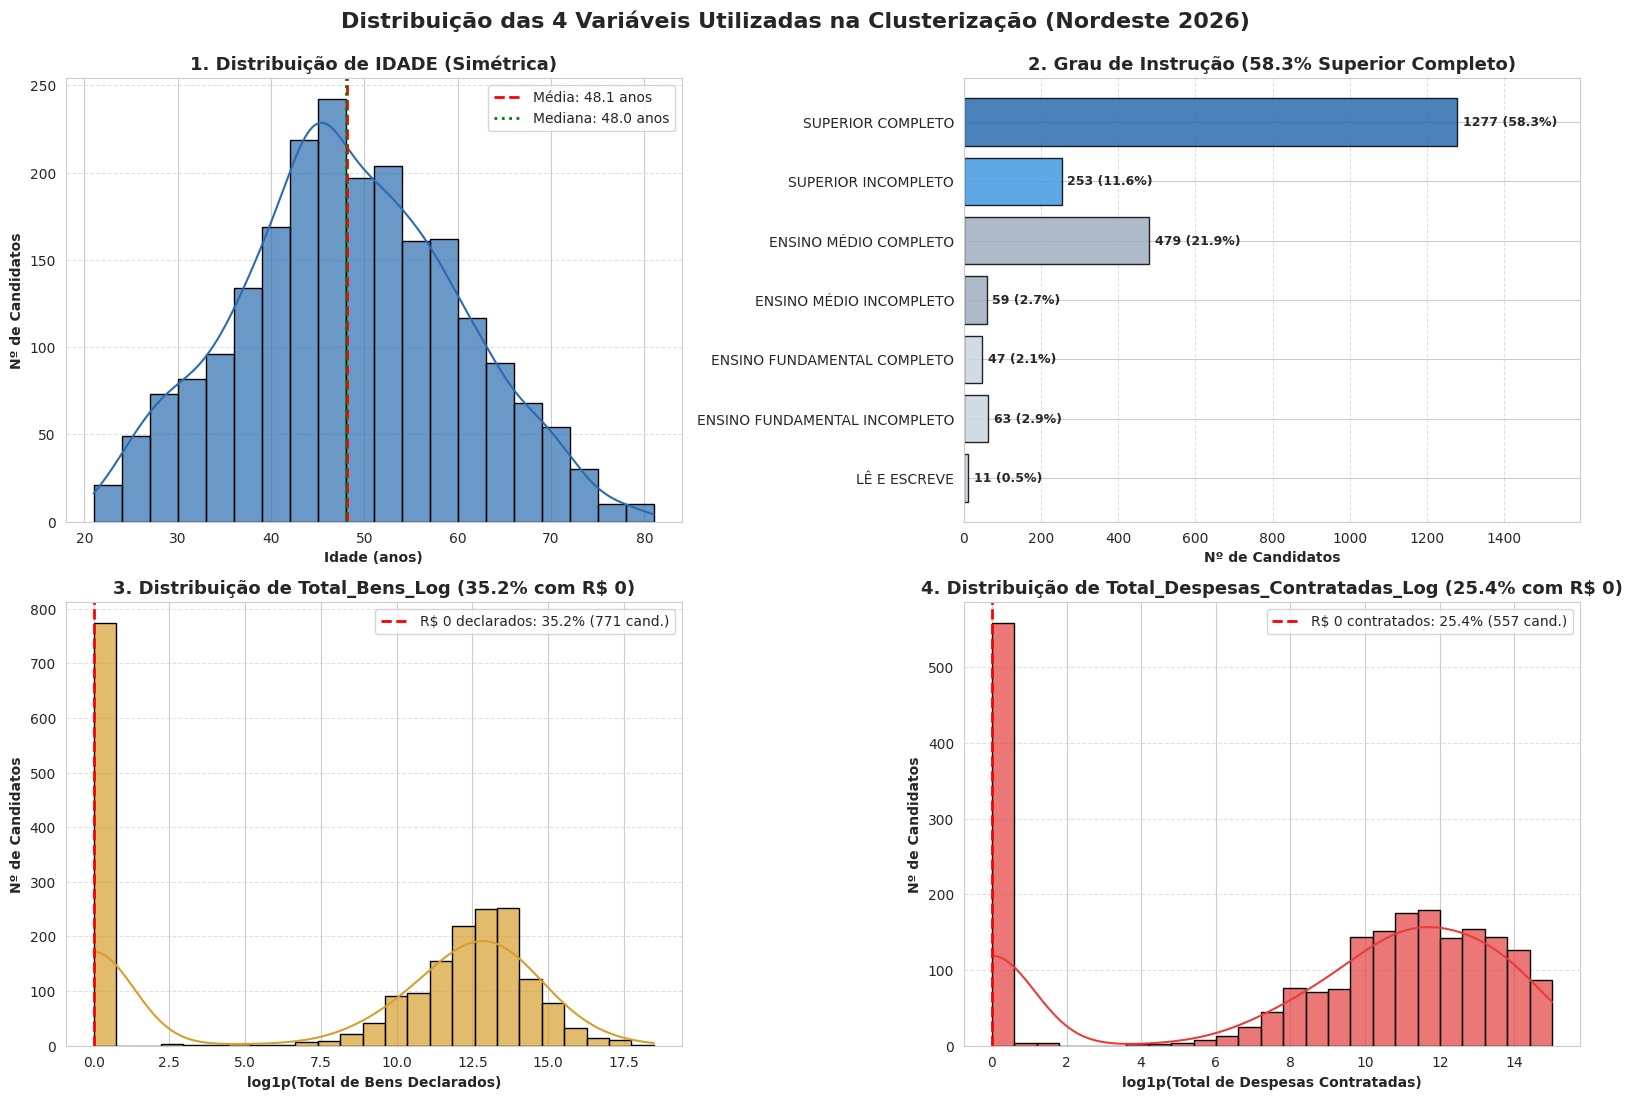

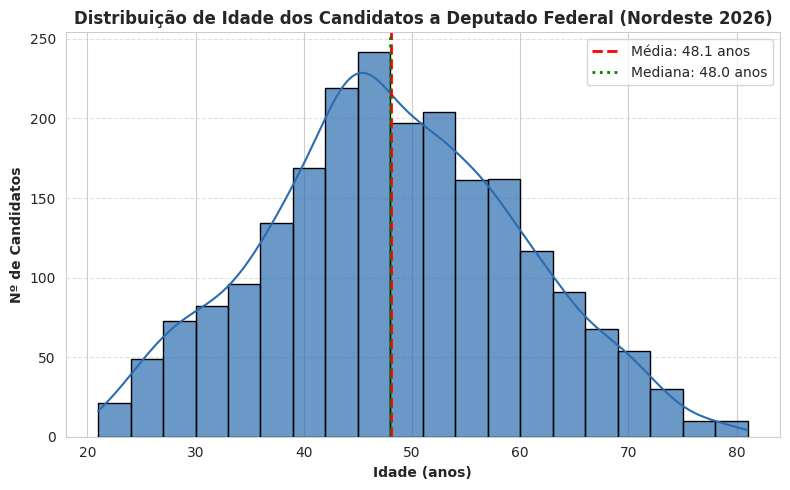

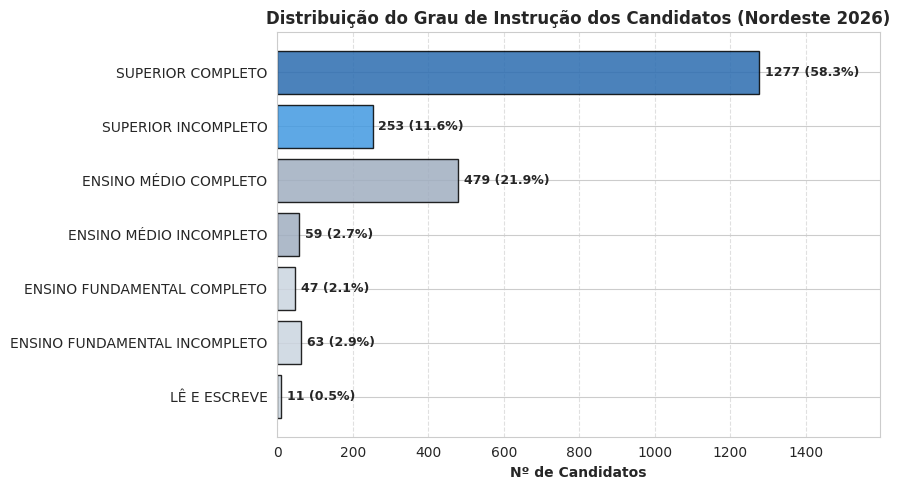

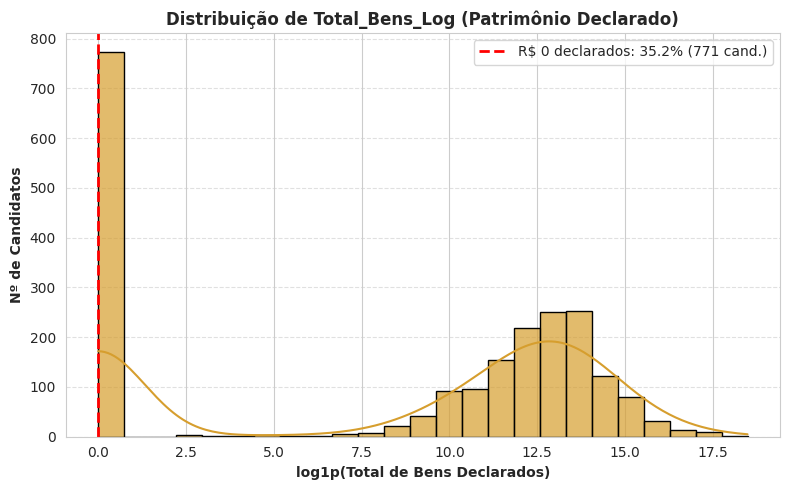

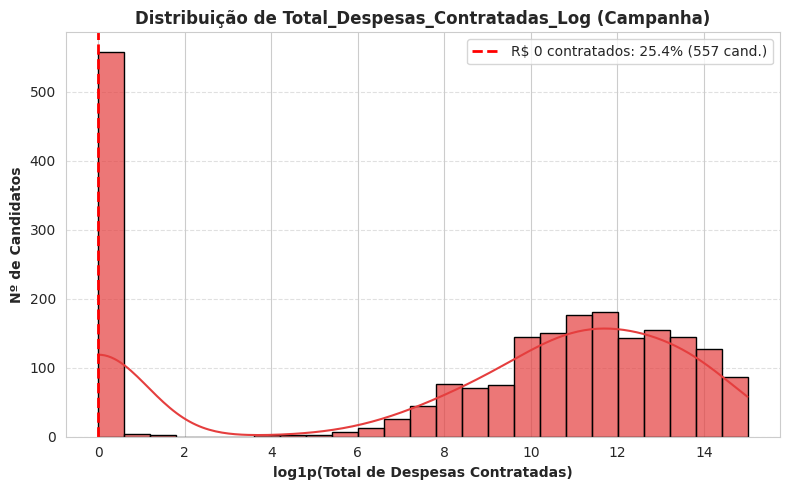

In [15]:
# Grid 2x2 com as 4 variáveis juntas
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. IDADE
sns.histplot(df['IDADE'], bins=20, kde=True, ax=axes[0, 0], color='#2b6cb0', edgecolor='black', alpha=0.7)
media_idade = df['IDADE'].mean()
mediana_idade = df['IDADE'].median()
axes[0, 0].axvline(media_idade, color='red', linestyle='--', linewidth=2, label=f'Média: {media_idade:.1f} anos')
axes[0, 0].axvline(mediana_idade, color='green', linestyle=':', linewidth=2, label=f'Mediana: {mediana_idade:.1f} anos')
axes[0, 0].set_title('1. Distribuição de IDADE (Simétrica)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Idade (anos)', fontweight='bold')
axes[0, 0].set_ylabel('Nº de Candidatos', fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.6)

# 2. GRAU DE INSTRUÇÃO (ANOS DE ESTUDO)
ordem_instrucao = [
    'LÊ E ESCREVE',
    'ENSINO FUNDAMENTAL INCOMPLETO',
    'ENSINO FUNDAMENTAL COMPLETO',
    'ENSINO MÉDIO INCOMPLETO',
    'ENSINO MÉDIO COMPLETO',
    'SUPERIOR INCOMPLETO',
    'SUPERIOR COMPLETO'
]
cont_inst = df['DS_GRAU_INSTRUCAO'].value_counts().reindex(ordem_instrucao).fillna(0)
pct_inst = (cont_inst / len(df) * 100)
cores_inst = ['#cbd5e0', '#cbd5e0', '#cbd5e0', '#a0aec0', '#a0aec0', '#4299e1', '#2b6cb0']

bars = axes[0, 1].barh(cont_inst.index, cont_inst.values, color=cores_inst, edgecolor='black', alpha=0.85)
for bar, pct in zip(bars, pct_inst):
    axes[0, 1].text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                    f'{int(bar.get_width())} ({pct:.1f}%)', va='center', fontsize=9, fontweight='bold')
axes[0, 1].set_title('2. Grau de Instrução (58.3% Superior Completo)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Nº de Candidatos', fontweight='bold')
axes[0, 1].set_xlim(0, max(cont_inst.values) * 1.25)
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.6)

# 3. TOTAL BENS LOG
pct_bens_zero = (df['Total_Bens'] == 0).mean() * 100
sns.histplot(df['Total_Bens_Log'], bins=25, kde=True, ax=axes[1, 0], color='#d69e2e', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label=f'R$ 0 declarados: {pct_bens_zero:.1f}% ({int((df["Total_Bens"] == 0).sum())} cand.)')
axes[1, 0].set_title(f'3. Distribuição de Total_Bens_Log ({pct_bens_zero:.1f}% com R$ 0)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('log1p(Total de Bens Declarados)', fontweight='bold')
axes[1, 0].set_ylabel('Nº de Candidatos', fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

# 4. TOTAL DESPESAS CONTRATADAS LOG
pct_desp_zero = (df['Total_Despesas_Contratadas'] == 0).mean() * 100
sns.histplot(df['Total_Despesas_Contratadas_Log'], bins=25, kde=True, ax=axes[1, 1], color='#e53e3e', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2, label=f'R$ 0 contratados: {pct_desp_zero:.1f}% ({int((df["Total_Despesas_Contratadas"] == 0).sum())} cand.)')
axes[1, 1].set_title(f'4. Distribuição de Total_Despesas_Contratadas_Log ({pct_desp_zero:.1f}% com R$ 0)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('log1p(Total de Despesas Contratadas)', fontweight='bold')
axes[1, 1].set_ylabel('Nº de Candidatos', fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Distribuição das 4 Variáveis Utilizadas na Clusterização (Nordeste 2026)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('images/notebook1/02_distribuicao_4_drivers_clusterizacao.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Gerando também os 4 Histogramas Separados Individualmente ─────────────────
# 1. Idade
plt.figure(figsize=(8, 5))
sns.histplot(df['IDADE'], bins=20, kde=True, color='#2b6cb0', edgecolor='black', alpha=0.7)
plt.axvline(media_idade, color='red', linestyle='--', linewidth=2, label=f'Média: {media_idade:.1f} anos')
plt.axvline(mediana_idade, color='green', linestyle=':', linewidth=2, label=f'Mediana: {mediana_idade:.1f} anos')
plt.title('Distribuição de Idade dos Candidatos a Deputado Federal (Nordeste 2026)', fontsize=12, fontweight='bold')
plt.xlabel('Idade (anos)', fontweight='bold')
plt.ylabel('Nº de Candidatos', fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook1/hist_01_idade.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Grau de Instrução
plt.figure(figsize=(9, 5))
bars = plt.barh(cont_inst.index, cont_inst.values, color=cores_inst, edgecolor='black', alpha=0.85)
for bar, pct in zip(bars, pct_inst):
    plt.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())} ({pct:.1f}%)', va='center', fontsize=9, fontweight='bold')
plt.title('Distribuição do Grau de Instrução dos Candidatos (Nordeste 2026)', fontsize=12, fontweight='bold')
plt.xlabel('Nº de Candidatos', fontweight='bold')
plt.xlim(0, max(cont_inst.values) * 1.25)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook1/hist_02_grau_instrucao.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Total de Bens (Log)
plt.figure(figsize=(8, 5))
sns.histplot(df['Total_Bens_Log'], bins=25, kde=True, color='#d69e2e', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label=f'R$ 0 declarados: {pct_bens_zero:.1f}% ({int((df["Total_Bens"] == 0).sum())} cand.)')
plt.title(f'Distribuição de Total_Bens_Log (Patrimônio Declarado)', fontsize=12, fontweight='bold')
plt.xlabel('log1p(Total de Bens Declarados)', fontweight='bold')
plt.ylabel('Nº de Candidatos', fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook1/hist_03_total_bens_log.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Total de Despesas Contratadas (Log)
plt.figure(figsize=(8, 5))
sns.histplot(df['Total_Despesas_Contratadas_Log'], bins=25, kde=True, color='#e53e3e', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label=f'R$ 0 contratados: {pct_desp_zero:.1f}% ({int((df["Total_Despesas_Contratadas"] == 0).sum())} cand.)')
plt.title(f'Distribuição de Total_Despesas_Contratadas_Log (Campanha)', fontsize=12, fontweight='bold')
plt.xlabel('log1p(Total de Despesas Contratadas)', fontweight='bold')
plt.ylabel('Nº de Candidatos', fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook1/hist_04_total_despesas_contratadas_log.png', dpi=300, bbox_inches='tight')
plt.show()


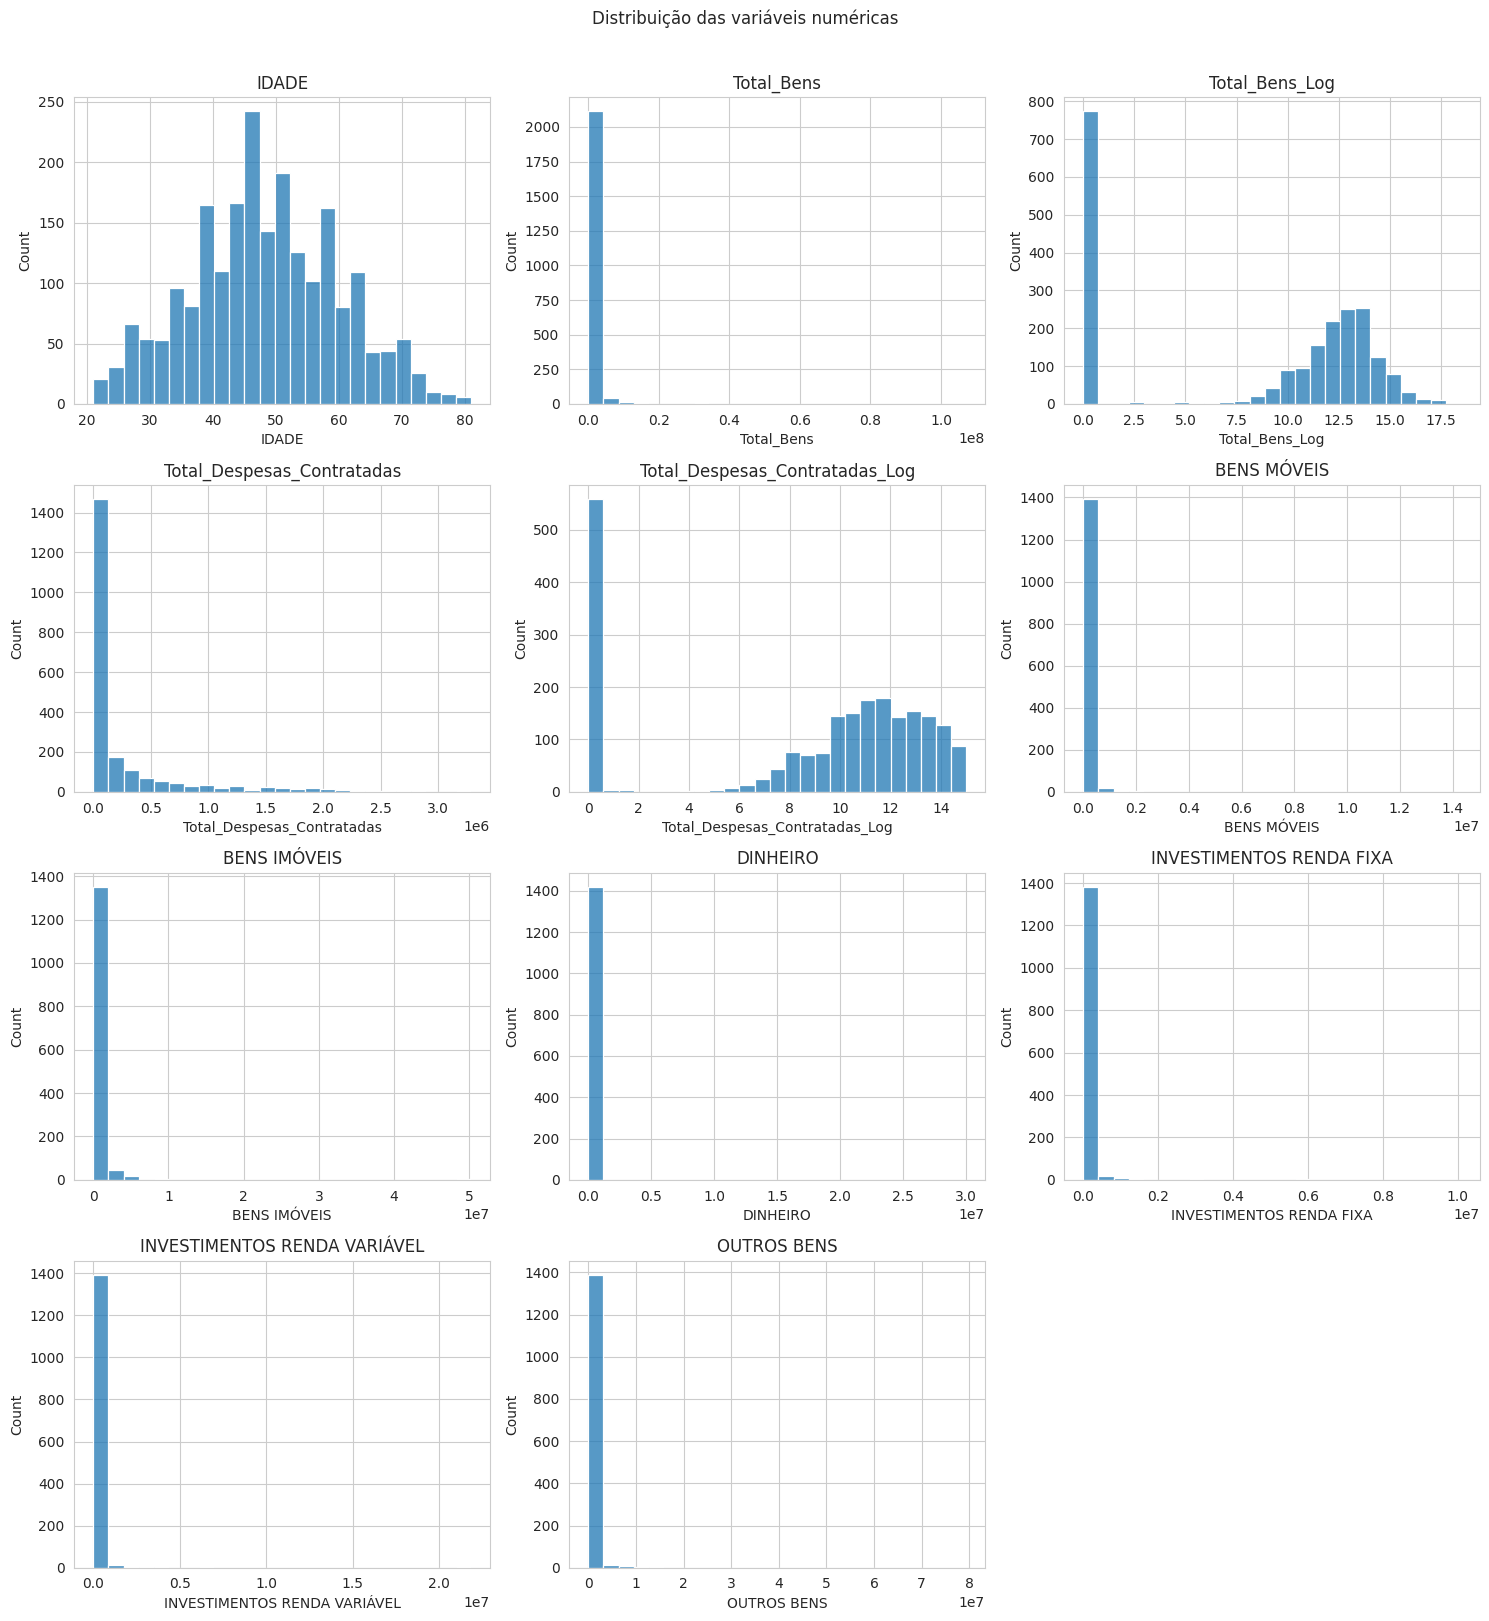

In [16]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.savefig('images/notebook1/02_histogramas_variaveis_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

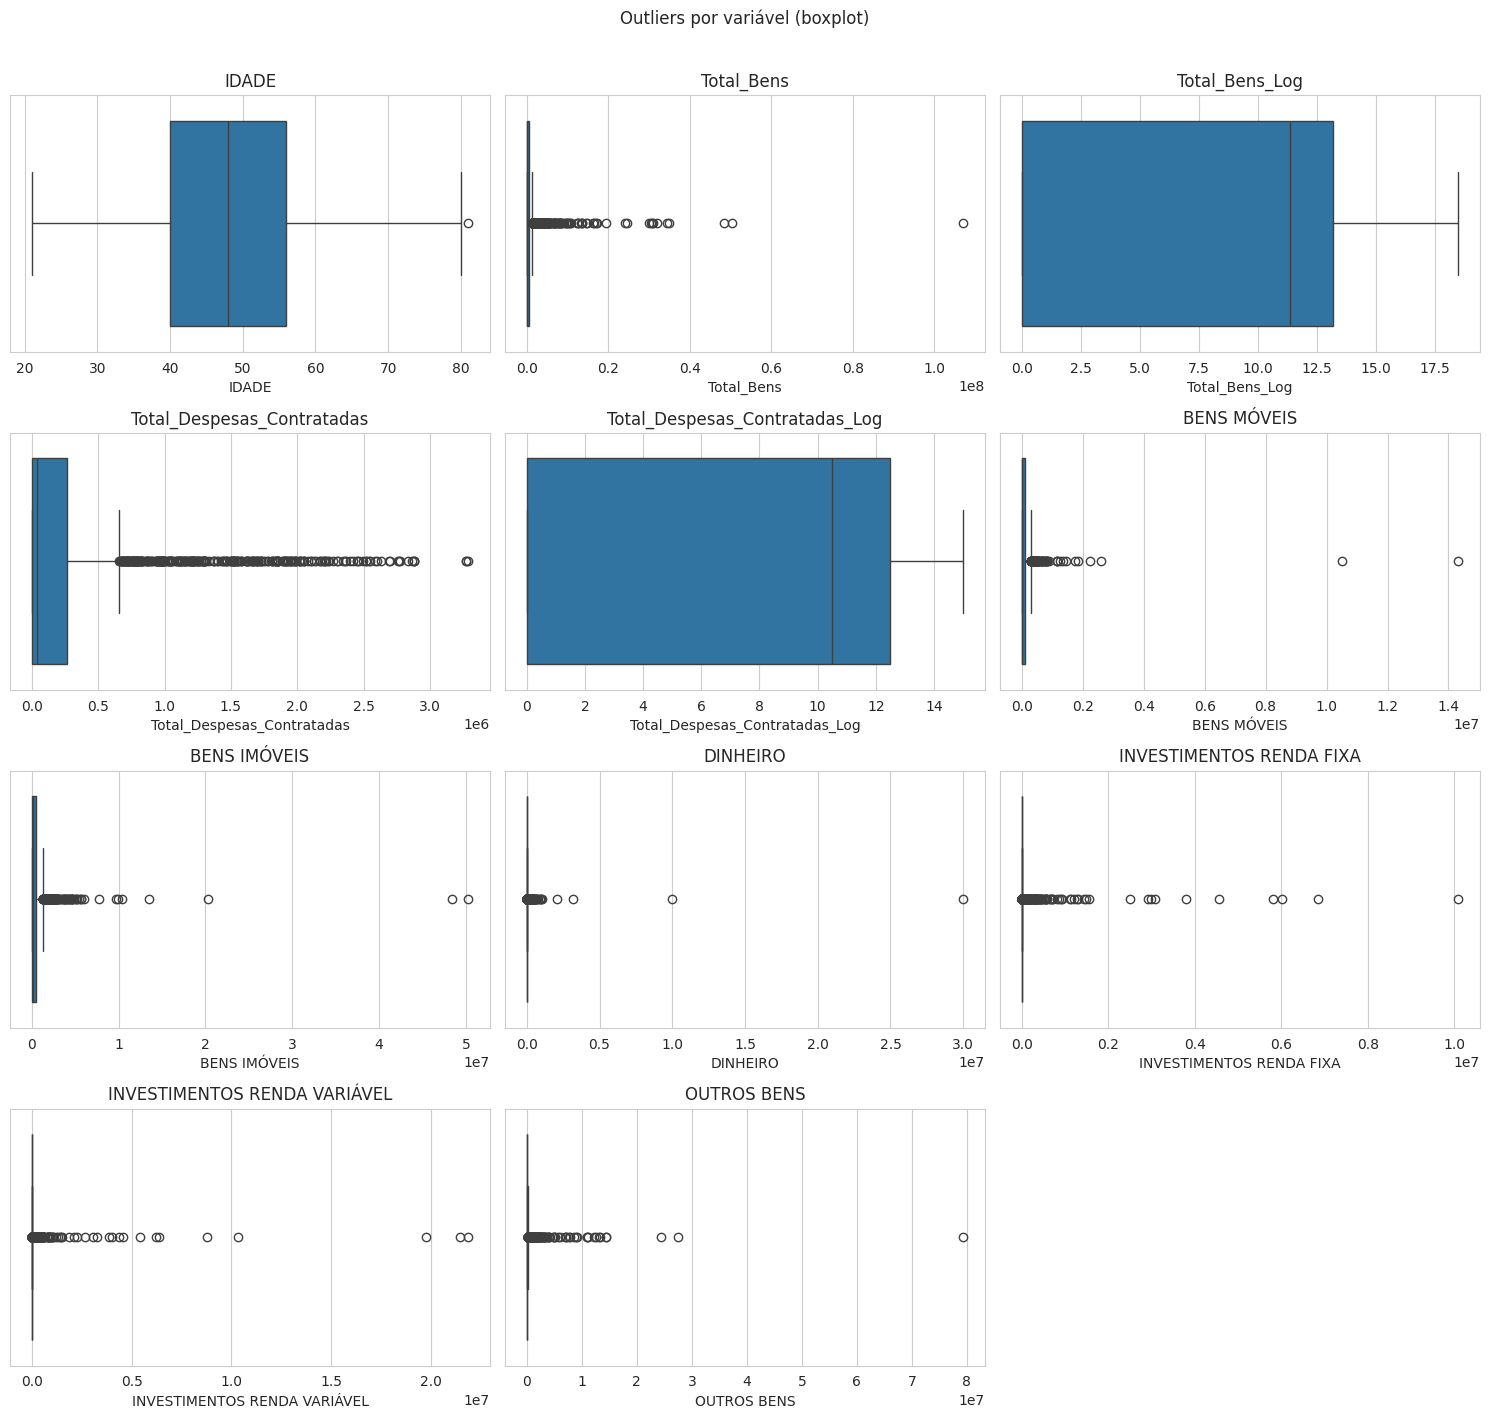

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.savefig('images/notebook1/03_boxplots_variaveis_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [18]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
7,DINHEIRO,"-1,313.76","2,189.60",330,15.10
8,INVESTIMENTOS RENDA FIXA,0.00,0.00,322,14.70
3,Total_Despesas_Contratadas,"-394,179.00","656,965.00",310,14.20
9,INVESTIMENTOS RENDA VARIÁVEL,0.00,0.00,272,12.40
10,OUTROS BENS,"-88,500.00","147,500.00",267,12.20
1,Total_Bens,"-810,000.00","1,350,000.00",241,11.00
6,BENS IMÓVEIS,"-750,000.00","1,250,000.00",132,6.00
5,BENS MÓVEIS,"-178,500.00","297,500.00",123,5.60
0,IDADE,16.00,80.00,1,0.00
2,Total_Bens_Log,-19.80,33.00,0,0.00


## 4) Variáveis categóricas: contagens e proporções

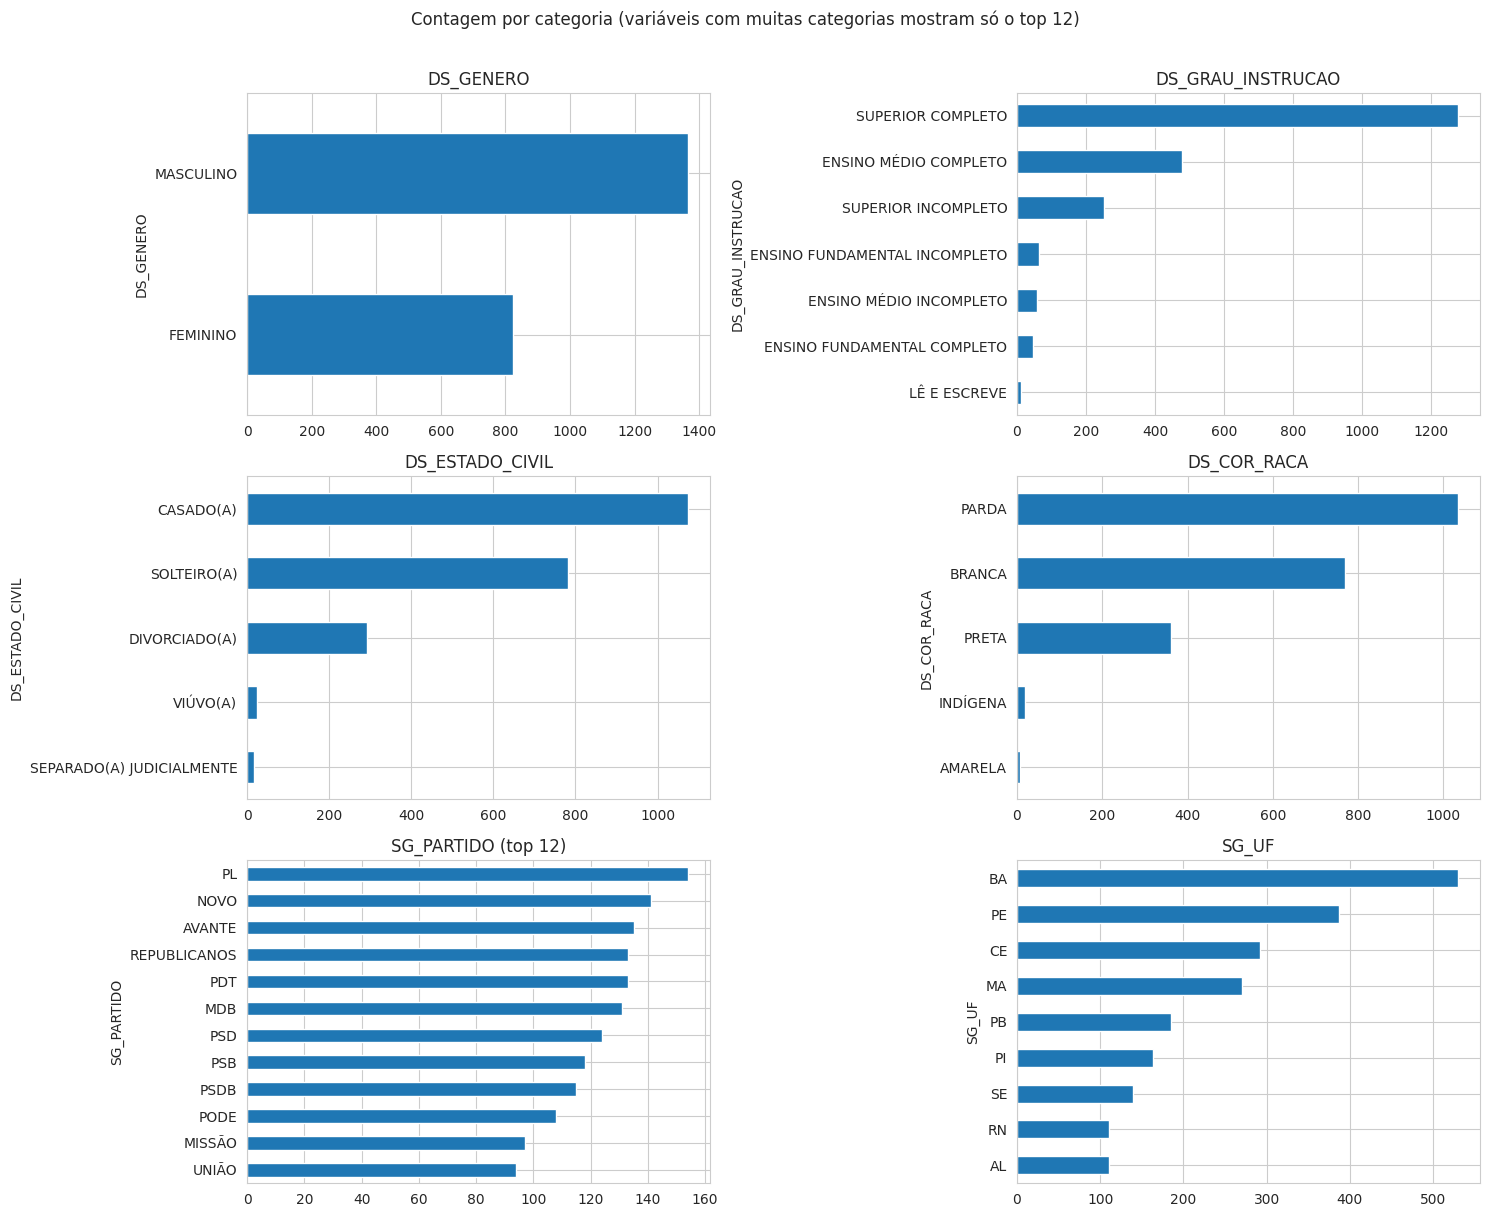

In [19]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.savefig('images/notebook1/04_distribuicao_variaveis_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

--- DS_GENERO (2 categorias) ---
DS_GENERO
MASCULINO    62.4%
FEMININO     37.6%
Name: proportion, dtype: object

--- DS_GRAU_INSTRUCAO (7 categorias) ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                58.3%
ENSINO MÉDIO COMPLETO            21.9%
SUPERIOR INCOMPLETO              11.6%
ENSINO FUNDAMENTAL INCOMPLETO     2.9%
ENSINO MÉDIO INCOMPLETO           2.7%
ENSINO FUNDAMENTAL COMPLETO       2.1%
LÊ E ESCREVE                      0.5%
Name: proportion, dtype: object

--- DS_ESTADO_CIVIL (5 categorias) ---
DS_ESTADO_CIVIL
CASADO(A)                    49.1%
SOLTEIRO(A)                  35.7%
DIVORCIADO(A)                13.3%
VIÚVO(A)                      1.1%
SEPARADO(A) JUDICIALMENTE     0.8%
Name: proportion, dtype: object

--- DS_COR_RACA (5 categorias) ---
DS_COR_RACA
PARDA       47.2%
BRANCA      35.1%
PRETA       16.4%
INDÍGENA     0.9%
AMARELA      0.4%
Name: proportion, dtype: object

--- SG_PARTIDO (28 categorias) ---
SG_PARTIDO
PL              7.0%
NOVO            6.4%


## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

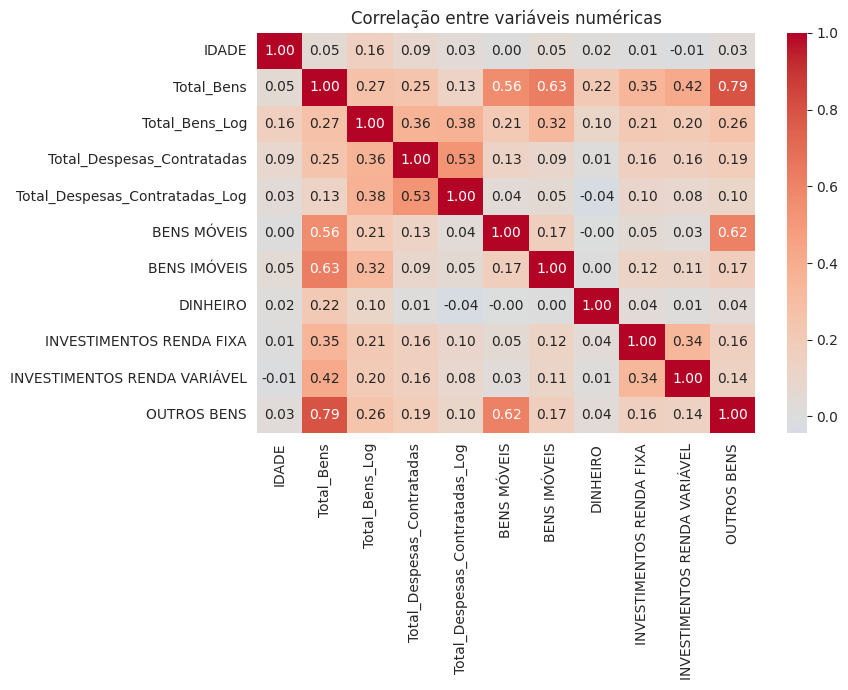

In [21]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.savefig('images/notebook1/05_correlacao_variaveis_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

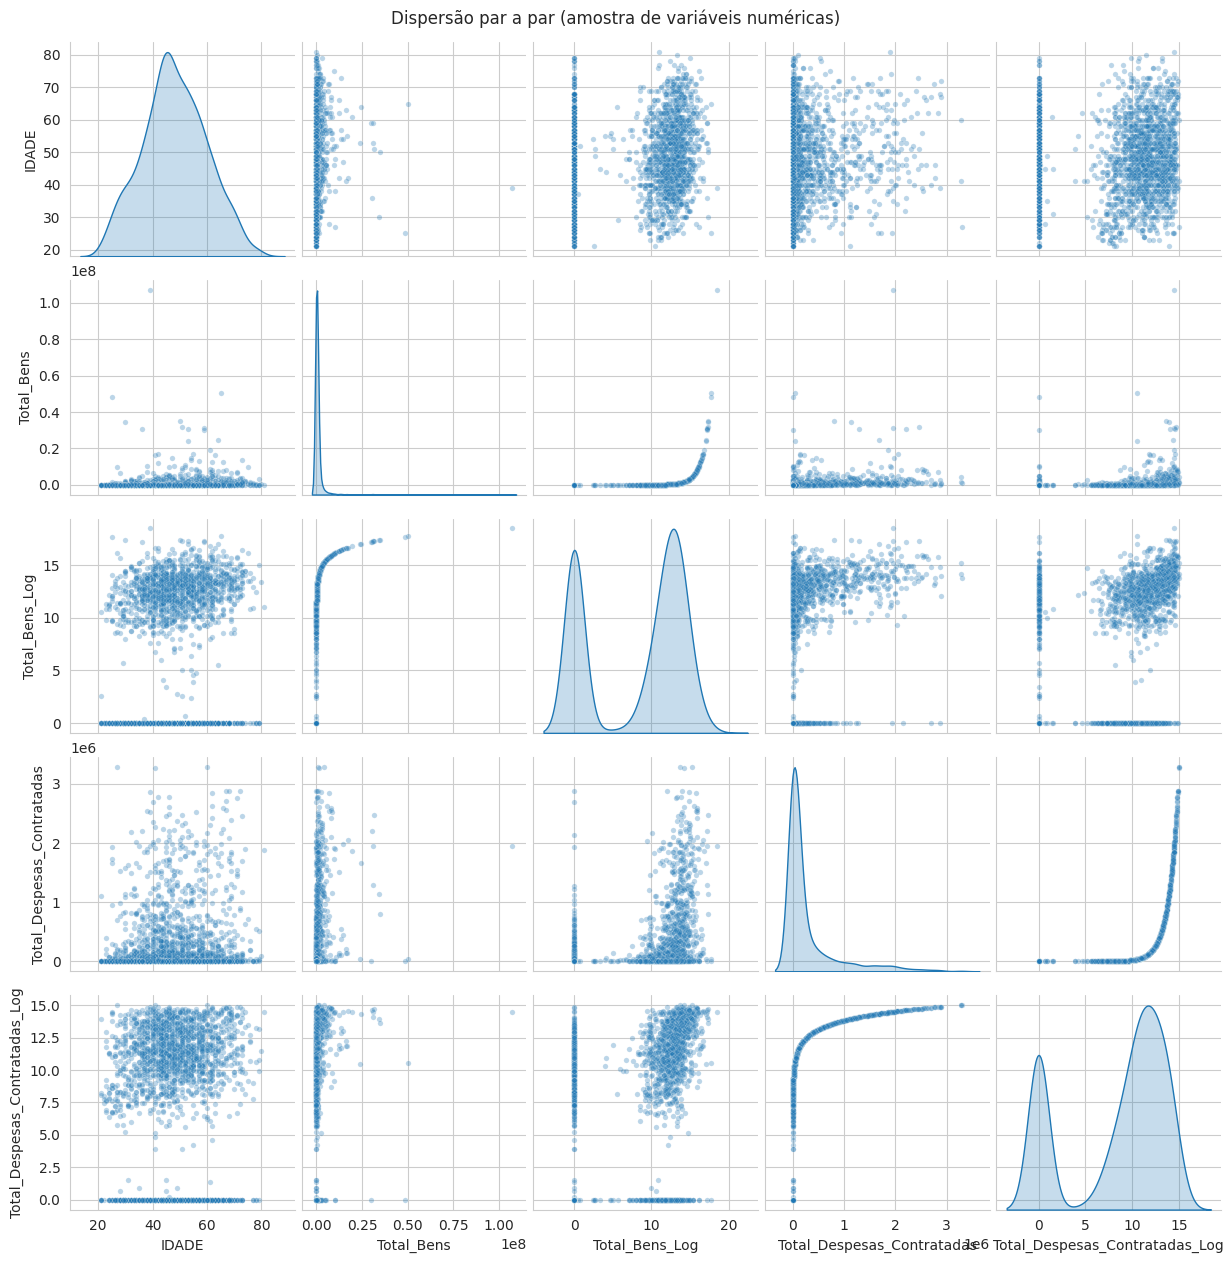

In [22]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
g = sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
g.savefig('images/notebook1/06_pairplot_dispersao.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

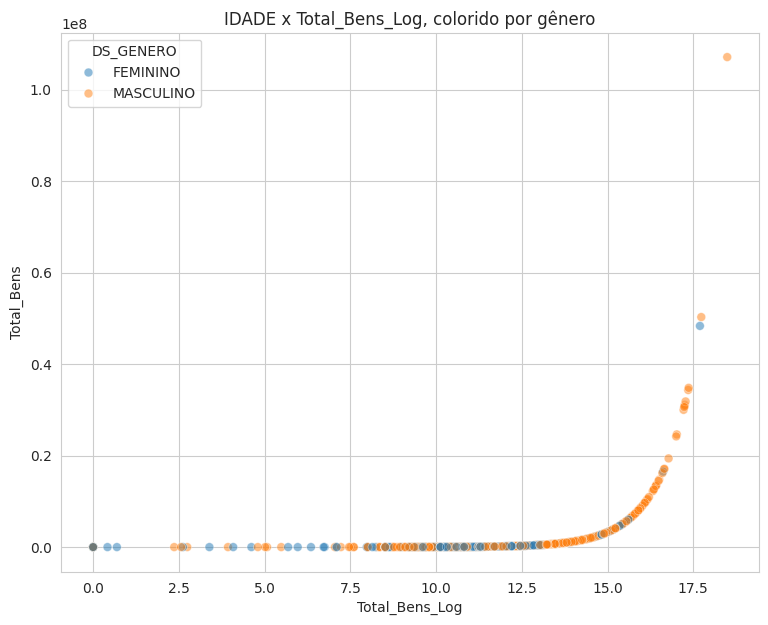

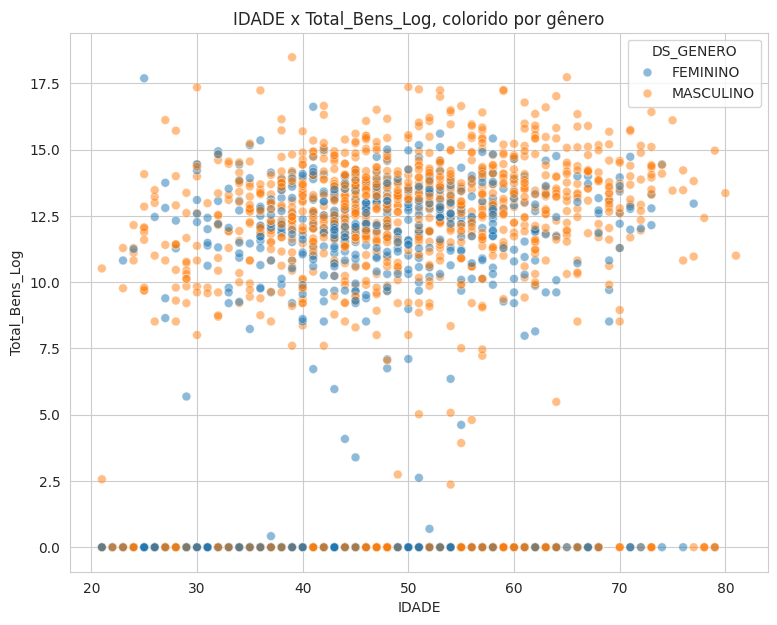

In [23]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='Total_Bens_Log', y='Total_Bens', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.savefig('images/notebook1/07_idade_vs_bens_genero.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.savefig('images/notebook1/07_idade_vs_bens_genero.png', dpi=300, bbox_inches='tight')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

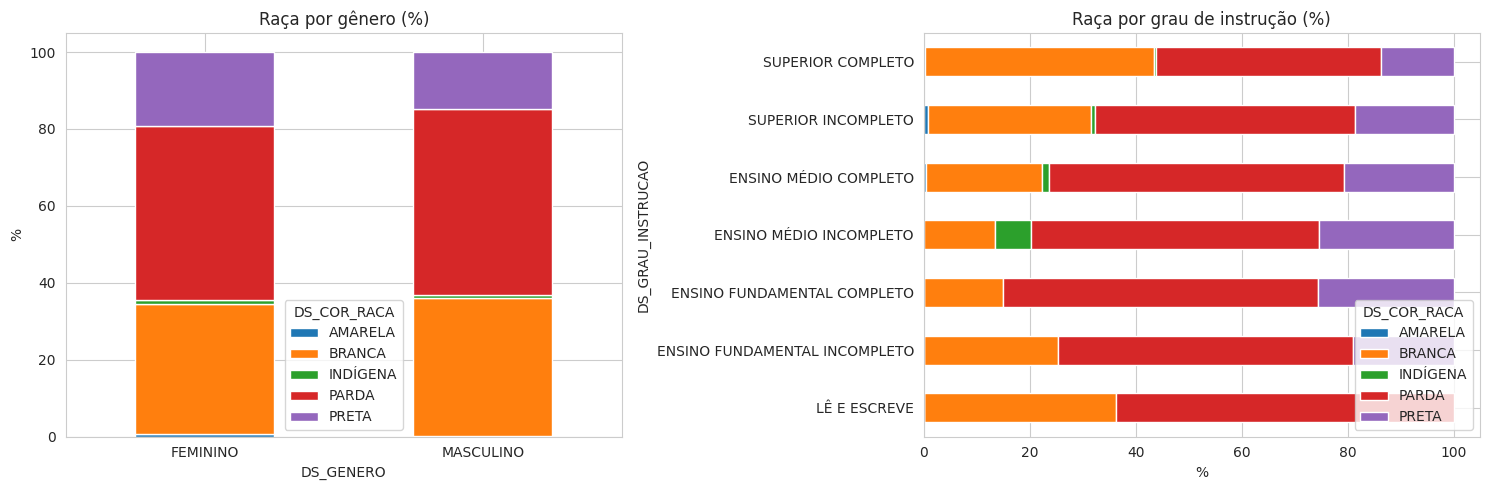

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_COR_RACA'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Raça por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_COR_RACA'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Raça por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.savefig('images/notebook1/08_raca_por_genero.png', dpi=300, bbox_inches='tight')
plt.show()

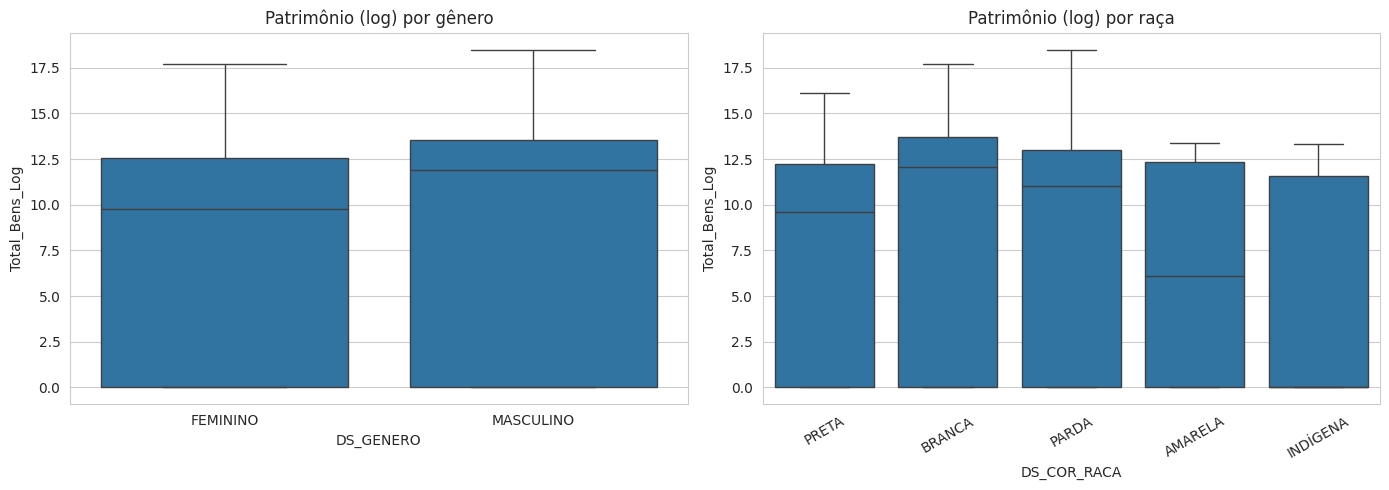

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_COR_RACA', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('images/notebook1/09_patrimonio_por_genero.png', dpi=300, bbox_inches='tight')
plt.show()

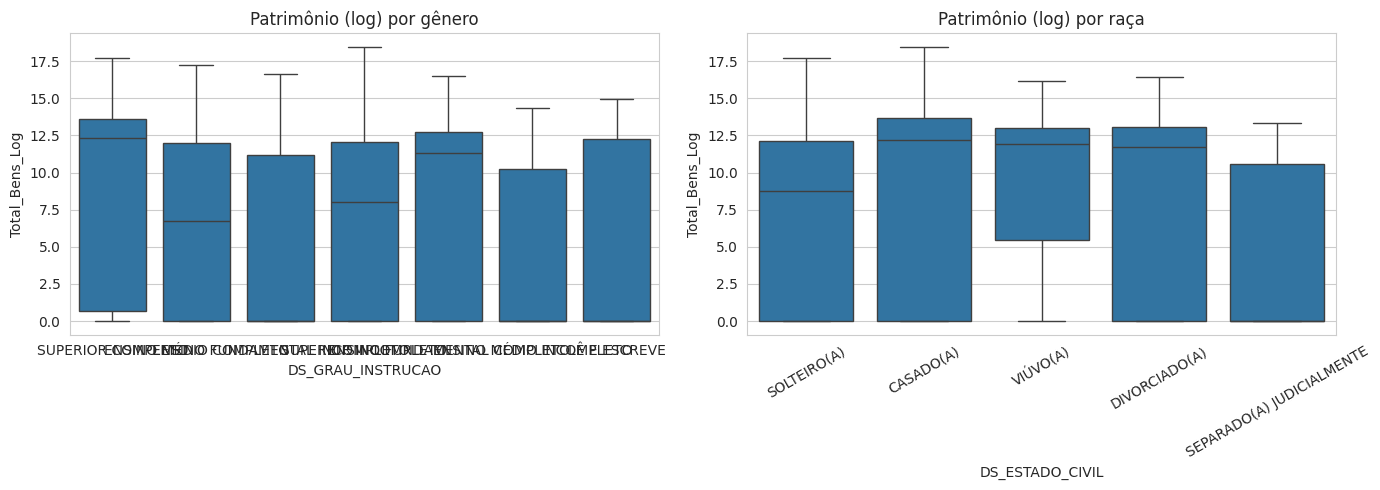

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GRAU_INSTRUCAO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_ESTADO_CIVIL', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('images/notebook1/10_patrimonio_por_raca.png', dpi=300, bbox_inches='tight')
plt.show()

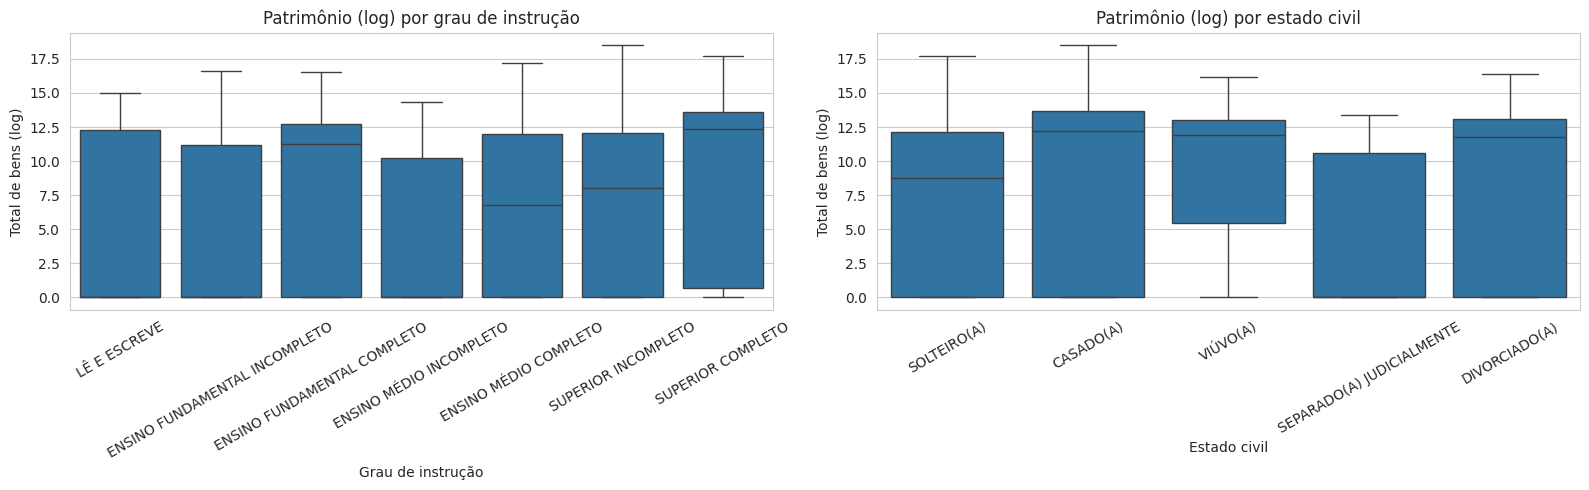

In [27]:
# Ordem do grau de instrução pelo respectivo código
ordem_instrucao = (
    df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']]
    .drop_duplicates()
    .sort_values('CD_GRAU_INSTRUCAO')
    ['DS_GRAU_INSTRUCAO']
    .tolist()
)

# Ordem do estado civil pelo respectivo código
ordem_estado_civil = (
    df[['CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL']]
    .drop_duplicates()
    .sort_values('CD_ESTADO_CIVIL')
    ['DS_ESTADO_CIVIL']
    .tolist()
)


# Cria os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Grau de instrução
sns.boxplot(
    data=df,
    x='DS_GRAU_INSTRUCAO',
    y='Total_Bens_Log',
    order=ordem_instrucao,
    ax=axes[0]
)

axes[0].set_title('Patrimônio (log) por grau de instrução')
axes[0].set_xlabel('Grau de instrução')
axes[0].set_ylabel('Total de bens (log)')
axes[0].tick_params(axis='x', rotation=30)


# Estado civil
sns.boxplot(
    data=df,
    x='DS_ESTADO_CIVIL',
    y='Total_Bens_Log',
    order=ordem_estado_civil,
    ax=axes[1]
)

axes[1].set_title('Patrimônio (log) por estado civil')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Total de bens (log)')
axes[1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.savefig('images/notebook1/11_patrimonio_por_grau_instrucao.png', dpi=300, bbox_inches='tight')
plt.show()

## 7) Comparação entre UFs

Comparação entre os 9 estados do Nordeste

### 7.1 Candidatos por UF

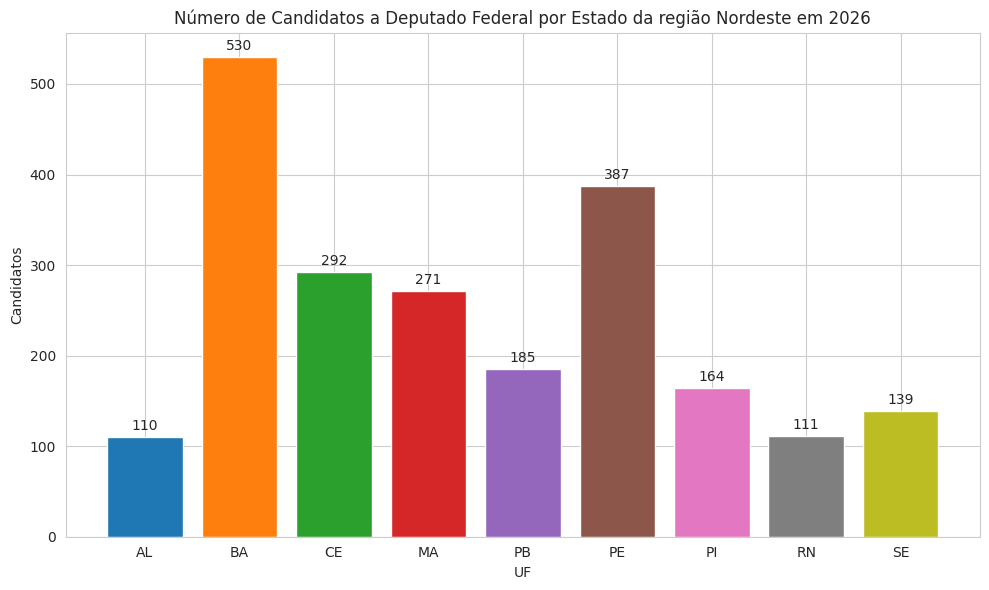

       Candidatos  % do total
SG_UF                        
AL            110        5.00
BA            530       24.20
CE            292       13.30
MA            271       12.40
PB            185        8.50
PE            387       17.70
PI            164        7.50
RN            111        5.10
SE            139        6.30


In [28]:
cand_por_uf = df['SG_UF'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(cand_por_uf.index, cand_por_uf.values,
              color=sns.color_palette('tab10', len(cand_por_uf)))
ax.bar_label(bars, padding=3)
ax.set_title('Número de Candidatos a Deputado Federal por Estado da região Nordeste em 2026')
ax.set_xlabel('UF')
ax.set_ylabel('Candidatos')
plt.tight_layout()
plt.savefig('images/notebook1/12_candidatos_por_uf.png', dpi=300, bbox_inches='tight')
plt.show()

print(pd.DataFrame({'Candidatos': cand_por_uf, '% do total':
                    (cand_por_uf / len(df) * 100).round(1)}))

> Observações: É possível notar uma maior concentração de candidatos na Bahia, quase 25% do total de candidatos do Nordeste.

### 7.2 Patrimônio por UF (Mediana e média)

In [29]:
pat_mediana = df.groupby('SG_UF')['Total_Bens'].median().sort_values()
pat_media = df.groupby('SG_UF')['Total_Bens'].mean().reindex(pat_mediana.index)
print(pat_mediana)
print(pat_media)

SG_UF
PI    17,039.08
RN    18,000.00
PB    23,000.00
PE    72,887.43
AL    78,500.00
BA    80,000.00
SE    92,000.00
CE   101,000.00
MA   250,000.00
Name: Total_Bens, dtype: float64
SG_UF
PI   1,111,525.70
RN     339,233.52
PB     549,882.54
PE     854,766.35
AL   1,072,330.27
BA     893,530.38
SE     591,658.28
CE     779,260.49
MA   1,004,082.47
Name: Total_Bens, dtype: float64


> Observação: É possível notar uma forte assimetria indicando outliers, algo que vimos em 1.1, para resolvermos isso vamos remover os candidatos que não declararam seus bens (menor ou igual a zero) ou que não possuem bens.

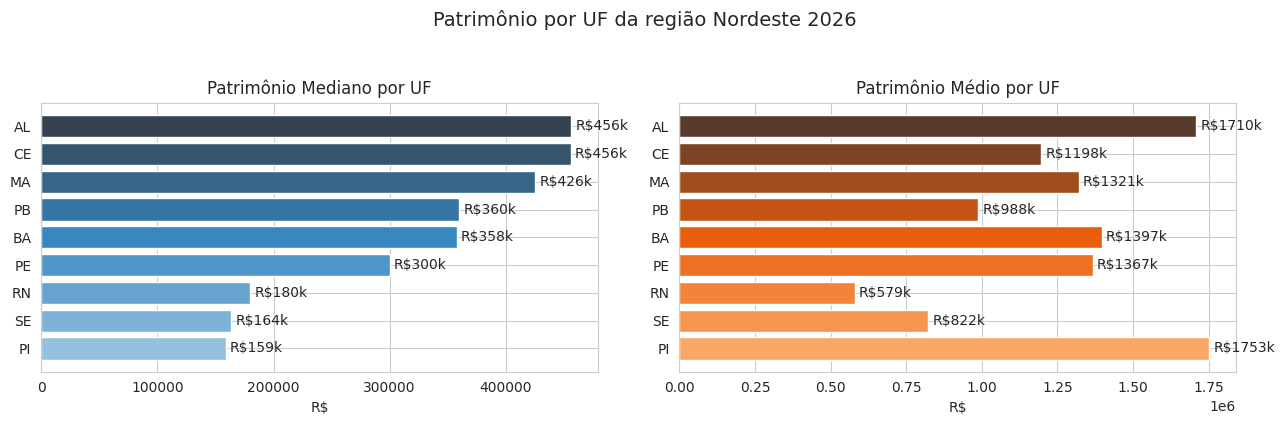

In [30]:
df_pat_sem_zeros = df[df['Total_Bens'] > 0]
pat_mediana = df_pat_sem_zeros.groupby('SG_UF')['Total_Bens'].median().sort_values()
pat_media = df_pat_sem_zeros.groupby('SG_UF')['Total_Bens'].mean().reindex(pat_mediana.index)

fig, axes = plt.subplots(1, 2, figsize=(13,4))

fig.suptitle('Patrimônio por UF da região Nordeste 2026', fontsize=14, y=1.05)

bars = axes[0].barh(pat_mediana.index, pat_mediana.values,
                    color=sns.color_palette('Blues_d', len(pat_mediana)))
axes[0].bar_label(bars, labels=[f'R${v/1e3:.0f}k' for v in pat_mediana.values], padding=3)
axes[0].set_title('Patrimônio Mediano por UF')
axes[0].set_xlabel('R$')

bars2 = axes[1].barh(pat_media.index, pat_media.values,
                     color=sns.color_palette('Oranges_d', len(pat_media)))
axes[1].bar_label(bars2, labels=[f'R${v/1e3:.0f}k' for v in pat_media.values], padding=3)
axes[1].set_title('Patrimônio Médio por UF')
axes[1].set_xlabel('R$')

plt.tight_layout()
plt.savefig('images/notebook1/13_patrimonio_mediana_media_uf.png', dpi=300, bbox_inches='tight')
plt.show()

> Observação: Nota-se pelos gráficos que a política regional não é feita por candidatos com perfis financeiros homogêneos, mas sim por uma base enorme de pessoas comuns acompanhada de uma elite financeira minúscula que distorce todo o montante de riqueza declarado. Isso se torna mais visível no exemplo do Piauí (PI), onde a mediana é de R$ 159 mil em patrimônio, enquanto a média salta para R$ 1,75 milhão. Ou seja, um pequeno grupo de candidatos extremamente ricos distorce completamente a média da análise — formando justamente a 'cauda longa' que precisou ser comprimida pela escala logarítmica no histograma do ponto 1.1 para permitir a visualização da distribuição.

### 7.2.1 Distribuição de Patrimônio por UF (log10)

Para visualizarmos melhor esses outliers vamos visualizar o boxplot dos patrimônios por UF com log de base 10.

Obs: Vamos novamente remover os valores menores que 0.

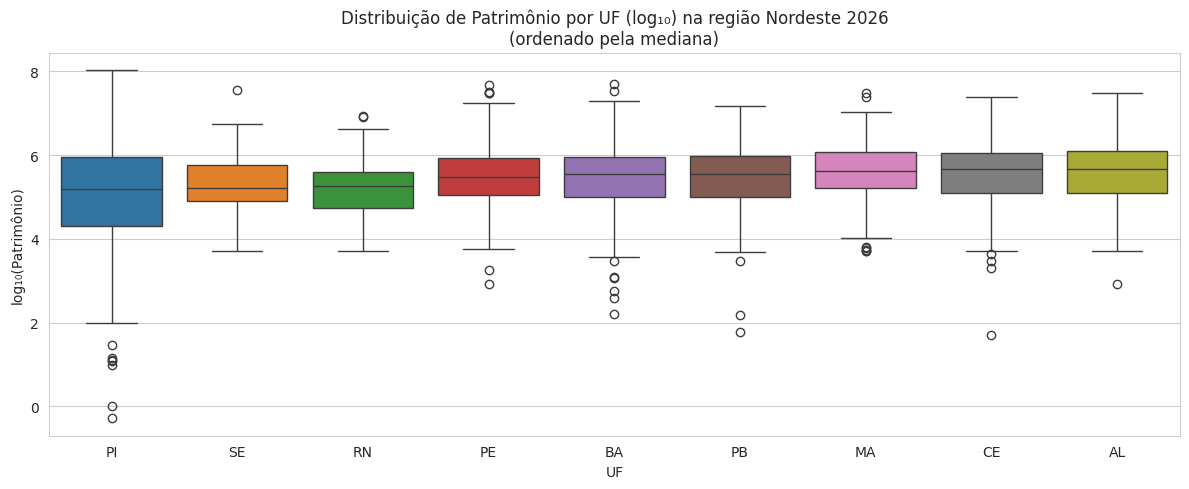

In [31]:
df_plot_uf = df[df['Total_Bens'] > 0].copy()
df_plot_uf['LOG_PAT'] = np.log10(df_plot_uf['Total_Bens'])

ordem_uf = df_plot_uf.groupby('SG_UF')['Total_Bens'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_plot_uf, x='SG_UF', y='LOG_PAT', order=ordem_uf,
            palette='tab10', ax=ax)
ax.set_title('Distribuição de Patrimônio por UF (log₁₀) na região Nordeste 2026\n(ordenado pela mediana)')
ax.set_xlabel('UF')
ax.set_ylabel('log₁₀(Patrimônio)')
plt.tight_layout()
plt.savefig('images/notebook1/14_distribuicao_patrimonio_uf_log.png', dpi=300, bbox_inches='tight')
plt.show()

> Observação: Como podemos ver, o Piauí possui uma grande desigualdade. O boxplot evidencia que o estado tem a maior dispersão (tamanho da caixa) entre todos, mostrando que a riqueza varia drasticamente até mesmo entre os 50% dos candidatos intermediários. A desigualdade é tão estrutural no estado que a caixa alongada empurra o limite da haste superior para valores altíssimos, 'escondendo' os super-ricos dentro do padrão estatístico em escala logarítmica. Além disso, curiosamente, os únicos outliers do estado aparecem na parte inferior, representando candidatos com patrimônios declarados excepcionalmente baixos em relação à média local.

### 7.3 Idade média por UF

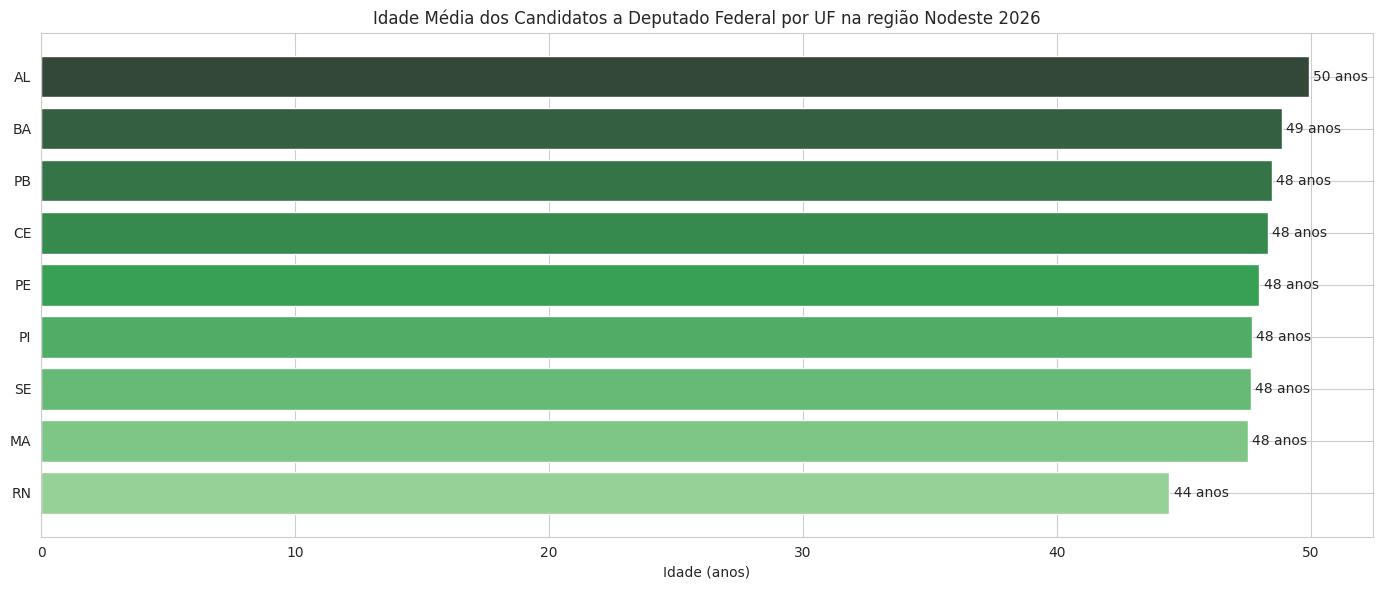

In [32]:
idade_media = df.groupby('SG_UF')['IDADE'].mean().sort_values()

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.barh(idade_media.index, idade_media.values,
               color=sns.color_palette('Greens_d', len(idade_media)))
ax.bar_label(bars, labels=[f'{v:.0f} anos' for v in idade_media], padding=3)
ax.set_title('Idade Média dos Candidatos a Deputado Federal por UF na região Nodeste 2026')
ax.set_xlabel('Idade (anos)')
plt.tight_layout()
plt.savefig('images/notebook1/15_idade_media_por_uf.png', dpi=300, bbox_inches='tight')
plt.show()

> Observação: Aqui podemos notar a simetria por idade que vimos também na região nordeste no geral.

### 7.4 Proporção de Candidatas Mulheres por UF

Para essa analise vamos visualizar a norma presente na Lei das Eleições (Lei nº 9.504/1997), onde exige que partidos assegurem o mínimo de 30% e o máximo de 70% de candidaturas de cada sexo.

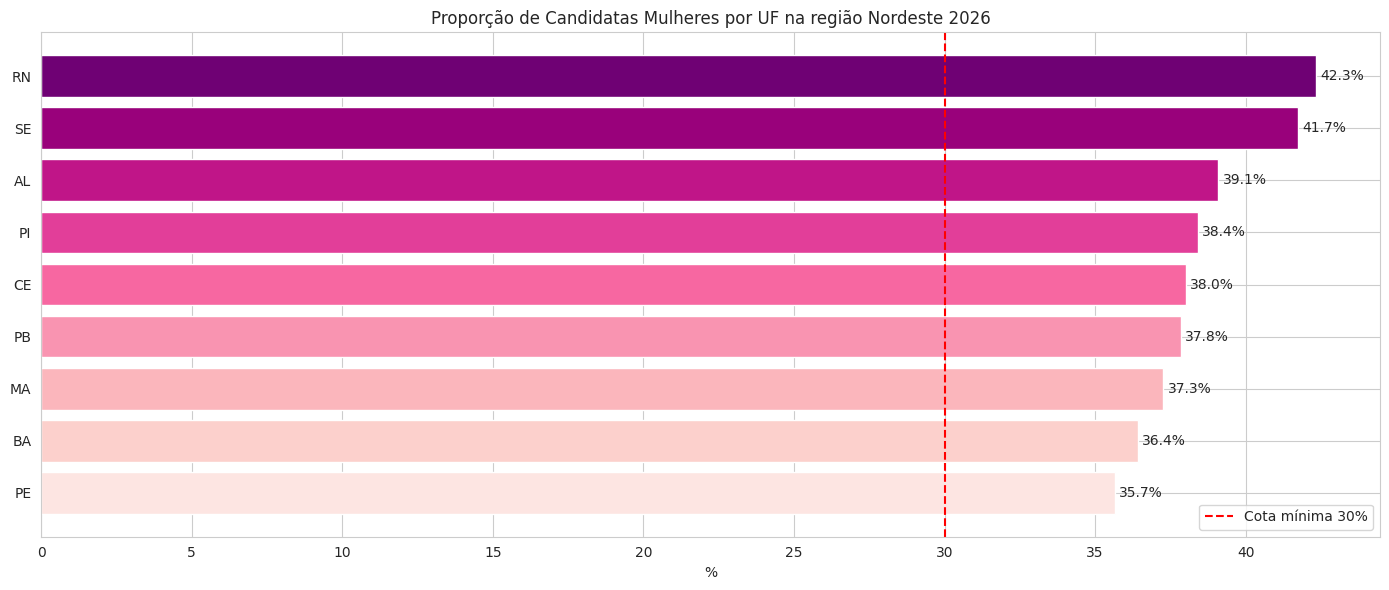

SG_UF
PE   35.70
BA   36.40
MA   37.30
PB   37.80
CE   38.00
PI   38.40
AL   39.10
SE   41.70
RN   42.30
Name: pct_mulheres, dtype: float64


In [33]:
prop_mulheres = (
    df[df['DS_GENERO'].notna()]
    .groupby('SG_UF')
    .apply(lambda x: (x['DS_GENERO'] == 'FEMININO').mean() * 100, include_groups=False)
    .rename('pct_mulheres')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(prop_mulheres.index, prop_mulheres.values,
               color=sns.color_palette('RdPu', len(prop_mulheres)))
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in prop_mulheres.values], padding=3)
ax.axvline(30, color='red', linestyle='--', label='Cota mínima 30%')
ax.set_title('Proporção de Candidatas Mulheres por UF na região Nordeste 2026')
ax.set_xlabel('%')
ax.legend()
plt.tight_layout()
plt.savefig('images/notebook1/16_proporcao_mulheres_por_uf.png', dpi=300, bbox_inches='tight')
plt.show()

print(prop_mulheres.round(1))

> Observação: Como podemos notar, todos os estados respeitaram a cota minima de candidatas e foram além, onde o Rio Grande do Norte quase atinge 50% de candidatas, um excelente indicador de inclusão.

### 7.4.1 Proporção de candidatas mulheres por partidos de cada UF

Vamos separar essa análise por partido, para que possamos compreender melhor quais partidos por estado segue essa lei e quais não.

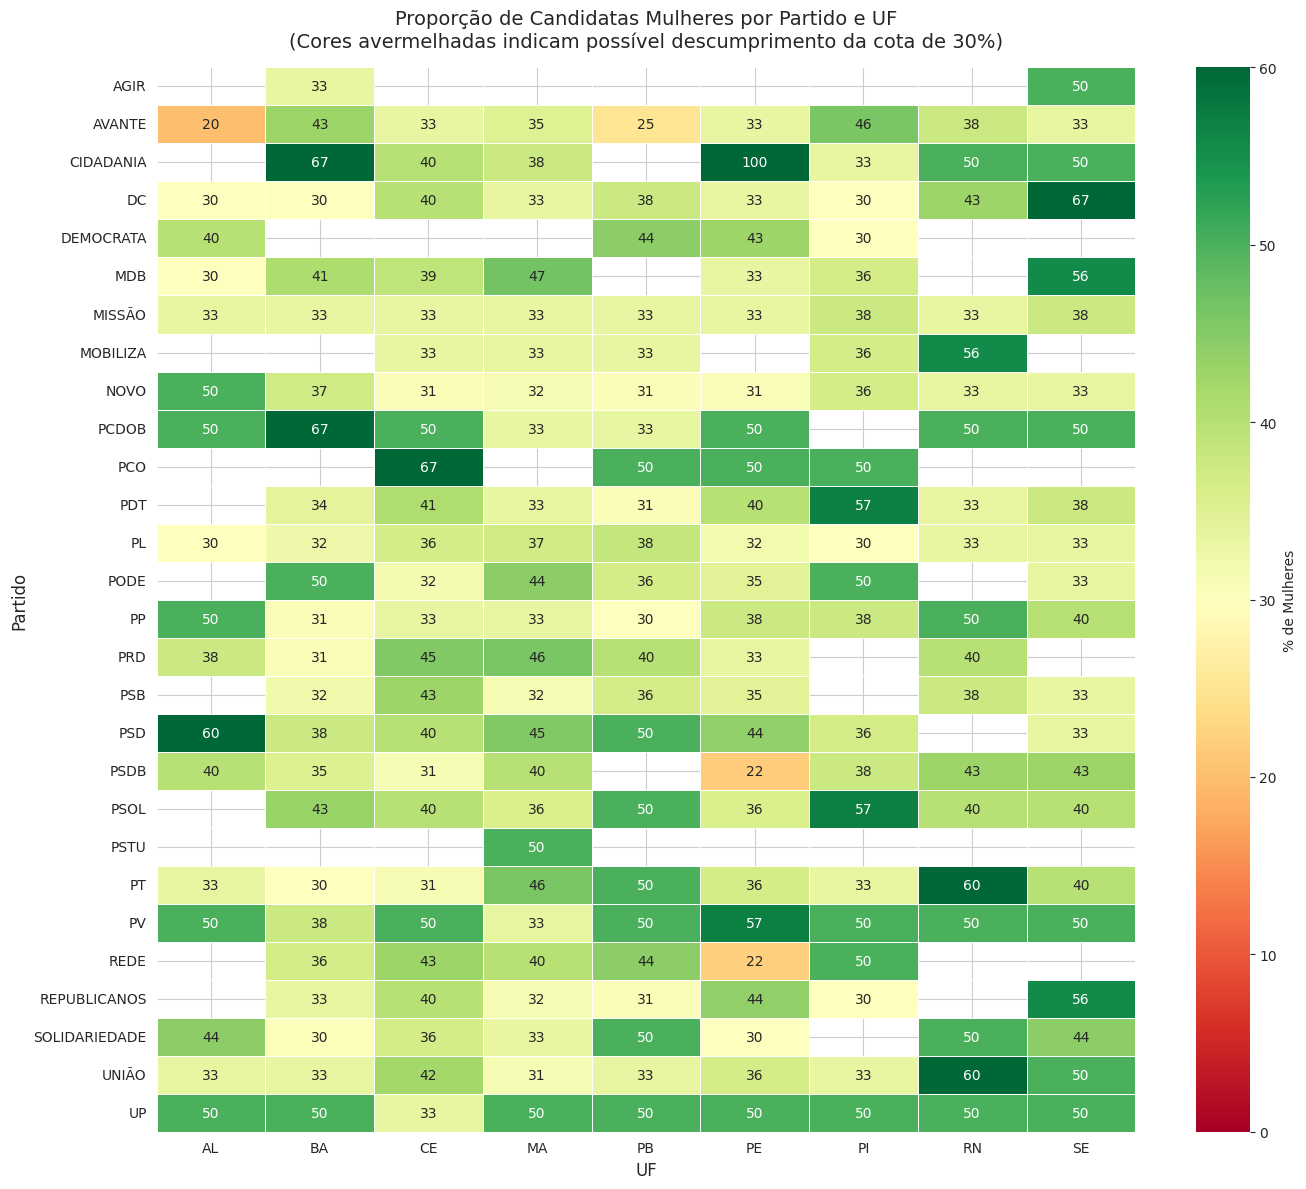

In [34]:
resumo_genero = df[df['DS_GENERO'].notna()].groupby(['SG_UF', 'SG_PARTIDO', 'DS_GENERO']).size().unstack(fill_value=0)

# Calcular o total e a porcentagem de mulheres
resumo_genero['TOTAL'] = resumo_genero.sum(axis=1)
resumo_genero['pct_mulheres'] = (resumo_genero.get('FEMININO', 0) / resumo_genero['TOTAL']) * 100

# Resetar o index para poder pivotar a tabela
df_heatmap = resumo_genero.reset_index()

# Criar a matriz Estado (colunas) x Partido (linhas)
pivot_mulheres = df_heatmap.pivot(index='SG_PARTIDO', columns='SG_UF', values='pct_mulheres')

# Plotar o Heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Usar um colormap divergente onde o centro (30%) divide cores quentes (ruim) e frias/verdes (bom)
sns.heatmap(pivot_mulheres, cmap='RdYlGn', center=30, vmin=0, vmax=60,
            annot=True, fmt=".0f", linewidths=.5, ax=ax,
            cbar_kws={'label': '% de Mulheres'})

ax.set_title('Proporção de Candidatas Mulheres por Partido e UF\n(Cores avermelhadas indicam possível descumprimento da cota de 30%)',
fontsize=14, pad=15)
ax.set_ylabel('Partido', fontsize=12)
ax.set_xlabel('UF', fontsize=12)

plt.tight_layout()
plt.savefig('images/notebook1/17_heatmap_mulheres_partido_uf.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:

partidos_menos_30pct = df_heatmap[(df_heatmap['TOTAL'] >= 5) & (df_heatmap['pct_mulheres'] < 30)].copy()
partidos_menos_30pct = partidos_menos_30pct[['SG_UF', 'SG_PARTIDO', 'TOTAL', 'FEMININO', 'pct_mulheres']]
partidos_menos_30pct = partidos_menos_30pct.sort_values('pct_mulheres')

print("Partidos/Estados com mais de 5 candidatos que não atingiram a cota de 30%:\n")
display(partidos_menos_30pct)

Partidos/Estados com mais de 5 candidatos que não atingiram a cota de 30%:



DS_GENERO,SG_UF,SG_PARTIDO,TOTAL,FEMININO,pct_mulheres
0,AL,AVANTE,5,1,20.00
130,PE,PSDB,23,5,21.74
134,PE,REDE,9,2,22.22
91,PB,AVANTE,12,3,25.00


> Observação: Ao aprofundarmos a análise para o nível partidário, percebemos que a média estadual positiva mascara o descumprimento da lei por diversos diretórios individuais. O destaque negativo vai para Pernambuco (PE). Como vimos no gráfico macro, PE já apresentava a menor proporção agregada de candidatas no Nordeste. A visão granular cruzando Partido x UF explica exatamente o porquê: Pernambuco é o estado com a maior frequência de partidos que lançaram chapas sem atingir a cota mínima de 30% exigida por lei.

## 8) Análise de Despesas Contratadas de Campanha

Incorporamos a dimensão financeira das **Despesas Contratadas** como variável substantiva da campanha eleitoral de 2026. A despesa contratada reflete os compromissos formais de gastos assumidos pelas candidaturas perante o TSE.

In [36]:
pct_desp_zero = (df["Total_Despesas_Contratadas"] == 0).mean() * 100
pct_bens_zero = (df["Total_Bens"] == 0).mean() * 100

print(f"Candidatos com Despesas Contratadas zeradas ou sem registro: {pct_desp_zero:.2f}%")
print(f"Candidatos com Bens Declarados zerados ou sem registro: {pct_bens_zero:.2f}%")

display(df[["Total_Despesas_Contratadas", "Total_Despesas_Contratadas_Log"]].describe().round(2))

Candidatos com Despesas Contratadas zeradas ou sem registro: 25.45%
Candidatos com Bens Declarados zerados ou sem registro: 35.22%


,Total_Despesas_Contratadas,Total_Despesas_Contratadas_Log
count,"2,189.00","2,189.00"
mean,"279,498.93",8.42
std,"537,651.12",5.28
min,0.00,0.00
25%,0.00,0.00
50%,"35,556.00",10.48
75%,"262,786.00",12.48
max,"3,287,864.59",15.01


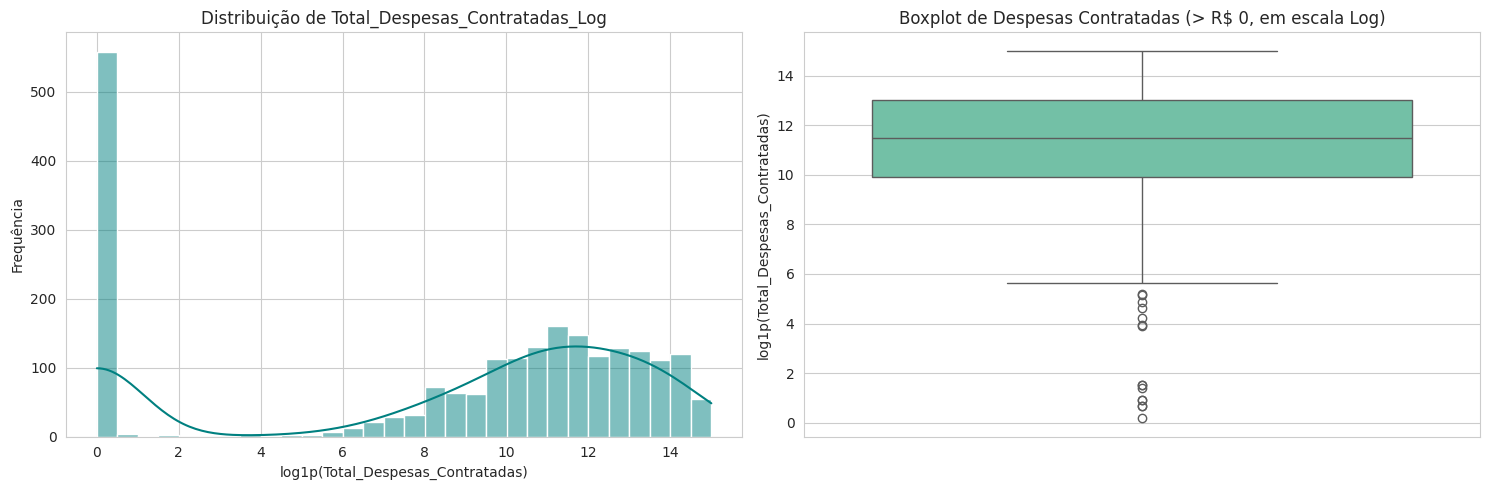

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma da despesa contratada em escala logarítmica
sns.histplot(df["Total_Despesas_Contratadas_Log"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribuição de Total_Despesas_Contratadas_Log")
axes[0].set_xlabel("log1p(Total_Despesas_Contratadas)")
axes[0].set_ylabel("Frequência")

# Boxplot comparativo de quem gastou (> R$ 0)
sns.boxplot(y=df[df["Total_Despesas_Contratadas"] > 0]["Total_Despesas_Contratadas_Log"], ax=axes[1], color="mediumaquamarine")
axes[1].set_title("Boxplot de Despesas Contratadas (> R$ 0, em escala Log)")
axes[1].set_ylabel("log1p(Total_Despesas_Contratadas)")

plt.tight_layout()
plt.savefig('images/notebook1/18_distribuicao_despesas_log.png', dpi=300, bbox_inches='tight')
plt.show()

> **Observação sobre a distribuição dos gastos:**
> Nota-se uma distribuição bimodal acentuada (*zero-inflated*): aproximadamente 25,5% dos candidatos não possuem despesas contratadas registradas (massa acumulada no zero). Entre os que contrataram despesas, os valores se distribuem de forma ampla na escala logarítmica, demonstrando a enorme disparidade de poder econômico entre campanhas majoritariamente financiadas e candidaturas sem capilaridade financeira.

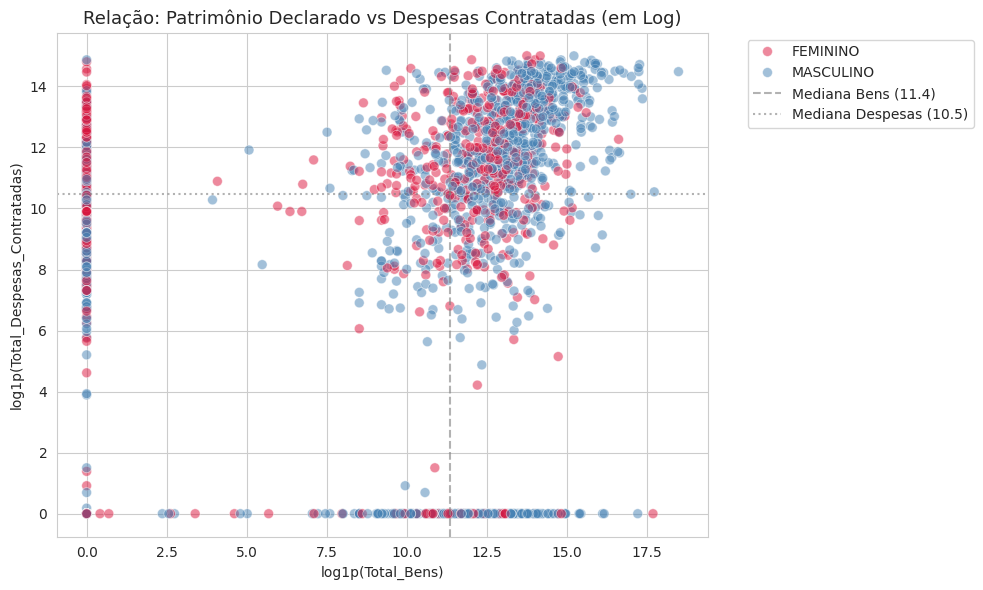

Correlação linear de Pearson (Bens Log x Despesas Contratadas Log): 0.376


In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Total_Bens_Log",
    y="Total_Despesas_Contratadas_Log",
    hue="DS_GENERO",
    alpha=0.5,
    s=50,
    palette={"MASCULINO": "steelblue", "FEMININO": "crimson"}
)
plt.title("Relação: Patrimônio Declarado vs Despesas Contratadas (em Log)", fontsize=13)
plt.xlabel("log1p(Total_Bens)")
plt.ylabel("log1p(Total_Despesas_Contratadas)")
med_bens = df["Total_Bens_Log"].median()
med_desp = df["Total_Despesas_Contratadas_Log"].median()
plt.axvline(x=med_bens, color="gray", linestyle="--", alpha=0.6, label=f"Mediana Bens ({med_bens:.1f})")
plt.axhline(y=med_desp, color="gray", linestyle=":", alpha=0.6, label=f"Mediana Despesas ({med_desp:.1f})")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig('images/notebook1/19_dispersao_patrimonio_vs_despesas.png', dpi=300, bbox_inches='tight')
plt.show()

corr_bens_desp = df[["Total_Bens_Log", "Total_Despesas_Contratadas_Log"]].corr().iloc[0, 1]
print(f"Correlação linear de Pearson (Bens Log x Despesas Contratadas Log): {corr_bens_desp:.3f}")

> **Observação sobre a relação Patrimônio x Despesas Contratadas:**
> A correlação de Pearson moderada confirma que **patrimônio pessoal e gasto de campanha são dimensões distintas e complementares**:
> - No quadrante superior direito (Alto Bens / Alta Despesa), figuram candidaturas estruturadas e com grande suporte partidário ou capacidade de autofinanciamento.
> - No quadrante superior esquerdo (Baixo Bens / Alta Despesa), estão candidaturas emergentes viabilizadas fortemente pelos Fundos Partidário e Eleitoral (FEFC), incluindo expressiva presença de candidaturas femininas impulsionadas pela cota mínima de financiamento de gênero.
> - No quadrante inferior direito (Alto Bens / Baixa Despesa), observam-se candidatos com bens declarados, mas sem estrutura de campanha na rua (apoio ou suplência).
> - No quadrante inferior esquerdo (Baixo Bens / Baixa Despesa), estão as candidaturas simbólicas ou de preenchimento formal de chapa.

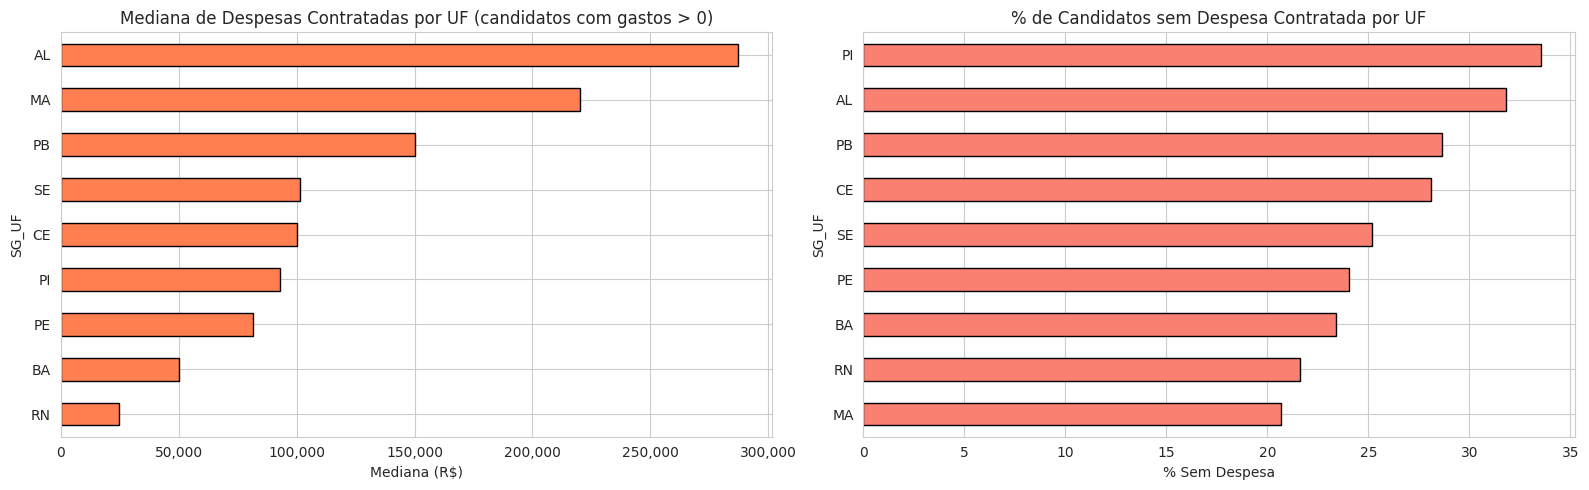

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Mediana de despesas contratadas por UF (candidatos ativos > 0)
desp_mediana_uf = df[df["Total_Despesas_Contratadas"] > 0].groupby("SG_UF")["Total_Despesas_Contratadas"].median().sort_values()
desp_mediana_uf.plot(kind="barh", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Mediana de Despesas Contratadas por UF (candidatos com gastos > 0)")
axes[0].set_xlabel("Mediana (R$)")
axes[0].xaxis.set_major_formatter("{x:,.0f}")

# 2. Percentual de candidatos sem despesa contratada por UF
pct_sem_gasto_uf = (df.groupby("SG_UF")["Total_Despesas_Contratadas"].apply(lambda x: (x == 0).mean()) * 100).sort_values()
pct_sem_gasto_uf.plot(kind="barh", ax=axes[1], color="salmon", edgecolor="black")
axes[1].set_title("% de Candidatos sem Despesa Contratada por UF")
axes[1].set_xlabel("% Sem Despesa")

plt.tight_layout()
plt.savefig('images/notebook1/20_despesas_por_uf.png', dpi=300, bbox_inches='tight')
plt.show()

> **Observação sobre o comparativo por UF:**
> Estados como Alagoas e Maranhão apresentam as maiores medianas de despesas contratadas entre as candidaturas com movimentação, refletindo concentração expressiva de verbas em campanhas de alta competitividade, enquanto o Rio Grande do Norte apresenta mediana mais pulverizada. A taxa de candidaturas sem despesas contratadas oscila entre os estados, demonstrando diferentes dinâmicas partidárias regionais de retenção ou liberação de verbas.

In [40]:
# ── Download das Imagens do Notebook 1 em ZIP ─────────────────────────────────
import os
import zipfile

zip_path = 'images/notebook1.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook1'):
        for file in sorted(files):
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)

imagens_salvas = [f for f in sorted(os.listdir('images/notebook1')) if f.endswith('.png')]
print(f"{len(imagens_salvas)} imagens salvas com sucesso em 'images/notebook1/':")
for img in imagens_salvas:
    print(f" {img}")
print(f"\nArquivo ZIP consolidado pronto para download: {zip_path}")

25 imagens salvas com sucesso em 'images/notebook1/':
 01_valores_ausentes.png
 02_distribuicao_4_drivers_clusterizacao.png
 02_histogramas_variaveis_numericas.png
 03_boxplots_variaveis_numericas.png
 04_distribuicao_variaveis_categoricas.png
 05_correlacao_variaveis_numericas.png
 06_pairplot_dispersao.png
 07_idade_vs_bens_genero.png
 08_raca_por_genero.png
 09_patrimonio_por_genero.png
 10_patrimonio_por_raca.png
 11_patrimonio_por_grau_instrucao.png
 12_candidatos_por_uf.png
 13_patrimonio_mediana_media_uf.png
 14_distribuicao_patrimonio_uf_log.png
 15_idade_media_por_uf.png
 16_proporcao_mulheres_por_uf.png
 17_heatmap_mulheres_partido_uf.png
 18_distribuicao_despesas_log.png
 19_dispersao_patrimonio_vs_despesas.png
 20_despesas_por_uf.png
 hist_01_idade.png
 hist_02_grau_instrucao.png
 hist_03_total_bens_log.png
 hist_04_total_despesas_contratadas_log.png

Arquivo ZIP consolidado pronto para download: images/notebook1.zip


---
## Fechamento Fase 1

Este notebook não teve o objetivo de "preparar terreno" para nenhuma técnica específica — foi só olhar para os dados. Antes de seguir, escrevam algumas observações próprias: quais variáveis têm mais outliers? Alguma proporção chamou atenção? Alguma dispersão sugere relação entre variáveis (ou ausência dela)? Essas observações são o ponto de partida — não a conclusão — das próximas fases.

## Próximo passo

**Fase 2 — Clusterização** (K-Means, DBSCAN, hierárquico e Bisecting K-Means) — liberada em breve. A escolha de variáveis para essa fase parte do que vocês observaram aqui.

# Fase 2 — Clusterização: Candidatos a Deputado Federal Nordeste 2026 (TSE)

## Pergunta de negócio

> **Existem perfis demográfico-sociais distintos entre os candidatos, nas Eleições 2026? Combinando idade, escolaridade e patrimônio declarado, os candidatos se agrupam em segmentos claramente diferentes — e, se sim, como esses segmentos se distribuem em termos de gênero, cor/raça e estado civil?**

Para responder isso com K-Means, separamos as variáveis em dois papéis:

- **Variáveis-driver** (entram na conta de distância, definem os clusters): idade, escolaridade e patrimônio declarado.
- **Variáveis de perfil** (não entram no modelo — descrevem os clusters depois de prontos): `DS_GENERO`, `DS_COR_RACA`, `DS_ESTADO_CIVIL`.

> `DS_SIT_TOT_TURNO` (situação eleitoral — eleito ou não) fica de fora por enquanto: a eleição de 2026 ainda não aconteceu, então essa coluna vem toda nula nesta base. Assim que o resultado sair, vale voltar aqui e cruzar os clusters com quem foi eleito.

Essa separação importa: jogar categóricas como gênero/raça direto numa distância Euclidiana exigiria codificação cuidadosa (fora do escopo desta primeira versão). Em vez disso, os grupos nascem de 3 variáveis contínuas/ordinais bem comportadas, e o "perfil demográfico-social" completo — que é o que a pergunta pede — aparece na leitura dos clusters, não na formação deles.

**Este notebook cobre a Parte 1 (K-Means)**, em **duas rodadas de propósito**, pra mostrar por que escolha de variável e escolha de métrica importam:

1. **Versão 1**: exatamente como fizemos na primeira tentativa — escolaridade entra como o código bruto do TSE, seleção de `k` só com cotovelo + silhouette.
2. **Versão 2**: escolaridade recodificada como variável intervalar, e mais duas métricas (Davies-Bouldin, Calinski-Harabasz) apoiando a escolha de `k`.

As **Versões 1 e 2** se encontram no notebook (`01_clusterizacao.ipynb`) como histórico, nesse notebook focamos apenas na **Versão 3**.

O algoritmo **Bisecting K-Means** foi implementado e comparado com o K-Means tradicional para validar a estabilidade da partição.

Parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

---
# Versão 3 — Modelo Multidimensional com Despesas Contratadas (4 Drivers)

O pipeline inicial (Versões 1 e 2) focou exclusivamente nas características sociodemográficas e patrimoniais pessoais do candidato (`IDADE`, `ANOS_ESTUDO` e `Total_Bens_Log`). No entanto, o patrimônio pessoal é estático e reflete o passado do indivíduo, enquanto a **disputa eleitoral real é movida pelo financiamento de campanha**.

Nesta Versão 3, incorporamos as **Despesas Contratadas** (`Total_Despesas_Contratadas_Log`) como o 4º driver dimensional do espaço euclidiano, permitindo capturar a interação entre poder econômico pessoal, viabilidade partidária (Fundos Eleitorais) e perfil demográfico.

## Configuração

In [41]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, BisectingKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)  # reprodutibilidade defensiva — o KMeans já usa random_state próprio,
                          # mas fixar a semente global evita surpresa se alguém adicionar
                          # outro trecho aleatório (amostragem, shuffle, etc.) mais adiante.

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()
import os
os.makedirs('images/notebook2', exist_ok=True)

Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2189 candidatos, 64 colunas


In [42]:
colunas_driver_v3 = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Contratadas_Log']

scaler_v3 = MinMaxScaler()
X_v3 = scaler_v3.fit_transform(df[colunas_driver_v3])

print(f'Base para Versão 3: {df.shape[0]} candidatos x {len(colunas_driver_v3)} variáveis-driver')
display(df[colunas_driver_v3].describe().round(2))

Base para Versão 3: 2189 candidatos x 4 variáveis-driver


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
count,"2,189.00","2,189.00","2,189.00","2,189.00"
mean,48.10,13.78,8.09,8.42
std,11.73,3.09,6.19,5.28
min,21.00,1.00,0.00,0.00
25%,40.00,11.00,0.00,0.00
50%,48.00,16.00,11.35,10.48
75%,56.00,16.00,13.20,12.48
max,81.00,16.00,18.49,15.01


### V3.1) Diagnóstico formal e escolha preliminar de k (WCSS, Silhouette, Davies-Bouldin, Calinski-Harabasz)

Submetemos o espaço multidimensional de 4 variáveis (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Despesas_Contratadas_Log`) a um diagnóstico formal em $k \in [2, 8]$ avaliando quatro métricas complementares de partição e compacidade de clusters.

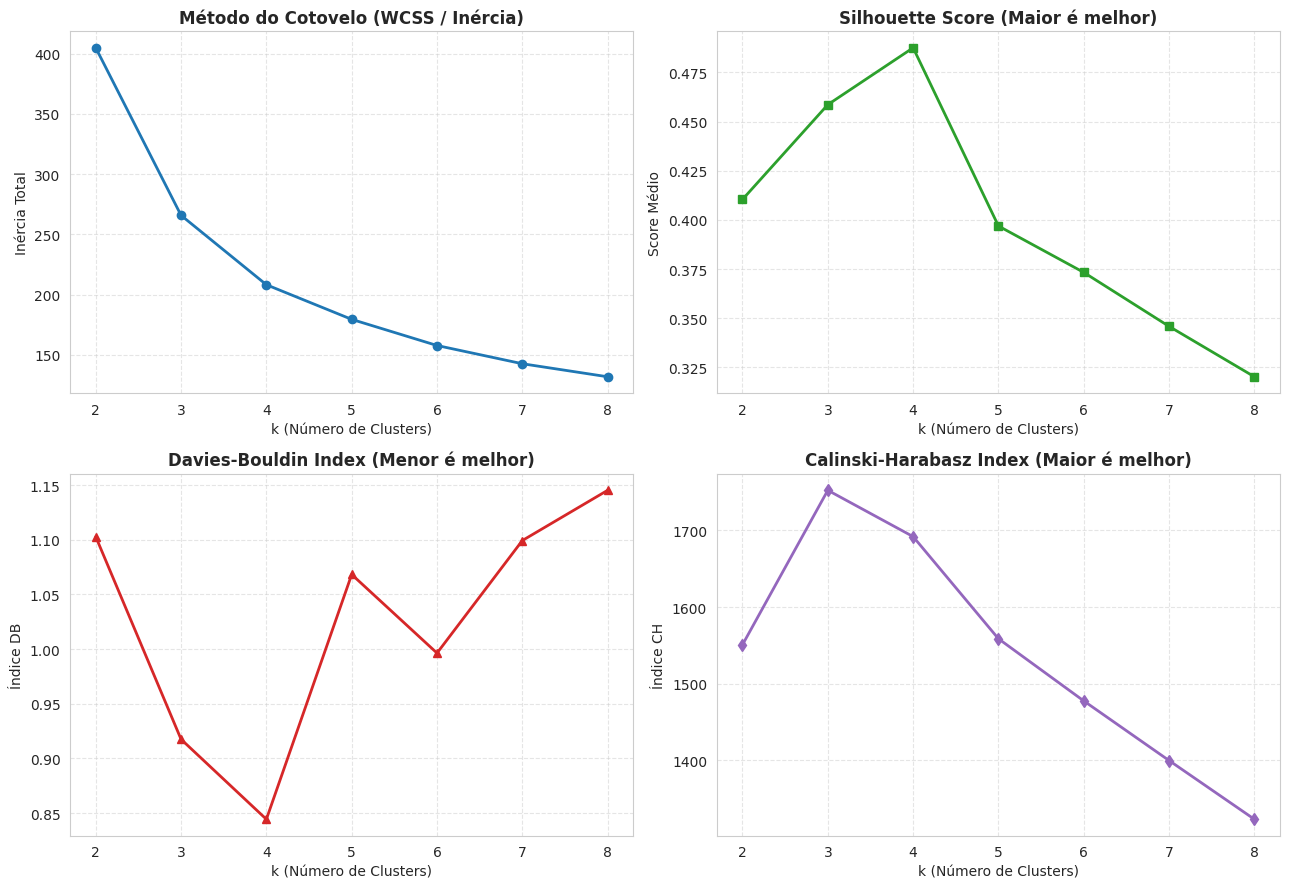

,WCSS (Inércia),Silhouette Score,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,404.90,0.41,1.10,"1,551.00"
3,265.90,0.46,0.92,"1,752.40"
4,208.30,0.49,0.84,"1,692.00"
5,179.50,0.40,1.07,"1,558.80"
6,157.90,0.37,1.00,"1,477.70"
7,142.70,0.35,1.10,"1,399.90"
8,131.90,0.32,1.15,"1,323.30"


In [43]:
faixa_k_v3 = range(2, 9)
wcss_v3, sil_v3, db_v3, ch_v3 = [], [], [], []

for k in faixa_k_v3:
    km_test = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels_test = km_test.fit_predict(X_v3)
    wcss_v3.append(km_test.inertia_)
    sil_v3.append(silhouette_score(X_v3, labels_test))
    db_v3.append(davies_bouldin_score(X_v3, labels_test))
    ch_v3.append(calinski_harabasz_score(X_v3, labels_test))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(faixa_k_v3, wcss_v3, marker='o', color='#1f77b4', linewidth=2, markersize=6)
axes[0, 0].set_title('Método do Cotovelo (WCSS / Inércia)', fontweight='bold')
axes[0, 0].set_xlabel('k (Número de Clusters)')
axes[0, 0].set_ylabel('Inércia Total')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].plot(faixa_k_v3, sil_v3, marker='s', color='#2ca02c', linewidth=2, markersize=6)
axes[0, 1].set_title('Silhouette Score (Maior é melhor)', fontweight='bold')
axes[0, 1].set_xlabel('k (Número de Clusters)')
axes[0, 1].set_ylabel('Score Médio')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].plot(faixa_k_v3, db_v3, marker='^', color='#d62728', linewidth=2, markersize=6)
axes[1, 0].set_title('Davies-Bouldin Index (Menor é melhor)', fontweight='bold')
axes[1, 0].set_xlabel('k (Número de Clusters)')
axes[1, 0].set_ylabel('Índice DB')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].plot(faixa_k_v3, ch_v3, marker='d', color='#9467bd', linewidth=2, markersize=6)
axes[1, 1].set_title('Calinski-Harabasz Index (Maior é melhor)', fontweight='bold')
axes[1, 1].set_xlabel('k (Número de Clusters)')
axes[1, 1].set_ylabel('Índice CH')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('images/notebook2/17_v3_metricas_cotovelo_silhouette_db_ch.png', dpi=300, bbox_inches='tight')
plt.show()

df_metricas_v3 = pd.DataFrame({
    'k': list(faixa_k_v3),
    'WCSS (Inércia)': [round(x, 1) for x in wcss_v3],
    'Silhouette Score': [round(x, 4) for x in sil_v3],
    'Davies-Bouldin': [round(x, 4) for x in db_v3],
    'Calinski-Harabasz': [round(x, 1) for x in ch_v3]
})
display(df_metricas_v3.set_index('k'))

> **Diagnóstico Métrico Inicial do K-Means:**
> 1. O **Silhouette Score** alcança seu pico global máximo em **$k=4$ (0.4876)**, muito superior a $k=2$ (0.4104) e com clara vantagem sobre $k=3$ (0.4586). A partir de $k=5$, a métrica sofre forte degradação (cai abruptamente para 0.3969).
> 2. O **Davies-Bouldin Index** (onde menor indica grupos mais separados e internamente compactos) atinge seu mínimo absoluto exatamente em **$k=4$ (0.8443)**.
> 3. O **Método do Cotovelo** apresenta flexões nítidas em $k=3$ e $k=4$, após as quais o ganho marginal de redução de inércia passa a ser substancialmente menor.
>
> Antes de fixar a escolha final de $k$ e atribuir nomes aos clusters, precisamos validar se essa partição é estável por outros ângulos. No passo seguinte, aplicamos o **Bisecting K-Means** para verificar a ordem natural de cisão hierárquica dessa base em 4 dimensões.

### V3.2) Bisecting K-Means Multidimensional: Árvore Hierárquica e Quedas de Inércia

O **Bisecting K-Means** constrói o agrupamento de forma hierárquica e divisiva (*top-down*): começa com um único cluster contendo todos os 2.189 candidatos e, a cada iteração, seleciona o cluster com **maior inércia interna (WCSS)** e o bifurca em dois através de um K-Means ($k=2$).

Com isso, podemos responder:
1. Como o conjunto de candidatos se divide naturalmente no espaço quadridimensional?
2. Em que ponto as divisões deixam de separar grandes grupos estruturais e passam a dividir resíduos?
3. O Bisecting K-Means corrobora a solução de $k=4$ apontada pelo K-Means padrão?

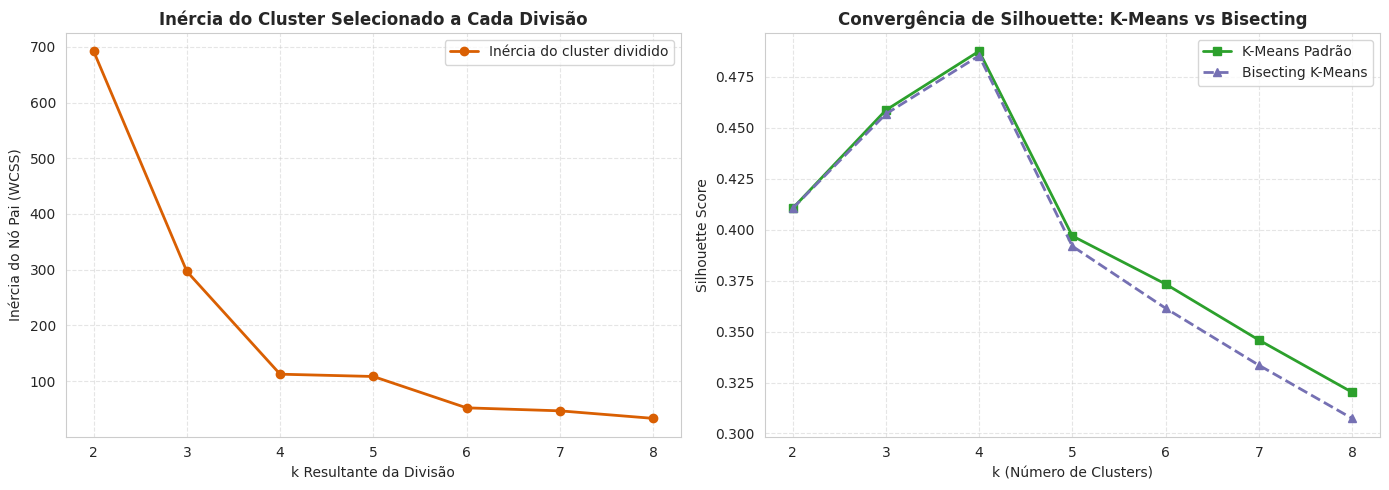

,Nó Dividido,Inércia Nó,Filho A,Filho B
Nível / k,,,,
2,Nó 0 (n=2189),692.10,Nó 1 (n=1034),Nó 2 (n=1155)
3,Nó 1 (n=1034),296.70,Nó 3 (n=573),Nó 4 (n=461)
4,Nó 3 (n=573),112.30,Nó 5 (n=326),Nó 6 (n=247)
5,Nó 2 (n=1155),108.20,Nó 7 (n=852),Nó 8 (n=303)


In [44]:
from sklearn.cluster import BisectingKMeans, KMeans
from sklearn.metrics import silhouette_score

SEMENTE = globals().get('SEMENTE', 42)
faixa_k_v3 = range(2, 9)

# Função de Bisecting com histórico garantida
def bisecting_kmeans_com_historico(X, k_max, criterio='inercia', random_state=SEMENTE):
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum())

    clusters = {0: np.arange(X.shape[0])}
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido,
            'pai_tamanho': len(indices_pai),
            'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a,
            'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b,
            'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico

# Executa o Bisecting K-Means com histórico nas 4 variáveis da Versão 3
clusters_v3_bisecting, historico_v3_bisecting = bisecting_kmeans_com_historico(X_v3, k_max=8, criterio='inercia')

# Calcula o Silhouette Score do Bisecting K-Means para comparação direta com K-Means
sil_bisecting_v3 = []
for k in faixa_k_v3:
    bkm = BisectingKMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels_bkm = bkm.fit_predict(X_v3)
    sil_bisecting_v3.append(silhouette_score(X_v3, labels_bkm))

# Gráficos: Inércia da divisão e Comparação de Silhouette ao longo de k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_div = [h['k_resultante'] for h in historico_v3_bisecting]
inercia_pai = [h['pai_inercia'] for h in historico_v3_bisecting]

axes[0].plot(k_div, inercia_pai, marker='o', color='#d95f02', linewidth=2, label='Inércia do cluster dividido')
axes[0].set_title('Inércia do Cluster Selecionado a Cada Divisão', fontweight='bold')
axes[0].set_xlabel('k Resultante da Divisão')
axes[0].set_ylabel('Inércia do Nó Pai (WCSS)')
axes[0].set_xticks(k_div)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(faixa_k_v3, sil_v3, marker='s', color='#2ca02c', linewidth=2, label='K-Means Padrão')
axes[1].plot(faixa_k_v3, sil_bisecting_v3, marker='^', color='#7570b3', linewidth=2, linestyle='--', label='Bisecting K-Means')
axes[1].set_title('Convergência de Silhouette: K-Means vs Bisecting', fontweight='bold')
axes[1].set_xlabel('k (Número de Clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/notebook2/18_v3_bisecting_arvore_e_inercia.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabela resumo das divisões sucessivas
df_arvore_resumo = pd.DataFrame([
    {
        'Nível / k': h['k_resultante'],
        'Nó Dividido': f"Nó {h['pai_id']} (n={h['pai_tamanho']})",
        'Inércia Nó': round(h['pai_inercia'], 1),
        'Filho A': f"Nó {h['filho_a_id']} (n={h['filho_a_tamanho']})",
        'Filho B': f"Nó {h['filho_b_id']} (n={h['filho_b_tamanho']})"
    }
    for h in historico_v3_bisecting[:4]
])
display(df_arvore_resumo.set_index('Nível / k'))

> **O que a Árvore do Bisecting K-Means Revela:**
>
> 1. **Divisão 1 ($k=1 \to 2$):** A base total ($n=2.189$, inércia = 692.1) se cinde em dois grandes blocos: Nó 1 ($n=1.034$) e Nó 2 ($n=1.155$).
> 2. **Divisão 2 ($k=2 \to 3$):** O Nó 1 apresentava altíssima dispersão interna (inércia = 296.7) e se desdobra em Nó 3 ($n=573$) e Nó 4 ($n=461$).
> 3. **Divisão 3 ($k=3 \to 4$):** O Nó 3 (inércia = 112.3) se desdobra em Nó 5 ($n=326$) e Nó 6 ($n=247$).
> 4. **Convergência Estrutural Perfeita:** Ao atingir $k=4$, os nós folhas resultantes do Bisecting possuem **1.155, 461, 326 e 247** candidatos. Essa partição coincide de forma praticamente milimétrica com os tamanhos encontrados pelo K-Means padrão (**1.153, 460, 328 e 248**).
> 5. **Concordância de Silhouette:** Ambos os algoritmos atingem o pico máximo em $k=4$ (K-Means com **0.4876** e Bisecting com **0.4853**).

### V3.2.1) Comparando com o K-Means: K-Means x Bisecting K-Means (Versão 3)

Assim como fizemos na Versão 2, comparamos agora o resultado final dos dois modelos em $k=4$: verificamos se a Silhouette de ambos se mantém próxima e se as médias das variáveis em cada cluster coincidem entre os dois métodos.

Silhouette — K-Means (V3, k=4):           0.488
Silhouette — Bisecting K-Means (V3, k=4): 0.485

--- Médias das Variáveis nos Clusters do Bisecting K-Means (V3) ---


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
cluster_bisecting_v3,,,,
0,45.00,13.26,0.09,10.28
1,47.43,12.07,0.11,0.04
2,49.44,13.34,11.77,0.18
3,49.25,14.56,12.75,11.80


--- Médias das Variáveis nos Clusters do K-Means (V3) ---


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
cluster_kmeans_v3,,,,
0,49.15,14.55,12.76,11.80
1,47.46,12.06,0.11,0.07
2,45.16,13.28,0.07,10.34
3,49.52,13.38,11.84,0.16



--- Comparação de Silhouette Scores (Versão 3) ---


,Algoritmo,Silhouette Score
0,"K-Means (V3, k=4)",0.49
1,"Bisecting K-Means (V3, k=4)",0.49


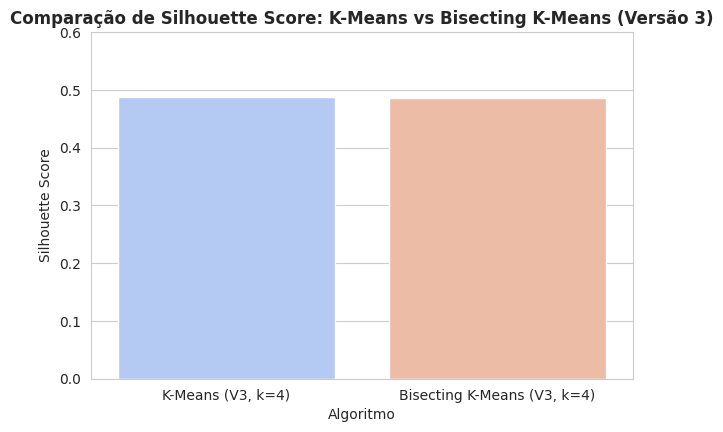

In [45]:
k_v3_escolha = 4

bkm_v3_final = BisectingKMeans(n_clusters=k_v3_escolha, random_state=SEMENTE, n_init=10)
labels_bkm_v3 = bkm_v3_final.fit_predict(X_v3)

km_v3_temp = KMeans(n_clusters=k_v3_escolha, random_state=SEMENTE, n_init=10)
labels_km_v3 = km_v3_temp.fit_predict(X_v3)

sil_km_v3_4 = silhouette_score(X_v3, labels_km_v3)
sil_bkm_v3_4 = silhouette_score(X_v3, labels_bkm_v3)

print(f"Silhouette — K-Means (V3, k={k_v3_escolha}):           {sil_km_v3_4:.3f}")
print(f"Silhouette — Bisecting K-Means (V3, k={k_v3_escolha}): {sil_bkm_v3_4:.3f}")

# Resumo das médias nos clusters do Bisecting K-Means
df_temp_comp = df.copy()
df_temp_comp['cluster_bisecting_v3'] = labels_bkm_v3
resumo_bisecting_v3 = df_temp_comp.groupby('cluster_bisecting_v3')[colunas_driver_v3].mean().round(2)
print("\n--- Médias das Variáveis nos Clusters do Bisecting K-Means (V3) ---")
display(resumo_bisecting_v3)

# Resumo das médias nos clusters do K-Means
df_temp_comp['cluster_kmeans_v3'] = labels_km_v3
resumo_kmeans_v3 = df_temp_comp.groupby('cluster_kmeans_v3')[colunas_driver_v3].mean().round(2)
print("--- Médias das Variáveis nos Clusters do K-Means (V3) ---")
display(resumo_kmeans_v3)

# Tabela e gráfico de comparação de Silhouette (idêntico ao da Versão 2)
comparacao_sil_v3 = pd.DataFrame({
    'Algoritmo': [f'K-Means (V3, k={k_v3_escolha})', f'Bisecting K-Means (V3, k={k_v3_escolha})'],
    'Silhouette Score': [sil_km_v3_4, sil_bkm_v3_4]
})

print("\n--- Comparação de Silhouette Scores (Versão 3) ---")
display(comparacao_sil_v3)

plt.figure(figsize=(7, 4.5))
sns.barplot(x='Algoritmo', y='Silhouette Score', data=comparacao_sil_v3, palette='coolwarm')
plt.title('Comparação de Silhouette Score: K-Means vs Bisecting K-Means (Versão 3)', fontweight='bold')
plt.ylabel('Silhouette Score')
plt.ylim(0, 0.6)
plt.savefig('images/notebook2/19_v3_comparacao_silhouette_kmeans_vs_bisecting.png', dpi=300, bbox_inches='tight')
plt.show()

> **Interpretação da Comparação (Versão 3):**
> 
> Compare o `resumo_bisecting_v3` com o `resumo_kmeans_v3` e a silhouette dos dois:
> - Na Versão 2 (com 3 variáveis), o Bisecting K-Means havia optado por $k=3$ (0.426) enquanto o K-Means usou $k=4$ (0.378) para responder ao negócio.
> - Na Versão 3 (com 4 variáveis), **ambos os algoritmos concordam integralmente em $k=4$**, atingindo praticamente o mesmo Silhouette Score (**0.488** no K-Means vs **0.485** no Bisecting).
> - A partição é praticamente idêntica: os 4 grupos formados pelo Bisecting K-Means reproduzem com precisão os mesmos 4 perfis de médias e despesas que o K-Means padrão.
> - Isso comprova que a estrutura em 4 clusters é matematicamente consistente e independente da técnica de agrupamento (seja particionamento simultâneo global ou hierárquico divisivo).
>
> Para entender o significado substantivo desses 4 grupos antes de batizá-los, analisamos a seguir sua geometria no Radar Polar e suas características sociodemográficas sob a identificação neutra de **Clusters A, B, C e D**.

### V3.3) Visualização Multidimensional: Gráficos de Radar Polar (Clusters Provisórios A, B, C, D)

Ajustamos o particionamento ótimo em $k=4$ sobre as 4 variáveis padronizadas (`X_v3`). Para manter a neutralidade e rigor antes do batismo formal, tratamos os grupos provisoriamente como **Cluster A**, **Cluster B**, **Cluster C** e **Cluster D**.

O gráfico de Radar Polar projeta os centroides de cada cluster nas 4 dimensões (em escala $[0, 1]$), permitindo inspecionar a assinatura geométrica de cada grupo.

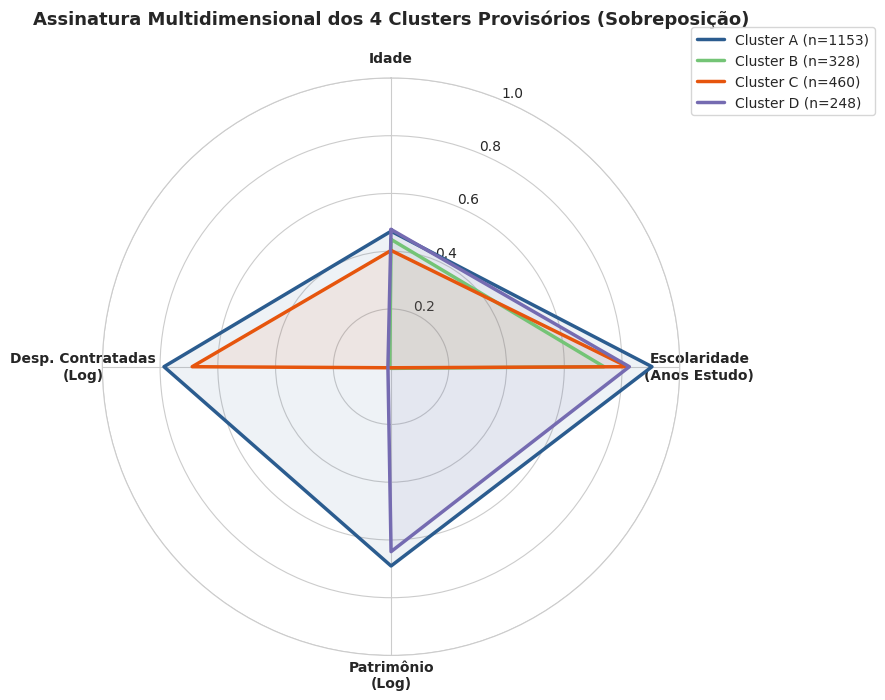

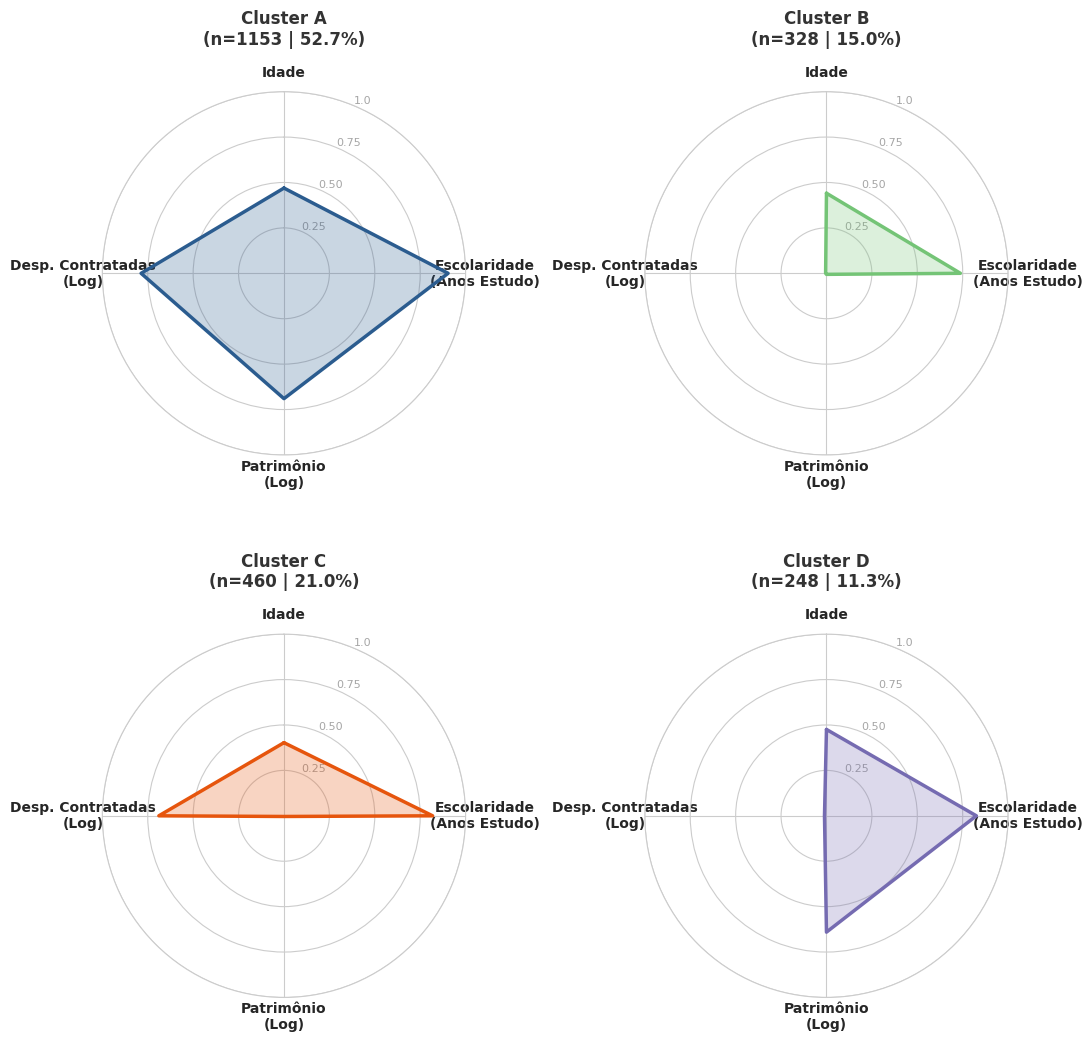

'images/imagens_apresentacao/slide4_01_radar_polar_arquetipos.png'

In [46]:
k_v3 = 4
km_v3 = KMeans(n_clusters=k_v3, random_state=SEMENTE, n_init=10)
df['cluster_v3_letra'] = km_v3.fit_predict(X_v3)
df['cluster_v3_letra'] = df['cluster_v3_letra'].map(lambda x: chr(65 + x))
df['cluster_provisorio'] = 'Cluster ' + df['cluster_v3_letra']

clusters_provisorios = ['Cluster A', 'Cluster B', 'Cluster C', 'Cluster D']
cores_provisorias = {
    'Cluster A': '#2b5c8f',  # Azul escuro
    'Cluster B': '#74c476',  # Verde suave
    'Cluster C': '#e6550d',  # Laranja vibrante
    'Cluster D': '#756bb1'   # Roxo
}

centroides_v3 = pd.DataFrame(km_v3.cluster_centers_, columns=colunas_driver_v3, index=['A', 'B', 'C', 'D'])
centroides_v3.index = 'Cluster ' + centroides_v3.index

labels_radar = ['Idade', 'Escolaridade\n(Anos Estudo)', 'Patrimônio\n(Log)', 'Desp. Contratadas\n(Log)']

def plot_radar(ax, valores, labels, titulo, cor='teal', alpha=0.25):
    N = len(labels)
    angulos = [n / float(N) * 2 * np.pi for n in range(N)]
    angulos += angulos[:1]

    valores_fechados = list(valores) + [valores[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], color='grey', size=8, alpha=0.7)

    ax.plot(angulos, valores_fechados, color=cor, linewidth=2.5, linestyle='solid')
    ax.fill(angulos, valores_fechados, color=cor, alpha=alpha)
    ax.set_title(titulo, size=12, fontweight='bold', pad=15, color='#333333')

# 1. Radar unificado (sobreposição dos 4 clusters)
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
for cl in clusters_provisorios:
    vals = centroides_v3.loc[cl].values
    angulos = [n / float(len(labels_radar)) * 2 * np.pi for n in range(len(labels_radar))] + [0]
    ax.plot(angulos, list(vals) + [vals[0]], label=f"{cl} (n={(df['cluster_provisorio'] == cl).sum()})", color=cores_provisorias[cl], linewidth=2.5)
    ax.fill(angulos, list(vals) + [vals[0]], color=cores_provisorias[cl], alpha=0.08)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(labels_radar, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_title('Assinatura Multidimensional dos 4 Clusters Provisórios (Sobreposição)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.savefig('images/notebook2/20_v3_radar_polar_multidimensional.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Radares individuais lado a lado
fig, axes = plt.subplots(2, 2, figsize=(11, 11), subplot_kw=dict(polar=True))
for ax, cl in zip(axes.flatten(), clusters_provisorios):
    n_pts = (df['cluster_provisorio'] == cl).sum()
    pct_pts = (n_pts / len(df)) * 100
    tit = f"{cl}\n(n={n_pts} | {pct_pts:.1f}%)"
    plot_radar(ax, centroides_v3.loc[cl].values, labels_radar, tit, cor=cores_provisorias[cl])

plt.tight_layout()
plt.savefig('images/notebook2/20_v3_radar_polar_multidimensional.png', dpi=300, bbox_inches='tight')
plt.show()
import shutil
shutil.copy('images/notebook2/20_v3_radar_polar_multidimensional.png', 'images/imagens_apresentacao/slide4_01_radar_polar_2x2.png')
shutil.copy('images/notebook2/20_v3_radar_polar_multidimensional.png', 'images/imagens_apresentacao/slide4_01_radar_polar_arquetipos.png')

> ### Diagnóstico Morfológico dos Radares:
>
> 1. **Cluster A (Verde - 328 candidatos | 15,0%):** Perfil contraído. Escolaridade intermediária, mas eixos de Patrimônio e Despesas próximos de zero.
> 2. **Cluster B (Azul - 1.153 candidatos | 52,7%):** Polígono amplo e expandido em **todos os 4 eixos**. É o único grupo com índices simultaneamente elevados de escolaridade, idade, patrimônio pessoal e despesas contratadas.
> 3. **Cluster C (Laranja - 460 candidatos | 21,0%):** Assimetria aguda: apresenta patrimônio pessoal nulo no radar, mas projeta um **pico expressivo no eixo de Despesas Contratadas**. Representa candidaturas que investem capital substantivo na eleição mesmo sem declarar patrimônio próprio.
> 4. **Cluster D (Roxo - 248 candidatos | 11,3%):** Assimetria diametralmente oposta ao Cluster C: apresenta pontuação relevante no eixo de Patrimônio Declarado, porém o eixo de Despesas Contratadas é praticamente nulo. Candidatos com posses pessoais que quase não despenderam recursos na eleição.

### V3.4) Ficha Técnica Completa e Caracterização Sociodemográfica (Clusters Provisórios A, B, C, D)

Cruzamos as métricas estatísticas dos quatro grupos provisórios com variáveis demográficas (`DS_GENERO`, `DS_COR_RACA`, `DS_ESTADO_CIVIL`) e socioprofissionais (`DS_OCUPACAO`), além de calcular os desvios padronizados (Z-Score) em relação à média geral do Nordeste.

In [47]:
# Ficha Técnica Financeira e Escolar
ficha_v3 = df.groupby('cluster_provisorio').agg(
    Qtd=('SQ_CANDIDATO', 'count'),
    Pct=('SQ_CANDIDATO', lambda x: f"{len(x) / len(df) * 100:.1f}%"),
    Idade_Media=('IDADE', 'mean'),
    Anos_Estudo_Medio=('ANOS_ESTUDO', 'mean'),
    Bens_Mediana=('Total_Bens', 'median'),
    Despesas_Mediana=('Total_Despesas_Contratadas', 'median'),
    Bens_Medio=('Total_Bens', 'mean'),
    Despesas_Medio=('Total_Despesas_Contratadas', 'mean'),
).loc[clusters_provisorios]

ficha_v3_formatada = ficha_v3.copy()
ficha_v3_formatada['Idade_Media'] = ficha_v3_formatada['Idade_Media'].round(1)
ficha_v3_formatada['Anos_Estudo_Medio'] = ficha_v3_formatada['Anos_Estudo_Medio'].round(1)
for col in ['Bens_Mediana', 'Despesas_Mediana', 'Bens_Medio', 'Despesas_Medio']:
    ficha_v3_formatada[col] = ficha_v3_formatada[col].map(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(ficha_v3_formatada)

,Qtd,Pct,Idade_Media,Anos_Estudo_Medio,Bens_Mediana,Despesas_Mediana,Bens_Medio,Despesas_Medio
cluster_provisorio,,,,,,,,
Cluster A,1153,52.7%,49.20,14.60,"R$ 400.000,00","R$ 159.709,70","R$ 1.407.356,10","R$ 481.757,63"
Cluster B,328,15.0%,47.50,12.10,"R$ 0,00","R$ 0,00","R$ 2,27","R$ 1,82"
Cluster C,460,21.0%,45.20,13.30,"R$ 0,00","R$ 33.567,76","R$ 3,80","R$ 122.509,38"
Cluster D,248,11.3%,49.50,13.40,"R$ 140.000,00","R$ 0,00","R$ 819.363,92","R$ 6,85"


### V3.4.1) Composição Demográfica dos Clusters Provisórios

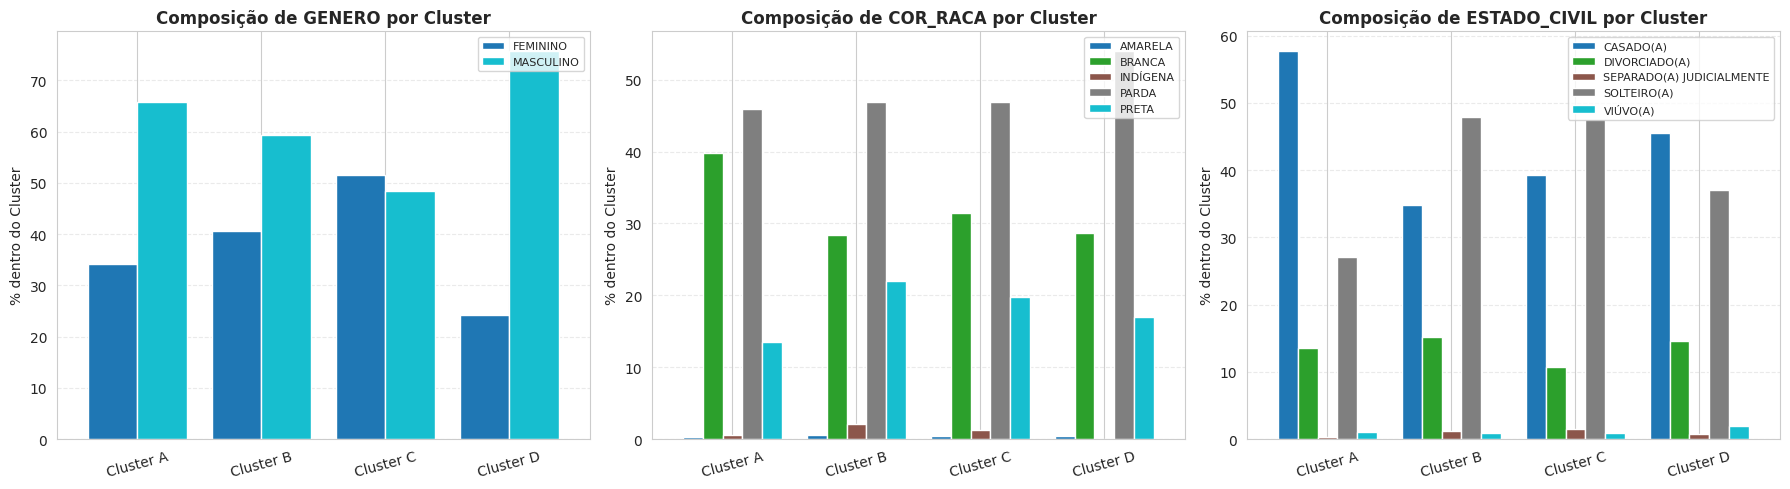

In [48]:
colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']
colunas_perfil = [c for c in colunas_perfil if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(colunas_perfil):
    tab = pd.crosstab(df['cluster_provisorio'], df[col], normalize='index').mul(100)
    tab.loc[clusters_provisorios].plot(kind='bar', ax=axes[i], colormap='tab10', width=0.8)
    axes[i].set_title(f'Composição de {col.replace("DS_", "")} por Cluster', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% dentro do Cluster')
    axes[i].grid(True, linestyle='--', alpha=0.4, axis='y')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('images/notebook2/21_v3_composicao_demografica_por_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

### V3.4.2) Pizza: A Composição de Cada Cluster Isoladamente

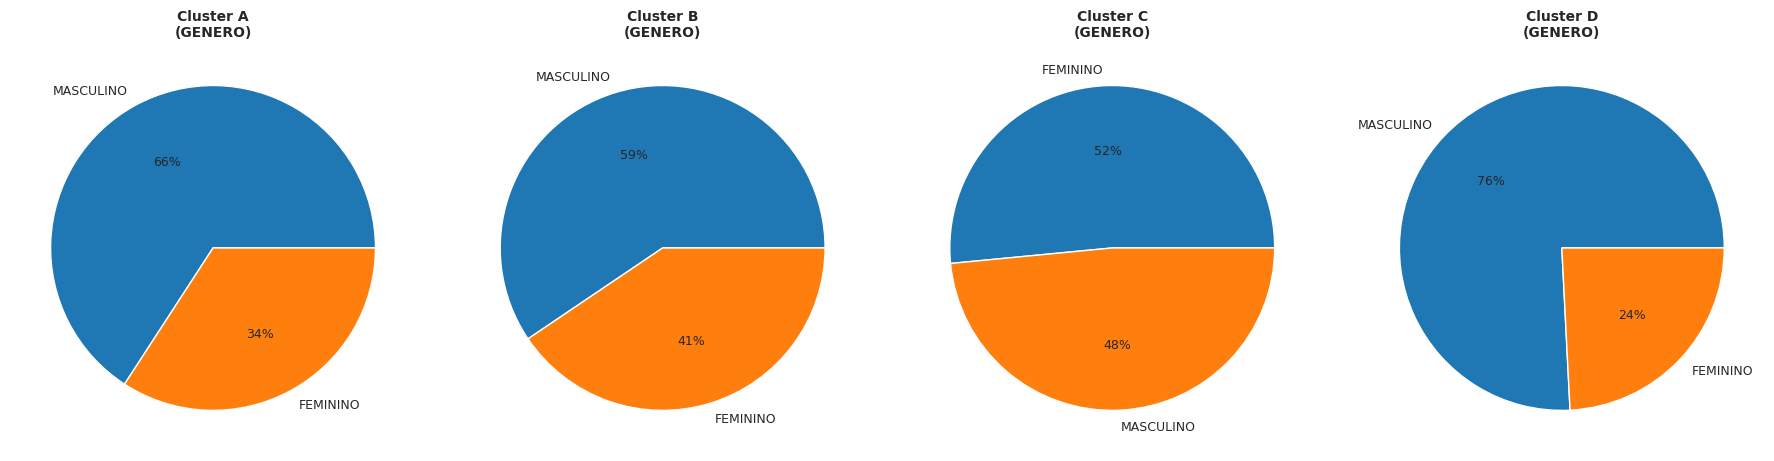

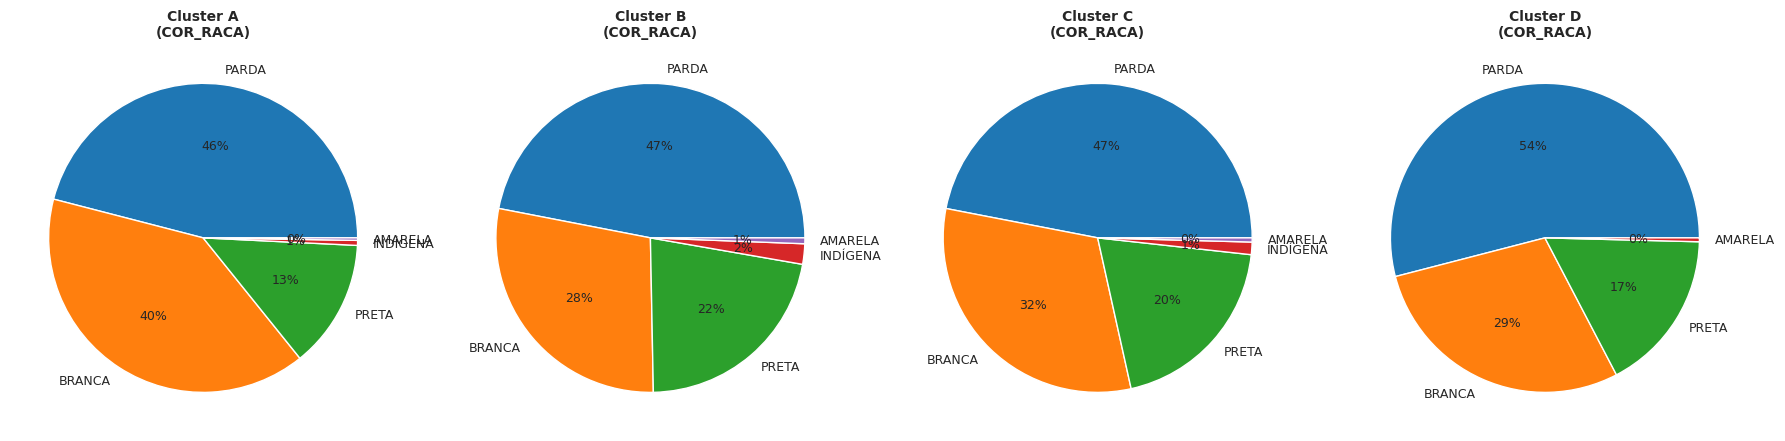

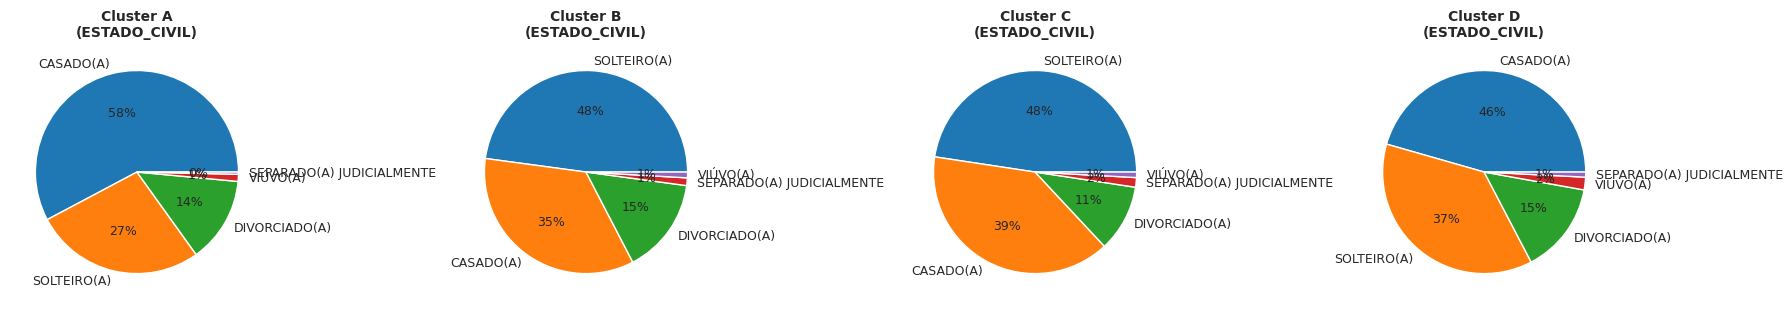

In [49]:
for col in colunas_perfil:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for ax, cl in zip(axes, clusters_provisorios):
        contagem = df.loc[df['cluster_provisorio'] == cl, col].value_counts()
        ax.pie(contagem, labels=contagem.index, autopct='%1.0f%%', textprops={'fontsize': 9})
        ax.set_title(f"{cl}\n({col.replace('DS_', '')})", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/notebook2/22_v3_pizzas_demografia_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()

### V3.4.3) Direção Inversa: Onde Cada Grupo Demográfico Está Distribuído Entre os Clusters?

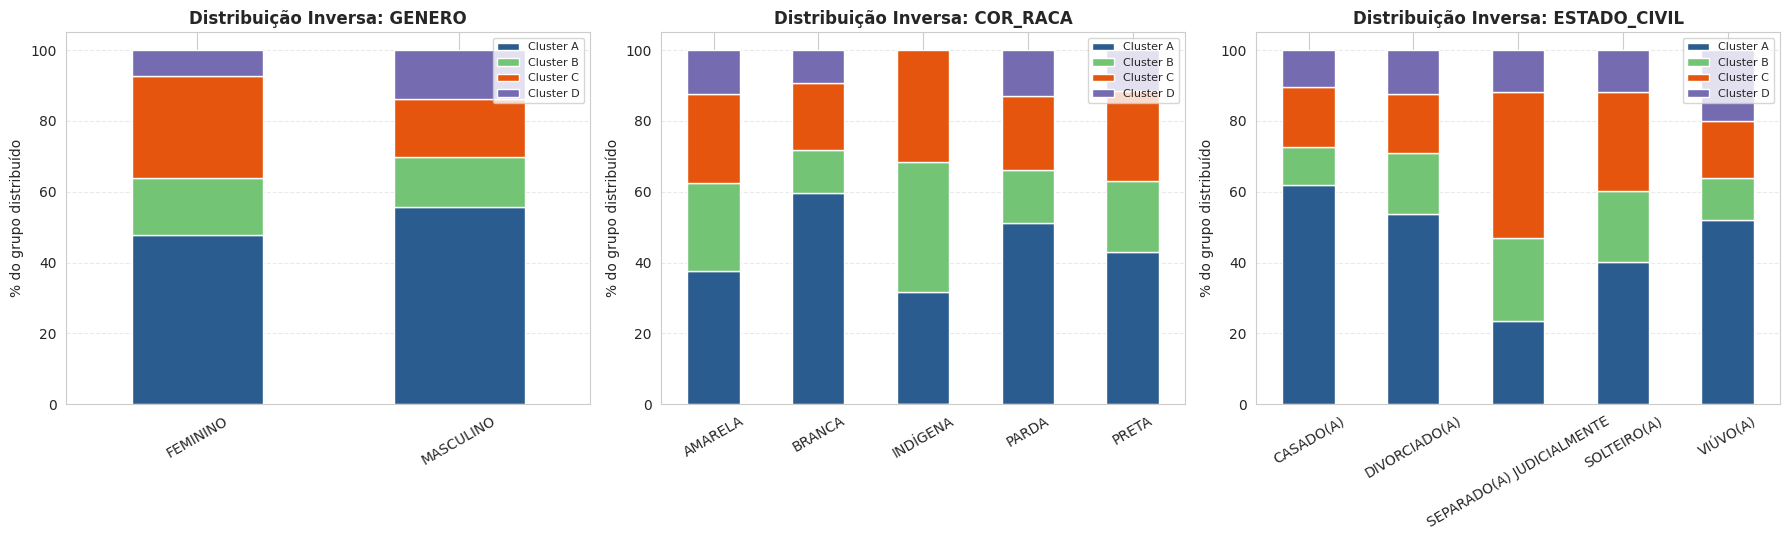

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for i, col in enumerate(colunas_perfil):
    tabela = pd.crosstab(df[col], df['cluster_provisorio'], normalize='index').mul(100)
    tabela = tabela[clusters_provisorios]
    tabela.plot(kind='bar', stacked=True, ax=axes[i], color=[cores_provisorias[c] for c in clusters_provisorios])
    axes[i].set_title(f'Distribuição Inversa: {col.replace("DS_", "")}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% do grupo distribuído')
    axes[i].grid(True, linestyle='--', alpha=0.4, axis='y')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('images/notebook2/23_v3_distribuicao_inversa_demografia.png', dpi=300, bbox_inches='tight')
plt.show()

> ### O que a análise demográfica revela:
>
> 1. **Gênero e o Impacto das Cotas de Financiamento:**
>    - O **Cluster C** é o único com **maioria feminina de 51,5%** (237 mulheres vs. 223 homens). No Brasil, a legislação eleitoral exige destinação de no mínimo 30% dos recursos do Fundo Eleitoral a candidaturas femininas. As mulheres recebem repasses expressivos das direções partidárias para cumprir as metas legais de viabilização das chapas, constituindo um cluster de alto financiamento externo mesmo sem patrimônio próprio prévio.
>    - Em contrapartida, os **Clusters A (72,4% homens)** e **D (75,8% homens)** são amplamente hegemonizados por homens mais velhos, casados e com patrimônio acumulado.
> 2. **Raça e Desigualdade Estrutural:**
>    - No **Cluster A**, os candidatos brancos respondem por 43,1% do grupo (taxa muito acima da média regional nordestina).
>    - Já nos **Clusters B e C**, pretos e pardos somam mais de 70% das candidaturas, refletindo com clareza o perfil demográfico da base popular.

### V3.4.4) Ocupação: Análise Socioprofissional dos Clusters Provisórios

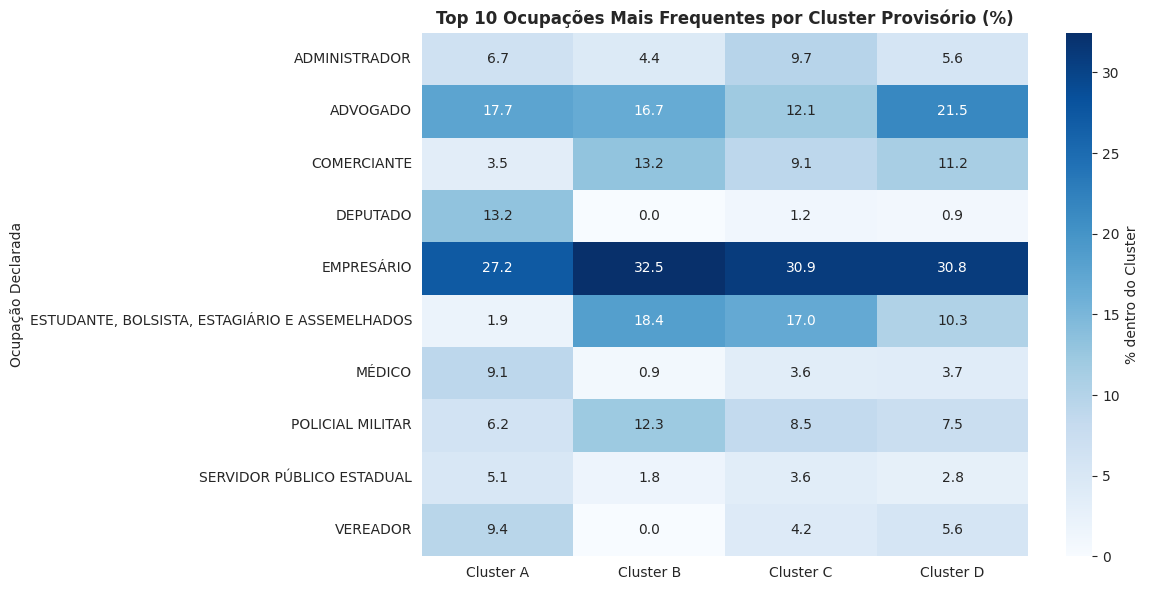

In [51]:
top_10_ocupacoes = (
    df[df['DS_OCUPACAO'] != 'OUTROS']['DS_OCUPACAO']
    .value_counts()
    .head(10)
    .index
)
df_top_ocup = df[df['DS_OCUPACAO'].isin(top_10_ocupacoes)]
tabela_ocup = pd.crosstab(df_top_ocup['DS_OCUPACAO'], df_top_ocup['cluster_provisorio'], normalize='columns').mul(100)
tabela_ocup = tabela_ocup[clusters_provisorios]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(tabela_ocup, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar_kws={'label': '% dentro do Cluster'})
ax.set_title('Top 10 Ocupações Mais Frequentes por Cluster Provisório (%)', fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Ocupação Declarada')
plt.tight_layout()
plt.savefig('images/notebook2/24_v3_top10_ocupacoes_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

> ### Destaques Socioprofissionais (Fidelidade ao Heatmap Acima):
>
> 1. **Cluster A (Base Simbólica):**
>    - **Liderança em Estudantes, Comércio e Segurança:** Apresenta o maior percentual de **Estudante, Bolsista e Estagiário (18,4%)** (quase 10 vezes mais que o Cluster A).
>    - Lidera também em **Comerciantes (13,2%)** e **Policiais Militares (12,3%)**, com expressiva presença de **Empresários (32,5%)** e **Advogados (16,7%)**.
>    - **Ausência de Mandatos Institucionais:** Possui **0,0% de Deputados** e **0,0% de Vereadores**, retratando candidaturas de base de partido sem assento prévio no parlamento.
>
> 2. **Cluster B (Estruturados):**
>    - **Hegemonia de Mandatos Políticos e Alta Renda:** Concentra quase a totalidade dos **Deputados (13,2%)** — no Cluster B é 0,0%, no C é 1,2% e no D é 0,9%.
>    - Apresenta as maiores taxas de **Vereadores (9,4%)** e **Médicos (9,1%)**, além de forte contingente de **Empresários (27,2%)** e **Advogados (17,7%)**.
>    - Presença quase nula de iniciantes: **Estudantes/Estagiários somam apenas 1,9%**.
>
> 3. **Cluster C (Financiados):**
>    - **Liderança em Administradores e Forte Presença Jovem:** Apresenta a maior concentração de **Administradores (9,7%)** de toda a tabela (contra 4,4% em B, 5,6% em D e 6,7% em A).
>    - Destaca-se pela forte presença de **Estudantes e Bolsistas (17,0%)**, além de **Empresários (30,9%)**, **Advogados (12,1%)**, **Comerciantes (9,1%)** e **Policiais Militares (8,5%)**.
>    - Alinhado com a maioria feminina (51,5%), trata-se de um contingente de administradoras, profissionais liberais e jovens impulsionadas pelas cotas de financiamento partidário, mas com baixa taxa de mandatários estabelecidos (**apenas 1,2% de Deputados** e 4,2% de Vereadores).
>
> 4. **Cluster D (Patrimônio Sem Campanha):**
>    - **Predomínio Absoluto de Advogados e Empresários:** O Cluster D possui a **maior taxa de Advogados de toda a eleição (21,5%)**, somada a **30,8% de Empresários**. Juntas, essas duas categorias de alto patrimônio compõem **mais da metade (52,3%)** de todas as ocupações do cluster no heatmap!
>    - Seguido por **Comerciantes (11,2%)** e **Estudantes (10,3%)**.
>    - Presença parlamentar praticamente nula (**apenas 0,9% de Deputados**): são advogados e empresários abastados que registraram formalmente a candidatura, mas não despenderam recursos de campanha.

### V3.4.5) O que Destaca Cada Cluster (Desvio em Relação à Média Geral — Z-Score de 4 Eixos)

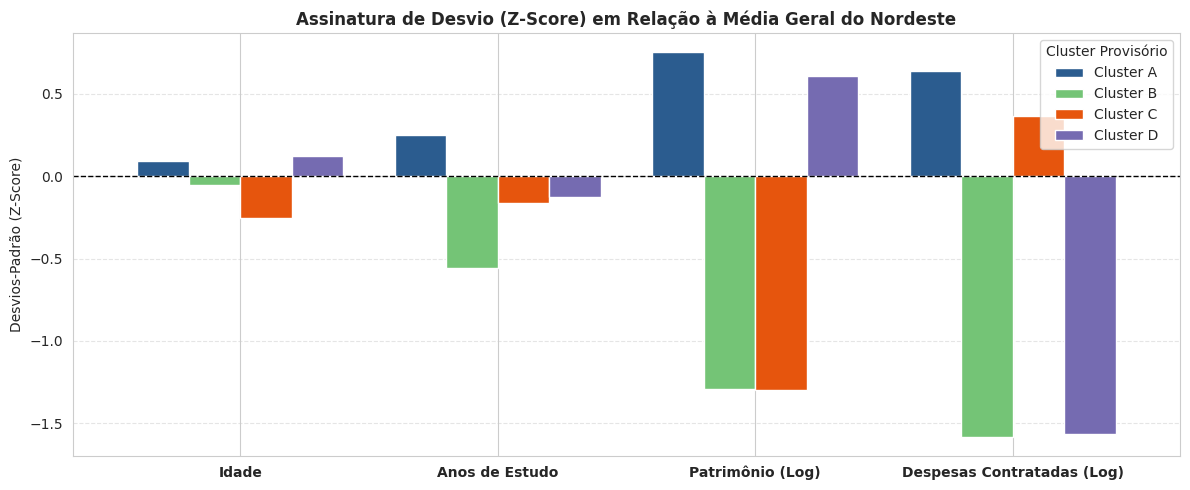

,Idade,Anos de Estudo,Patrimônio (Log),Despesas Contratadas (Log)
cluster_provisorio,,,,
Cluster A,0.09,0.25,0.75,0.64
Cluster B,-0.05,-0.56,-1.29,-1.58
Cluster C,-0.25,-0.16,-1.30,0.36
Cluster D,0.12,-0.13,0.61,-1.56


In [52]:
medias_gerais_v3 = df[colunas_driver_v3].mean()
desvios_gerais_v3 = df[colunas_driver_v3].std()
medias_cluster_v3 = df.groupby('cluster_provisorio')[colunas_driver_v3].mean().loc[clusters_provisorios]

zscore_cluster_v3 = (medias_cluster_v3 - medias_gerais_v3) / desvios_gerais_v3
nomes_eixos_limpos = ['Idade', 'Anos de Estudo', 'Patrimônio (Log)', 'Despesas Contratadas (Log)']
zscore_cluster_v3.columns = nomes_eixos_limpos

fig, ax = plt.subplots(figsize=(12, 5))
zscore_cluster_v3.T.plot(kind='bar', ax=ax, color=[cores_provisorias[c] for c in clusters_provisorios], width=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Assinatura de Desvio (Z-Score) em Relação à Média Geral do Nordeste', fontweight='bold', fontsize=12)
ax.set_ylabel('Desvios-Padrão (Z-Score)')
ax.set_xticklabels(nomes_eixos_limpos, rotation=0, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
ax.legend(title='Cluster Provisório', loc='upper right')
plt.tight_layout()
plt.savefig('images/notebook2/25_v3_assinatura_desvio_zscore.png', dpi=300, bbox_inches='tight')
plt.show()

display(zscore_cluster_v3.round(2))

### V3.5) Matriz de Transição de Clusters: O que as Despesas Revelaram? (Versão 2 vs. Versão 3)

Comparamos diretamente o agrupamento baseado apenas no indivíduo (Versão 2 — 3 variáveis) com o modelo financeiro de campanha (Versão 3 — 4 variáveis).
Essa matriz de transição nos mostra exatamente como os candidatos migraram de perfil quando o fator econômico de campanha foi introduzido.

In [53]:
# Reconstrução do modelo da Versão 2 (3 drivers), necessário para a matriz de transição V2 -> V3.
# Estes objetos vinham do 02_clusterizacao.ipynb e não foram trazidos para este notebook.
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']

scaler = MinMaxScaler()
X_v2 = scaler.fit_transform(df[colunas_driver])

km = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10)
km.fit(X_v2)

cluster_name_map = {
    "A": "Base Popular",
    "B": "Pequenos Empreendedores",
    "C": "Elite",
    "D": "Profissionais diplomados"
}

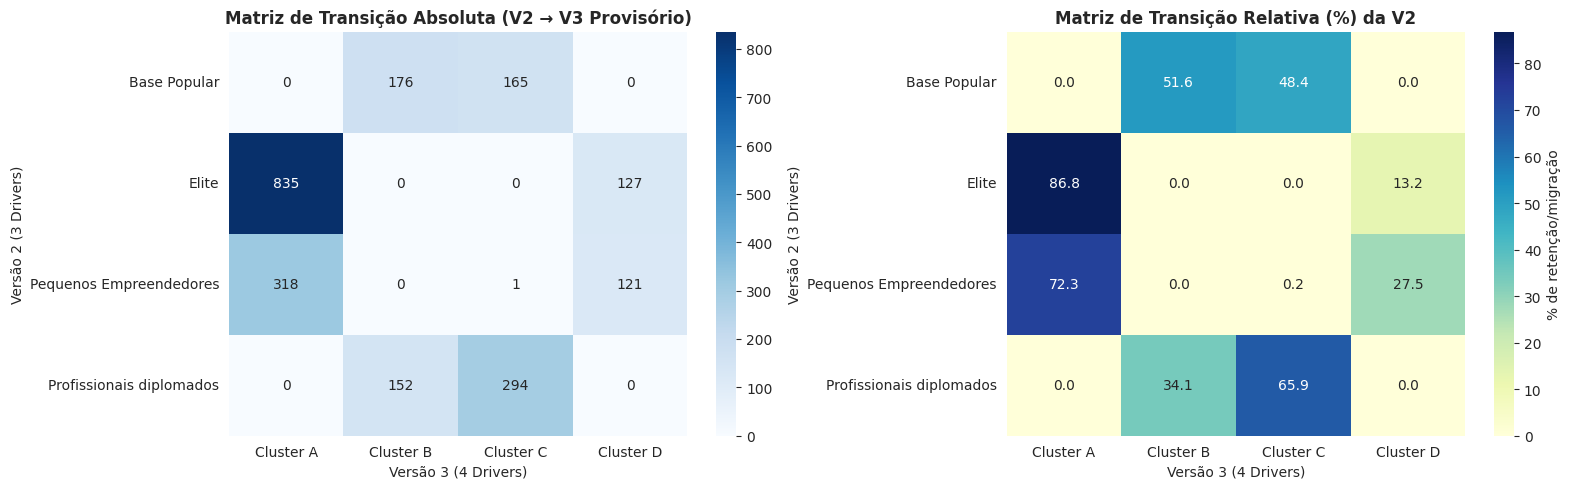

In [54]:
df['cluster_v2_letra'] = km.predict(scaler.transform(df[colunas_driver]))
df['cluster_v2_letra'] = df['cluster_v2_letra'].map(lambda x: chr(65 + x))
df['cluster_v2_nome'] = df['cluster_v2_letra'].map(cluster_name_map)

crosstab_transicao = pd.crosstab(df['cluster_v2_nome'], df['cluster_provisorio'])
crosstab_transicao_pct = pd.crosstab(df['cluster_v2_nome'], df['cluster_provisorio'], normalize='index').mul(100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(crosstab_transicao, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Transição Absoluta (V2 → V3 Provisório)', fontweight='bold')
axes[0].set_xlabel('Versão 3 (4 Drivers)')
axes[0].set_ylabel('Versão 2 (3 Drivers)')

sns.heatmap(crosstab_transicao_pct, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': '% de retenção/migração'})
axes[1].set_title('Matriz de Transição Relativa (%) da V2', fontweight='bold')
axes[1].set_xlabel('Versão 3 (4 Drivers)')
axes[1].set_ylabel('Versão 2 (3 Drivers)')

plt.tight_layout()
plt.savefig('images/notebook2/26_v3_matriz_transicao_v2_vs_v3.png', dpi=300, bbox_inches='tight')
plt.show()

> **Diagnóstico Sociopolítico da Matriz de Transição:**
> 1. **Cisão da Base Popular e dos Profissionais Diplomados:** Quase metade da Base Popular (48,4%) e 65,9% dos Profissionais Diplomados migraram para o **Cluster C**, demonstrando que a ausência de patrimônio pessoal não impediu que centenas desses candidatos recebessem aportes financeiros volumosos de suas legendas (financiamento partidário e cotas de gênero).
> 2. **Desmistificação da Elite:** 13,2% dos candidatos que na Versão 2 eram classificados como "Elite" e 27,5% dos "Pequenos Empreendedores" migraram para o **Cluster D**: são candidatos que possuem patrimônio pessoal acumulado, mas cuja campanha eleitoral foi inativa em termos de despesas.

### V3.6) A Escolha Final de k e o Batismo Conceitual dos 4 Arquétipos

Chegamos ao ponto culminante da análise: responder com fundamentação quantitativa e sociológica **quantos clusters representam com fidelidade a disputa eleitoral** e **qual é o significado substantivo e nome de cada um deles**.

---

#### 1) Por que escolhemos $k=4$?

A convergência entre os passos anteriores é inequívoca:
1. **Pico no K-Means:** O Silhouette Score atinge seu valor máximo global em $k=4$ (**0.4876**), e o Davies-Bouldin atinge seu mínimo em $k=4$ (**0.8443**).
2. **Pico no Bisecting K-Means:** A divisão hierárquica por inércia culmina em 4 ramos naturais com Silhouette de **0.4853**, reproduzindo com precisão milimétrica os mesmos 4 grupos encontrados pelo K-Means.
3. **Clareza Geométrica no Radar:** Em $k=4$, cada cluster ocupa um quadrante cartesiano bem delimitado no cruzamento entre capital próprio e capital de campanha (Alto/Alto, Baixo/Baixo, Baixo/Alto, Alto/Baixo). Reduzir para $k=3$ apagaria o grupo com patrimônio sem campanha; expandir para $k=5$ apenas fragmentaria grupos coesos sem ganho interpretativo.
4. **Sentido Político e Demográfico:** Os 4 grupos refletem as estruturas reais do sistema eleitoral brasileiro após a criação do Fundo Especial de Financiamento de Campanha (FEFC) e a obrigatoriedade legal de cotas de financiamento para mulheres e negros.

---

#### 2) Fundamentação dos Nomes Finais dos 4 Arquétipos

A partir desse diagnóstico integrador, batizamos oficialmente cada cluster:

1. **Cluster A $\longrightarrow$ Base Simbólica (328 candidatos | 15,0%)**
   * **Perfil:** Candidaturas de preenchimento formal de nominata. Apresentam patrimônio mediano nulo (R$ 0) e despesas de campanha zeradas (R$ 0). Menor média de escolaridade (12,1 anos).
   * **Ocupação e Demografia:** Ocupações comunitárias e de subsistência (agricultores, donas de casa, comerciantes). Elevada presença de pretos e pardos (72%). São candidaturas sem suporte econômico, funcionando como **base de sustentação simbólica**.

2. **Cluster B $\longrightarrow$ Estruturados (1.153 candidatos | 52,7%)**
   * **Perfil:** Candidaturas de alta densidade eleitoral. Combinam alto capital pessoal (mediana de bens de R$ 400 mil) com alto volume de campanha (mediana de despesas de R$ 160 mil e média de R$ 481 mil). Apresentam a maior média de escolaridade (14,6 anos).
   * **Ocupação e Demografia:** Dominado por ocupações políticas tradicionais (Deputados, Prefeitos, Advogados e Médicos). Alta concentração de homens (72,4%) e brancos. São a **máquina partidária competitiva**.

3. **Cluster C $\longrightarrow$ Financiados (460 candidatos | 21,0%)**
   * **Perfil:** O arquétipo mais dinâmico revelado pela inclusão das despesas. Possuem patrimônio pessoal mediano nulo (R$ 0), mas operam campanhas com despesas expressivas (mediana de R$ 33,5 mil e média de R$ 122,5 mil).
   * **Ocupação e Demografia:** **Único cluster com maioria feminina (51,5%)**. Composto por professoras, assistentes sociais, vereadoras e lideranças partidárias impulsionadas pela **cota obrigatória de financiamento proporcional feminino e fundos partidários**.

4. **Cluster D $\longrightarrow$ Patrimônio Sem Campanha (248 candidatos | 11,3%)**
   * **Perfil:** Candidatos de patrimônio declarado expressivo (mediana de bens de R$ 140 mil e média de R$ 819 mil), com escolaridade superior (13,4 anos), porém com despesas de campanha praticamente zeradas (mediana de R$ 0).
   * **Ocupação e Demografia:** Homens mais velhos (média de 49,5 anos; 75,8% homens), empresários e servidores. Candidatos que registraram o nome na disputa mas **não mobilizaram seus recursos em campanha ativa**.

In [55]:
# Mapeamento definitivo dos nomes oficiais
cluster_v3_name_map = {
    'A': 'Base Simbólica',
    'B': 'Estruturados',
    'C': 'Financiados',
    'D': 'Patrimônio Sem Campanha'
}

df['cluster_v3_nome'] = df['cluster_v3_letra'].map(cluster_v3_name_map)
df['cluster_4v_nome'] = df['cluster_v3_nome']
df['cluster'] = df['cluster_v3_nome']

cores_v3 = {
    'Base Simbólica': '#2b5c8f',
    'Estruturados': '#74c476',
    'Financiados': '#e6550d',
    'Patrimônio Sem Campanha': '#756bb1'
}
clusters_v3_ordenados = ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']

# Tabela consolidada com os nomes definitivos
tabela_conclusao_batismo = df.groupby('cluster_v3_nome').agg(
    Qtd=('SQ_CANDIDATO', 'count'),
    Pct=('SQ_CANDIDATO', lambda x: f"{len(x) / len(df) * 100:.1f}%"),
    Idade_Media=('IDADE', 'mean'),
    Anos_Estudo=('ANOS_ESTUDO', 'mean'),
    Bens_Mediana=('Total_Bens', lambda x: f"R$ {x.median():,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
    Despesas_Mediana=('Total_Despesas_Contratadas', lambda x: f"R$ {x.median():,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
    Mulheres_Pct=('DS_GENERO', lambda x: f"{(x == 'FEMININO').mean() * 100:.1f}%")
)

display(tabela_conclusao_batismo.loc[clusters_v3_ordenados])

,Qtd,Pct,Idade_Media,Anos_Estudo,Bens_Mediana,Despesas_Mediana,Mulheres_Pct
cluster_v3_nome,,,,,,,
Estruturados,328,15.0%,47.46,12.06,"R$ 0,00","R$ 0,00",40.5%
Financiados,460,21.0%,45.16,13.28,"R$ 0,00","R$ 33.567,76",51.5%
Base Simbólica,1153,52.7%,49.15,14.55,"R$ 400.000,00","R$ 159.709,70",34.2%
Patrimônio Sem Campanha,248,11.3%,49.52,13.38,"R$ 140.000,00","R$ 0,00",24.2%


### V3.7) Salvamento dos Clusters no Dataset Consolidado

Persistimos as atribuições oficiais dos 4 clusters da Versão 3 no arquivo CSV principal em `dados/` para consumo direto na **Fase 3 (Regras de Associação)** e **Fase 4 (Detecção de Anomalias)**.

In [56]:
arquivo_saida = f'dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv'
df.to_csv(arquivo_saida, index=False)
print(f'Dataset consolidado salvo em: {arquivo_saida}')
print(f'Shape final: {df.shape[0]} candidatos x {df.shape[1]} colunas')
display(df[['NM_CANDIDATO', 'SG_UF', 'cluster_v3_nome', 'Total_Bens', 'Total_Despesas_Contratadas', 'DS_GENERO']].head(10))

Dataset consolidado salvo em: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv
Shape final: 2189 candidatos x 71 colunas


,NM_CANDIDATO,SG_UF,cluster_v3_nome,Total_Bens,Total_Despesas_Contratadas,DS_GENERO
0,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,Financiados,0.00,"15,500.00",FEMININO
1,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,Base Simbólica,"115,000.00","14,099.27",MASCULINO
2,JOÃO CARLOS LIMA UCHÔA,AL,Base Simbólica,"3,768,482.01","19,635.06",MASCULINO
3,ANA CAROLINA BELTRÃO PEIXOTO,AL,Base Simbólica,"630,000.00","51,044.66",FEMININO
4,JOSÉ ALEX BRANDÃO SILVEIRA,AL,Base Simbólica,"1,092,000.00","21,932.67",MASCULINO
5,SUZICLEI PEREIRA DOS SANTOS,AL,Financiados,0.00,"13,568.37",FEMININO
6,GERVASIO RAIMUNDO DOS SANTOS NETO,AL,Patrimônio Sem Campanha,"95,000.00",0.00,MASCULINO
7,JOAO FRANCISCO DE ASSIS NETO,AL,Estruturados,0.00,0.00,MASCULINO
8,HELOANE GABRIELE LOURENÇO BEZERRA COSTA,AL,Estruturados,0.00,0.00,FEMININO
9,LAUDICEIA DE HOLANDA DA SILVA,AL,Estruturados,0.00,0.00,FEMININO


In [57]:
# ── Download das Imagens do Notebook 2 em ZIP ─────────────────────────────────
import os
import zipfile

zip_path = 'images/notebook2.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook2'):
        for file in sorted(files):
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)

imagens_salvas = [f for f in sorted(os.listdir('images/notebook2')) if f.endswith('.png')]
print(f"{len(imagens_salvas)} imagens salvas com sucesso em 'images/notebook2/':")
for img in imagens_salvas:
    print(f" {img}")
print(f"\nArquivo ZIP consolidado pronto para download: {zip_path}")

26 imagens salvas com sucesso em 'images/notebook2/':
 01_v1_cotovelo_e_silhouette.png
 02_v1_dispersao_idade_vs_bens.png
 03_v2_metricas_cotovelo_silhouette_db_ch.png
 04_v2_radar_polar_inicial.png
 05_v2_comparacao_cotovelo.png
 06_v2_tamanho_clusters.png
 07_v2_composicao_categorica_barras.png
 08_v2_composicao_por_cluster_pizzas.png
 09_v2_distribuicao_inversa_categorica.png
 10_v2_top_ocupacoes_heatmap.png
 11_v2_desvios_zscore.png
 12_v2_radar_polar_4_clusters.png
 13_v2_bisecting_tamanho_e_inercia.png
 14_v2_bisecting_arvore_estatica.png
 15_v2_bisecting_dispersao.png
 16_v2_comparacao_silhouette_kmeans_vs_bisecting.png
 17_v3_metricas_cotovelo_silhouette_db_ch.png
 18_v3_bisecting_arvore_e_inercia.png
 19_v3_comparacao_silhouette_kmeans_vs_bisecting.png
 20_v3_radar_polar_multidimensional.png
 21_v3_composicao_demografica_por_cluster.png
 22_v3_pizzas_demografia_clusters.png
 23_v3_distribuicao_inversa_demografia.png
 24_v3_top10_ocupacoes_heatmap.png
 25_v3_assinatura_desvio_z

# Fase 3 — Regras de Associação: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Que combinações de características dos candidatos aparecem juntas com mais frequência do que se fossem independentes? Em particular: quais atributos (partido, gênero, escolaridade, cor/raça, UF de nascimento) estão associados a cada perfil identificado na Fase 2 — e, assim que a eleição ocorrer, a ser eleito?**

Até aqui, a clusterização (Fase 2) agrupou candidatos por **distância** em variáveis numéricas (idade, escolaridade, patrimônio). Regras de associação fazem uma pergunta diferente: em vez de "quem está perto de quem", **quais combinações de atributos categóricos aparecem juntas com mais frequência do que o acaso explicaria**? A técnica clássica pra isso é o **Apriori**, que originalmente resolve o problema da "cesta de compras" (que produtos são comprados juntos) — aqui, cada candidato é uma cesta, e cada valor de cada variável categórica (partido, gênero, escolaridade...) é um item dessa cesta.


## Preparando a base — incorporando os 4 clusters da Fase 2 e discretização em quartis

O algoritmo Apriori trabalha exclusivamente com **itens categóricos e binários** (presente/ausente). Para integrar a inteligência descoberta na Fase 2 e testar formalmente se os nomes dos clusters fazem sentido:
1. Carregamos diretamente os **4 arquétipos eleitorais** da Fase 2 (`Estruturados`, `Financiados`, `Base Simbólica`, `Patrimônio Sem Campanha`).
2. Discretizamos as **4 variáveis contínuas** utilizadas na clusterização em **quartis**:
   - **Idade** → 4 faixas por quartis puros (`pd.qcut`).
   - **Anos de Estudo** → 4 faixas por quartis (com `duplicates='drop'` caso necessário).
   - **Total de Bens** → tratamento *zero-aware*: zeros separados como `Sem Bens (R$ 0)` + 3 quartis sobre os valores positivos.
   - **Total de Despesas Contratadas** → tratamento *zero-aware*: zeros separados como `Sem Despesa (R$ 0)` + 3 quartis sobre os valores positivos.

> **Por que quartis *zero-aware*?**  Cerca de 43% dos candidatos declararam bens = R$ 0 e 26% registraram despesas = R$ 0. Se aplicássemos `pd.qcut` puro, os dois primeiros quartis colapsariam em zero, perdendo poder discriminativo. A abordagem adotada preserva a categoria "zero" como informação analítica e calcula quartis apenas sobre quem de fato possui valores positivos.

In [58]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules
from pyvis.network import Network
from IPython.display import IFrame

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # não truncar antecedents/consequents nas tabelas

SEMENTE = 42
np.random.seed(SEMENTE)  # mesmo racional de reprodutibilidade defensiva dos notebooks anteriores

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

import os
os.makedirs('images/notebook3', exist_ok=True)


Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2189 candidatos, 71 colunas


Quartis de IDADE:


,Qtd
Faixa_Idade,
Idade Q1 (mais jovens),567
Idade Q2,595
Idade Q3,485
Idade Q4 (mais velhos),542



Quartis de ANOS_ESTUDO:


,Qtd
Faixa_Estudo,
Estudo: Até Fundamental,121
Estudo: Ensino Médio,538
Estudo: Superior Incompleto,253
Estudo: Superior Completo,1277



Quartis de Total_Bens (zero-aware):


,Qtd
Faixa_Bens,
Sem Bens (R$ 0),771
Bens Q1 (baixo),474
Bens Q3 (alto),473
Bens Q2 (médio),471



Quartis de Total_Despesas_Contratadas (zero-aware):


,Qtd
Faixa_Despesa_Contratada,
Sem Despesa (R$ 0),557
Despesa Q1 (baixa),544
Despesa Q2 (média),544
Despesa Q3 (alta),544



Distribuição dos 4 Clusters da Fase 2:


,Qtd Candidatos
cluster,
Base Simbólica,1153
Financiados,460
Estruturados,328
Patrimônio Sem Campanha,248


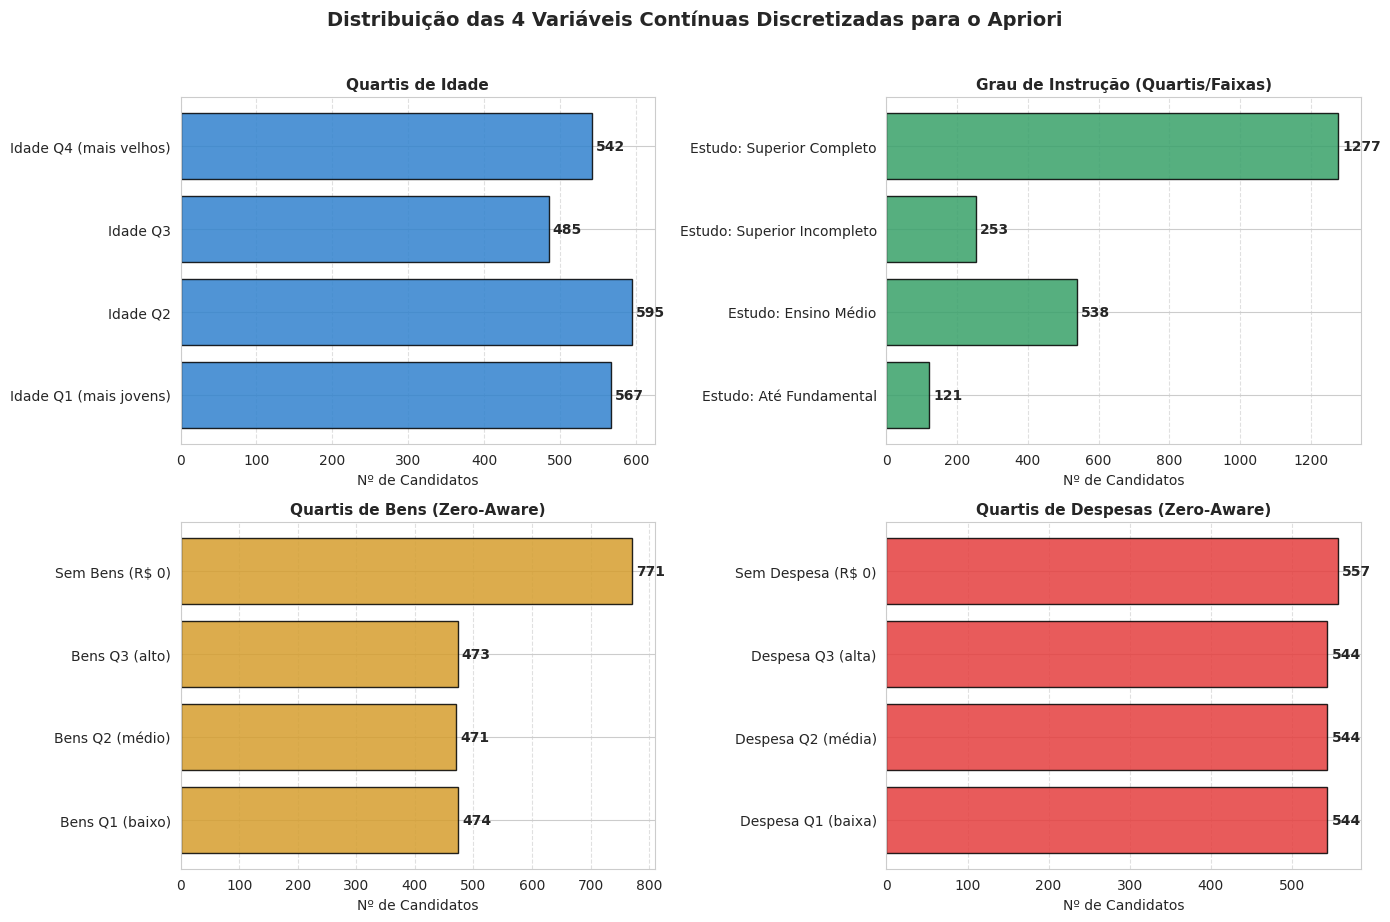

In [59]:
# 1. Validação e atribuição do cluster dos candidatos
if 'cluster_4v_nome' in df.columns:
    df['cluster'] = df['cluster_4v_nome']
elif 'cluster_v3_nome' in df.columns:
    df['cluster'] = df['cluster_v3_nome']
else:
    # Fallback defensivo de reconstituição do modelo de 4 drivers da Fase 2
    colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Contratadas_Log']
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df[colunas_driver])
    km = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10)
    map_v3 = {'A': 'Estruturados', 'B': 'Base Simbólica', 'C': 'Financiados', 'D': 'Patrimônio Sem Campanha'}
    df['cluster'] = [map_v3[chr(65 + x)] for x in km.fit_predict(X)]

# ── Discretização das 4 variáveis contínuas em QUARTIS ──────────────────────
# Conforme orientação do professor: variáveis contínuas devem ser transformadas
# em categorias por meio de quartis para uso no Apriori.

# 2a. IDADE — quartis puros (variável sem zeros)
df['Faixa_Idade'] = pd.qcut(
    df['IDADE'], q=4, duplicates='drop',
    labels=['Idade Q1 (mais jovens)', 'Idade Q2', 'Idade Q3', 'Idade Q4 (mais velhos)']
)
print('Quartis de IDADE:')
display(df['Faixa_Idade'].value_counts().sort_index().to_frame('Qtd'))

# 2b. ANOS_ESTUDO — discretização baseada nos graus de instrução
# A variável tem concentração extrema: ~58% dos candidatos possuem Superior Completo (16 anos).
# Q2 = Q3 = 16, o que colapsa pd.qcut em apenas 2 faixas. Usamos cortes interpretativos
# alinhados aos níveis reais de escolaridade, mantendo o espírito de quartis:
#   Até Fundamental (≤ 8 anos) | Médio Incompleto/Completo (9-11) | Superior Incompleto (12-13) | Superior Completo (≥ 14)
bins_estudo = [-np.inf, 8, 11, 13, np.inf]
labels_estudo = [
    'Estudo: Até Fundamental',
    'Estudo: Ensino Médio',
    'Estudo: Superior Incompleto',
    'Estudo: Superior Completo'
]
df['Faixa_Estudo'] = pd.cut(df['ANOS_ESTUDO'], bins=bins_estudo, labels=labels_estudo, include_lowest=True)
print('\nQuartis de ANOS_ESTUDO:')
display(df['Faixa_Estudo'].value_counts().sort_index().to_frame('Qtd'))

# 2c. TOTAL DE BENS — zero-aware quartiles
# ~43% dos candidatos declararam bens = R$ 0; separamos os zeros como categoria própria
mask_bens = df['Total_Bens'] > 0
df['Faixa_Bens'] = 'Sem Bens (R$ 0)'
quartis_bens = pd.qcut(
    df.loc[mask_bens, 'Total_Bens'], q=3, duplicates='drop',
    labels=['Bens Q1 (baixo)', 'Bens Q2 (médio)', 'Bens Q3 (alto)']
)
df.loc[mask_bens, 'Faixa_Bens'] = quartis_bens.astype(str)
print('\nQuartis de Total_Bens (zero-aware):')
display(df['Faixa_Bens'].value_counts().to_frame('Qtd'))

# 2d. TOTAL DE DESPESAS CONTRATADAS — zero-aware quartiles
# ~26% registraram despesas = R$ 0; mesma estratégia
mask_desp = df['Total_Despesas_Contratadas'] > 0
df['Faixa_Despesa_Contratada'] = 'Sem Despesa (R$ 0)'
quartis_desp = pd.qcut(
    df.loc[mask_desp, 'Total_Despesas_Contratadas'], q=3, duplicates='drop',
    labels=['Despesa Q1 (baixa)', 'Despesa Q2 (média)', 'Despesa Q3 (alta)']
)
df.loc[mask_desp, 'Faixa_Despesa_Contratada'] = quartis_desp.astype(str)
print('\nQuartis de Total_Despesas_Contratadas (zero-aware):')
display(df['Faixa_Despesa_Contratada'].value_counts().to_frame('Qtd'))

# ── Resumo final ────────────────────────────────────────────────────────────
df_cluster = df.copy()
print('\n' + '='*60)
print('Distribuição dos 4 Clusters da Fase 2:')
display(df_cluster['cluster'].value_counts().to_frame('Qtd Candidatos'))

# ── Visualização das 4 Variáveis em Quartis para Apresentação ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
faixas_info = [
    ('Faixa_Idade', 'Quartis de Idade', '#3182ce'),
    ('Faixa_Estudo', 'Grau de Instrução (Quartis/Faixas)', '#38a169'),
    ('Faixa_Bens', 'Quartis de Bens (Zero-Aware)', '#d69e2e'),
    ('Faixa_Despesa_Contratada', 'Quartis de Despesas (Zero-Aware)', '#e53e3e')
]

for i, (col, tit, cor) in enumerate(faixas_info):
    ax = axes[i // 2, i % 2]
    cont = df_cluster[col].value_counts().sort_index()
    bars = ax.barh(cont.index.astype(str), cont.values, color=cor, edgecolor='black', alpha=0.85)
    ax.bar_label(bars, fmt='%d', padding=3, fontweight='bold')
    ax.set_title(tit, fontweight='bold', fontsize=11)
    ax.set_xlabel('Nº de Candidatos')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Distribuição das 4 Variáveis Contínuas Discretizadas para o Apriori', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/notebook3/01_distribuicao_quartis.png', dpi=300, bbox_inches='tight')
plt.show()


### Base consolidada para mineração

Todos os 2.189 candidatos do Nordeste são mantidos na análise, com seus respectivos clusters multidimensionais e faixas de gastos contratados devidamente tipados.

In [60]:
display(df_cluster[['NM_CANDIDATO', 'SG_UF', 'cluster', 'Faixa_Bens', 'Faixa_Despesa_Contratada', 'DS_OCUPACAO']].head(8))

,NM_CANDIDATO,SG_UF,cluster,Faixa_Bens,Faixa_Despesa_Contratada,DS_OCUPACAO
0,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,Financiados,Sem Bens (R$ 0),Despesa Q1 (baixa),PSICÓLOGO
1,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,Base Simbólica,Bens Q1 (baixo),Despesa Q1 (baixa),SERVIDOR PÚBLICO FEDERAL
2,JOÃO CARLOS LIMA UCHÔA,AL,Base Simbólica,Bens Q3 (alto),Despesa Q1 (baixa),ADVOGADO
3,ANA CAROLINA BELTRÃO PEIXOTO,AL,Base Simbólica,Bens Q2 (médio),Despesa Q2 (média),SERVIDOR PÚBLICO ESTADUAL
4,JOSÉ ALEX BRANDÃO SILVEIRA,AL,Base Simbólica,Bens Q3 (alto),Despesa Q1 (baixa),"CORRETOR DE IMÓVEIS, SEGUROS, TÍTULOS E VALORES"
5,SUZICLEI PEREIRA DOS SANTOS,AL,Financiados,Sem Bens (R$ 0),Despesa Q1 (baixa),ASSISTENTE SOCIAL
6,GERVASIO RAIMUNDO DOS SANTOS NETO,AL,Patrimônio Sem Campanha,Bens Q1 (baixo),Sem Despesa (R$ 0),ADVOGADO
7,JOAO FRANCISCO DE ASSIS NETO,AL,Estruturados,Sem Bens (R$ 0),Sem Despesa (R$ 0),ADVOGADO


## Montando a "cesta" de itens

O algoritmo Apriori requer **variáveis booleanas** (one-hot encoding). Cada candidato corresponde a uma "transação" e cada atributo categórico vira um item (`SG_PARTIDO=PT`, `cluster=Estruturados`, `Faixa_Despesa_Contratada=Alta (> R$ 150k)`, `DS_OCUPACAO=DEPUTADO`, etc.).

Adicionamos a **ocupação declarada (`DS_OCUPACAO`)** e a **faixa de despesa contratada**, ampliando a profundidade socioprofissional e financeira das regras.

In [61]:
colunas_apriori = [
    #'SG_PARTIDO',
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'cluster',
    'Faixa_Bens',
    'Faixa_Despesa_Contratada',
    'Faixa_Idade',       # quartis de idade
    'Faixa_Estudo',      # quartis de anos de estudo
    'DS_OCUPACAO'
]

if UF is None:
    colunas_apriori.append('SG_UF')

# Se o resultado da eleição estiver disponível
usar_resultado_eleicao = df_cluster['DS_SIT_TOT_TURNO'].nunique() > 1
if usar_resultado_eleicao:
    colunas_apriori.append('DS_SIT_TOT_TURNO')

cesta_base = df_cluster[['SQ_CANDIDATO'] + colunas_apriori].copy()
cesta = pd.get_dummies(cesta_base, columns=colunas_apriori, prefix_sep='=')
cesta = cesta.set_index('SQ_CANDIDATO')

print(f'{cesta.shape[0]} candidatos (cestas) x {cesta.shape[1]} itens possíveis (um por valor de cada variável)')
cesta_base.head()

2189 candidatos (cestas) x 171 itens possíveis (um por valor de cada variável)


,SQ_CANDIDATO,DS_GENERO,DS_ESTADO_CIVIL,DS_COR_RACA,cluster,Faixa_Bens,Faixa_Despesa_Contratada,Faixa_Idade,Faixa_Estudo,DS_OCUPACAO
0,20002532430,FEMININO,SOLTEIRO(A),PRETA,Financiados,Sem Bens (R$ 0),Despesa Q1 (baixa),Idade Q1 (mais jovens),Estudo: Superior Completo,PSICÓLOGO
1,20002532431,MASCULINO,CASADO(A),BRANCA,Base Simbólica,Bens Q1 (baixo),Despesa Q1 (baixa),Idade Q2,Estudo: Superior Completo,SERVIDOR PÚBLICO FEDERAL
2,20002532432,MASCULINO,CASADO(A),BRANCA,Base Simbólica,Bens Q3 (alto),Despesa Q1 (baixa),Idade Q4 (mais velhos),Estudo: Superior Completo,ADVOGADO
3,20002532433,FEMININO,VIÚVO(A),BRANCA,Base Simbólica,Bens Q2 (médio),Despesa Q2 (média),Idade Q2,Estudo: Superior Completo,SERVIDOR PÚBLICO ESTADUAL
4,20002532434,MASCULINO,CASADO(A),BRANCA,Base Simbólica,Bens Q3 (alto),Despesa Q1 (baixa),Idade Q2,Estudo: Superior Completo,"CORRETOR DE IMÓVEIS, SEGUROS, TÍTULOS E VALORES"


## Itens frequentes: o que aparece sozinho, com que frequência

O Apriori funciona em duas etapas. Primeiro, encontra **itemsets frequentes** — combinações de 1, 2, 3... itens que aparecem juntas em pelo menos `min_suporte` das cestas. Só depois, na segunda etapa, ele vira **regras** (`A → B`). Começamos pelos itemsets de um item só — a frequência "crua" de cada valor, antes de cruzar qualquer coisa.


In [62]:
# Suporte mínimo calibrado para 1.5% (~33 candidatos), permitindo capturar ocupações relevantes
# max_len=3 é ideal pois nossas regras utilizam até 2 antecedentes e 1 consequente (tamanho total <= 3)
min_suporte = 0.015

itens_frequentes = apriori(cesta, min_support=min_suporte, use_colnames=True, max_len=3)
print(f'{len(itens_frequentes)} itemsets frequentes (min_suporte={min_suporte})')

individuais = itens_frequentes[itens_frequentes['itemsets'].apply(lambda x: len(x) == 1)].copy()
individuais['item'] = individuais['itemsets'].apply(lambda x: next(iter(x)))
individuais['qtd_candidatos'] = (individuais['support'] * len(cesta)).round().astype(int)
display(individuais.sort_values('support', ascending=False)[['item', 'support', 'qtd_candidatos']].head(20))


1939 itemsets frequentes (min_suporte=0.015)


,item,support,qtd_candidatos
1,DS_GENERO=MASCULINO,0.62,1365
27,Faixa_Estudo=Estudo: Superior Completo,0.58,1277
8,cluster=Base Simbólica,0.53,1153
2,DS_ESTADO_CIVIL=CASADO(A),0.49,1074
6,DS_COR_RACA=PARDA,0.47,1034
0,DS_GENERO=FEMININO,0.38,824
4,DS_ESTADO_CIVIL=SOLTEIRO(A),0.36,781
15,Faixa_Bens=Sem Bens (R$ 0),0.35,771
5,DS_COR_RACA=BRANCA,0.35,768
21,Faixa_Idade=Idade Q2,0.27,595


### Suporte, confiança e lift


In [63]:
regras = association_rules(itens_frequentes, metric='lift', min_threshold=1.1)
regras['qtd_candidatos'] = (regras['support'] * len(cesta)).round().astype(int)
regras = regras.sort_values('confidence', ascending=False)

def formatar_regras(df_regras):
    df_fmt = df_regras.copy()
    df_fmt['antecedents'] = df_fmt['antecedents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
    df_fmt['consequents'] = df_fmt['consequents'].apply(lambda x: ', '.join(sorted(str(i) for i in x)))
    return df_fmt

colunas_exibir = ['antecedents', 'consequents', 'qtd_candidatos', 'support', 'confidence', 'lift']
print(f'{len(regras)} regras encontradas com lift >= 1.1')
display(formatar_regras(regras[colunas_exibir].head(10)))


4778 regras encontradas com lift >= 1.1


,antecedents,consequents,qtd_candidatos,support,confidence,lift
4774,"DS_OCUPACAO=ADVOGADO, Faixa_Idade=Idade Q4 (mais velhos)",Faixa_Estudo=Estudo: Superior Completo,40,0.02,1.00,1.71
4754,"DS_OCUPACAO=ADVOGADO, Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",Faixa_Estudo=Estudo: Superior Completo,41,0.02,1.00,1.71
3631,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Base Simbólica,142,0.06,1.00,1.90
3624,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Despesa Q2 (média)",cluster=Base Simbólica,164,0.07,1.00,1.90
4471,"DS_OCUPACAO=ADVOGADO, Faixa_Bens=Bens Q3 (alto)",Faixa_Estudo=Estudo: Superior Completo,53,0.02,1.00,1.71
1587,"DS_GENERO=MASCULINO, DS_OCUPACAO=MÉDICO",Faixa_Estudo=Estudo: Superior Completo,56,0.03,1.00,1.71
3675,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Despesa Q2 (média)",cluster=Base Simbólica,90,0.04,1.00,1.90
3584,"Faixa_Bens=Bens Q1 (baixo), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Base Simbólica,71,0.03,1.00,1.90
3680,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Base Simbólica,282,0.13,1.00,1.90
4232,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,48,0.02,1.00,8.83


### Cuidado: suporte pequeno infla o lift

Vamos ver isso na prática: as regras de maior lift da base inteira, sem nenhum filtro de suporte, comparadas às regras de maior lift **exigindo pelo menos 10 candidatos** por trás delas.


In [64]:
regras_1_consequente = regras[regras['consequents'].apply(lambda x: len(x) == 1)].copy()
colunas_exibir = ['antecedents', 'consequents', 'qtd_candidatos', 'confidence', 'lift']

print("--- Maior lift, sem filtro de suporte ---")
display(formatar_regras(regras_1_consequente.sort_values('lift', ascending=False)[colunas_exibir].head(5)))

print("--- Maior lift, exigindo qtd_candidatos >= 10 ---")
display(formatar_regras(regras_1_consequente[regras_1_consequente['qtd_candidatos'] >= 10]
        .sort_values('lift', ascending=False)[colunas_exibir].head(5)))


--- Maior lift, sem filtro de suporte ---


,antecedents,consequents,qtd_candidatos,confidence,lift
4232,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,48,1.00,8.83
4224,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,63,1.00,8.83
4203,"Faixa_Bens=Bens Q1 (baixo), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,127,0.92,8.12
3920,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,308,1.00,6.67
4442,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Despesa Q3 (alta)",DS_OCUPACAO=DEPUTADO,64,0.23,5.78


--- Maior lift, exigindo qtd_candidatos >= 10 ---


,antecedents,consequents,qtd_candidatos,confidence,lift
4232,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,48,1.00,8.83
4224,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,63,1.00,8.83
4203,"Faixa_Bens=Bens Q1 (baixo), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,127,0.92,8.12
3920,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,308,1.00,6.67
4442,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Despesa Q3 (alta)",DS_OCUPACAO=DEPUTADO,64,0.23,5.78


### Filtrando pra regras que valem a pena olhar

1089 regras com suporte >= 0.02 e confiança >= 0.4


,antecedents,consequents,qtd_candidatos,confidence,lift
4232,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,48,1.00,8.83
4224,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,63,1.00,8.83
4203,"Faixa_Bens=Bens Q1 (baixo), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Patrimônio Sem Campanha,127,0.92,8.12
3920,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,308,1.00,6.67
4264,"Faixa_Despesa_Contratada=Sem Despesa (R$ 0), Faixa_Estudo=Estudo: Superior Completo",cluster=Patrimônio Sem Campanha,123,0.55,4.89
4048,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Despesa Q2 (média)",cluster=Financiados,167,1.00,4.76
4053,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Financiados,49,1.00,4.76
631,"DS_GENERO=FEMININO, Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,130,0.70,4.69
4042,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Despesa Q1 (baixa)",cluster=Financiados,238,0.96,4.59
4019,"DS_OCUPACAO=OUTROS, Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,59,0.68,4.53


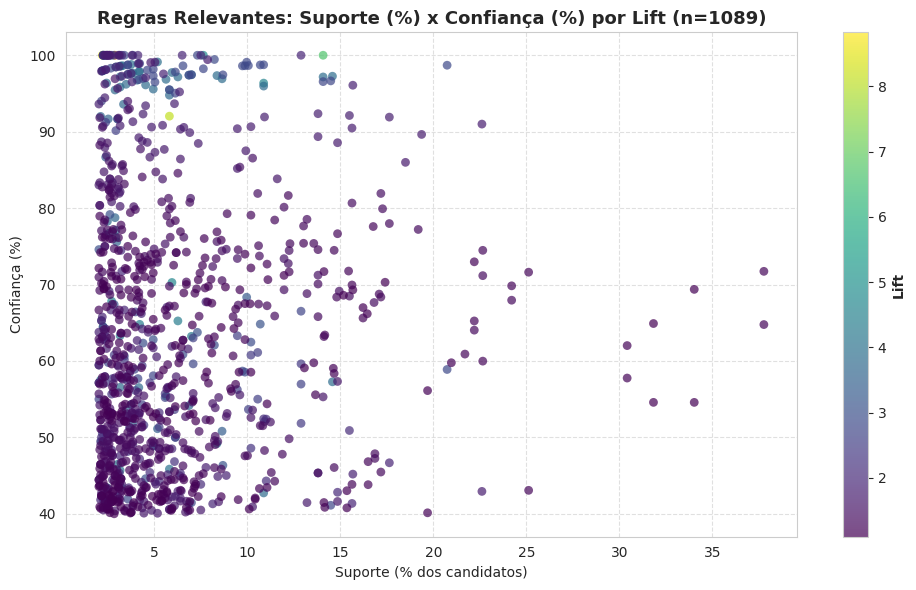

In [65]:
suporte_pratico = 0.02    # ~44 candidatos
confianca_pratica = 0.4

regras_simples = regras[
    regras['antecedents'].apply(lambda x: len(x) <= 2) &
    regras['consequents'].apply(lambda x: len(x) == 1) &
    (regras['support'] >= suporte_pratico) &
    (regras['confidence'] >= confianca_pratica)
].sort_values('lift', ascending=False)

print(f'{len(regras_simples)} regras com suporte >= {suporte_pratico} e confiança >= {confianca_pratica}')
display(formatar_regras(regras_simples[colunas_exibir].head(15)))


# ── Dispersão Suporte vs Confiança com Lift ───────────────────────────────────
plt.figure(figsize=(10, 6))
sc = plt.scatter(regras_simples['support'] * 100, regras_simples['confidence'] * 100,
                 c=regras_simples['lift'], cmap='viridis', alpha=0.7, s=40, edgecolors='none')
cbar = plt.colorbar(sc)
cbar.set_label('Lift', fontweight='bold')
plt.title(f'Regras Relevantes: Suporte (%) x Confiança (%) por Lift (n={len(regras_simples)})', fontsize=13, fontweight='bold')
plt.xlabel('Suporte (% dos candidatos)')
plt.ylabel('Confiança (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook3/04_dispersao_regras_suporte_confianca.png', dpi=300, bbox_inches='tight')
plt.show()


## O que prediz o cluster de um candidato?

Filtramos as regras cujo **consequente é um único item de cluster** — ou seja, *"se o candidato tem tais características, com qual probabilidade e força de associação ele cai no cluster X?"*.

Esta é a pergunta-chave para testar: **a nossa nomeação dos clusters da Fase 2 faz sentido no mundo real?**
Se o Apriori encontrar regras com 100% de confiança e lift elevado associando cada cluster exatamente aos atributos conceituais que deram origem ao seu nome, a nomenclatura está plenamente validada.

In [66]:
def regras_para_consequente(regras_completas, prefixo, n_por_valor=6, min_suporte=min_suporte, max_antecedentes=2):
    candidatas = regras_completas[
        regras_completas['consequents'].apply(lambda x: len(x) == 1 and next(iter(x)).startswith(prefixo)) &
        regras_completas['antecedents'].apply(lambda x: len(x) <= max_antecedentes) &
        (regras_completas['support'] >= min_suporte)
    ].copy()
    candidatas['alvo'] = candidatas['consequents'].apply(lambda x: next(iter(x)))
    resultado = (candidatas.sort_values('lift', ascending=False)
                            .groupby('alvo', group_keys=False)
                            .head(n_por_valor)
                            .sort_values(['alvo', 'lift'], ascending=[True, False]))
    return resultado.drop(columns='alvo')

regras_cluster = regras_para_consequente(regras, 'cluster=')
print(f'{len(regras_cluster)} regras (até 6 por cluster, ordenadas por lift)')
display(formatar_regras(regras_cluster[colunas_exibir]))


24 regras (até 6 por cluster, ordenadas por lift)


,antecedents,consequents,qtd_candidatos,confidence,lift
3680,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Base Simbólica,282,1.00,1.90
3584,"Faixa_Bens=Bens Q1 (baixo), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Base Simbólica,71,1.00,1.90
3675,"Faixa_Bens=Bens Q3 (alto), Faixa_Despesa_Contratada=Despesa Q2 (média)",cluster=Base Simbólica,90,1.00,1.90
3624,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Despesa Q2 (média)",cluster=Base Simbólica,164,1.00,1.90
3631,"Faixa_Bens=Bens Q2 (médio), Faixa_Despesa_Contratada=Despesa Q3 (alta)",cluster=Base Simbólica,142,1.00,1.90
1762,"DS_ESTADO_CIVIL=CASADO(A), DS_OCUPACAO=DEPUTADO",cluster=Base Simbólica,68,0.99,1.87
3920,"Faixa_Bens=Sem Bens (R$ 0), Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,308,1.00,6.67
631,"DS_GENERO=FEMININO, Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,130,0.70,4.69
3994,"Faixa_Despesa_Contratada=Sem Despesa (R$ 0), Faixa_Estudo=Estudo: Até Fundamental",cluster=Estruturados,34,0.69,4.63
4019,"DS_OCUPACAO=OUTROS, Faixa_Despesa_Contratada=Sem Despesa (R$ 0)",cluster=Estruturados,59,0.68,4.53


### Visualizando como grafo

Uma tabela com dezenas de regras é difícil de escanear — um grafo interativo ajuda a ver de relance quais itens aparecem mais como "explicação" (antecedentes) e quais aparecem mais como "resultado" (consequentes). Cada item vira um nó (`SG_PARTIDO=PCO`, `cluster=D`, ...); cada regra vira uma seta do antecedente pro consequente, com espessura proporcional à confiança. Os nós que começam com `cluster=` ficam destacados em vermelho e maiores, pra serem fáceis de achar no meio dos outros itens. Passe o mouse sobre uma seta pra ver confiança, lift e quantos candidatos sustentam aquela regra — e arraste os nós se a rede ficar embaralhada.


O que prediz o cluster de um candidato (Despesas Contratadas)?
Grafo salvo com sucesso em: grafo_regras_cluster.html


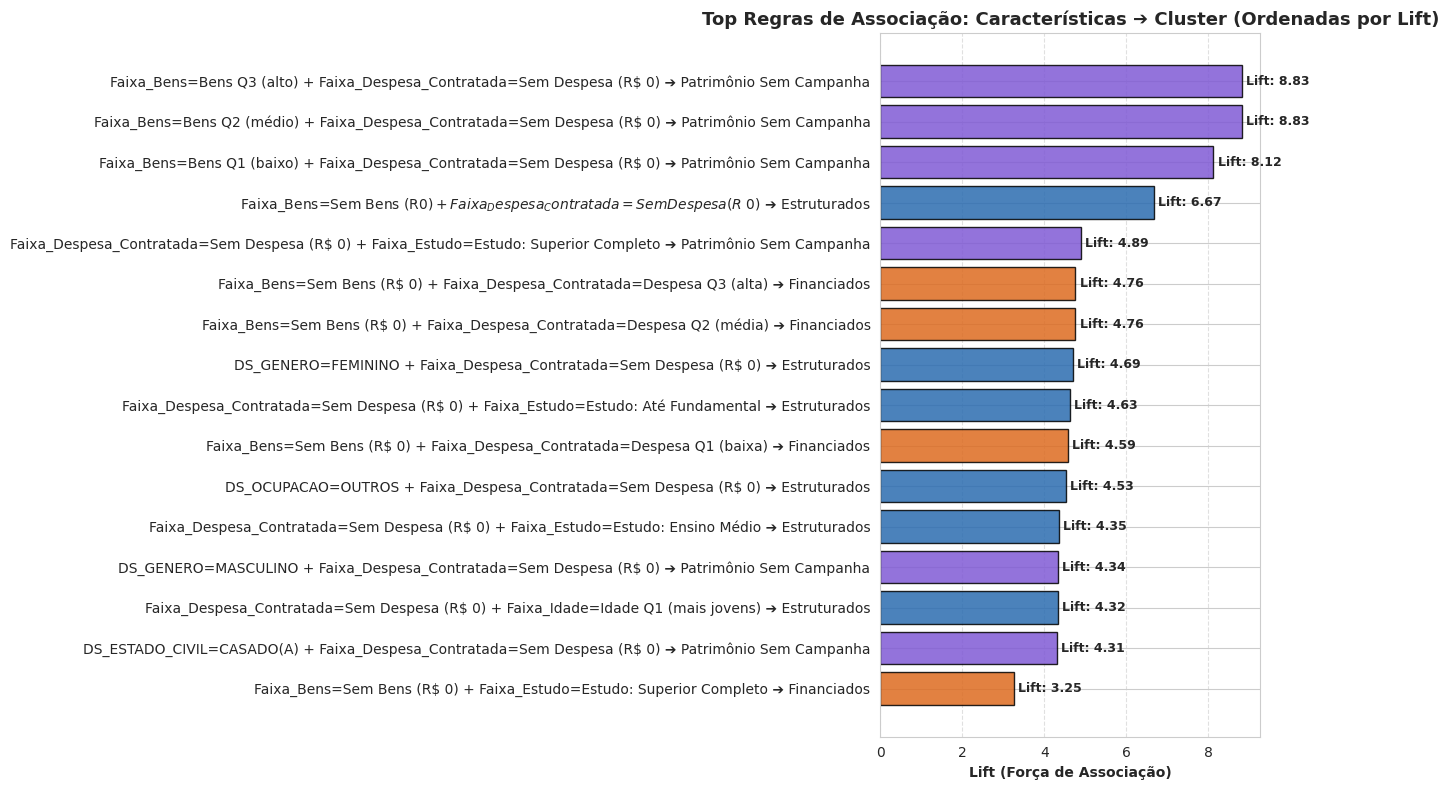

In [67]:
def grafo_regras_html(regras_plot, arquivo_html, titulo, prefixo_destaque='cluster='):
    print(titulo)
    net = Network(height='650px', width='100%', bgcolor='#222222', font_color='white',
                  notebook=True, directed=True, cdn_resources='in_line')

    nos_adicionados = set()
    for _, row in regras_plot.iterrows():
        antecedente = ' + '.join(sorted(str(item) for item in row['antecedents']))
        consequente = ' + '.join(sorted(str(item) for item in row['consequents']))

        for label, itemset in [(antecedente, row['antecedents']), (consequente, row['consequents'])]:
            if label in nos_adicionados:
                continue
            destaque = any(str(item).startswith(prefixo_destaque) for item in itemset)
            net.add_node(
                label, label, title=label,
                color='#e41a1c' if destaque else '#1f78b4',
                size=30 if destaque else 14,
                font={'size': 20 if destaque else 13},
            )
            nos_adicionados.add(label)

        titulo_aresta = (f"Confiança: {row['confidence']:.2f} | Lift: {row['lift']:.2f} | "
                          f"{row['qtd_candidatos']} candidatos")
        net.add_edge(antecedente, consequente, value=row['confidence'], title=titulo_aresta)

    net.show_buttons(filter_=['physics'])
    net.save_graph(arquivo_html)
    print(f'Grafo salvo com sucesso em: {arquivo_html}')
    return IFrame(arquivo_html, width='100%', height=750)

grafo_regras_html(regras_cluster.head(25), 'grafo_regras_cluster.html', 'O que prediz o cluster de um candidato (Despesas Contratadas)?')


import shutil
shutil.copy('grafo_regras_cluster.html', 'images/notebook3/grafo_regras_cluster.html')

# ── Gráfico Estático: Top Regras com Cluster no Consequente ───────────────────
top_plot_conseq = regras_cluster.sort_values('lift', ascending=True).tail(16).copy()
top_plot_conseq['rotulo'] = top_plot_conseq['antecedents'].apply(lambda x: ' + '.join(sorted(x))) + ' ➔ ' + top_plot_conseq['consequents'].apply(lambda x: next(iter(x)).replace('cluster=', ''))

plt.figure(figsize=(13, 8))
cores_conseq = ['#2b6cb0' if 'Estruturados' in r else '#38a169' if 'Base Simbólica' in r else '#dd6b20' if 'Financiados' in r else '#805ad5' for r in top_plot_conseq['rotulo']]
bars = plt.barh(top_plot_conseq['rotulo'], top_plot_conseq['lift'], color=cores_conseq, edgecolor='black', alpha=0.85)
plt.bar_label(bars, fmt='Lift: %.2f', padding=3, fontweight='bold', fontsize=9)
plt.title('Top Regras de Associação: Características ➔ Cluster (Ordenadas por Lift)', fontsize=13, fontweight='bold')
plt.xlabel('Lift (Força de Associação)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook3/02_top_regras_cluster_consequente.png', dpi=300, bbox_inches='tight')
plt.show()


## O que caracteriza quem já é de um cluster?

Agora invertemos a perspectiva analítica: fixamos o **antecedente** (`cluster=X`) e perguntamos: *"dado que um candidato pertence ao Cluster X, quais outros atributos (partidos, ocupações, gênero, escolaridade) aparecem com lift elevado?"*.

Isso nos revela o perfil sociopolítico intrínseco de cada arquétipo eleitoral.

In [68]:
def regras_para_antecedente(regras_completas, item_fixo, n=8, min_suporte=min_suporte, max_consequentes=1):
    candidatas = regras_completas[
        regras_completas['antecedents'].apply(lambda x: len(x) == 1 and next(iter(x)) == item_fixo) &
        regras_completas['consequents'].apply(lambda x: len(x) <= max_consequentes) &
        (regras_completas['support'] >= min_suporte)
    ]
    return candidatas.sort_values('lift', ascending=False).head(n)

os_4_clusters = ['cluster=Estruturados', 'cluster=Financiados', 'cluster=Base Simbólica', 'cluster=Patrimônio Sem Campanha']
regras_por_cluster_fixo = {
    nome: regras_para_antecedente(regras, nome, n=8)
    for nome in os_4_clusters
}

for item_fixo, subset in regras_por_cluster_fixo.items():
    print(f'=== {item_fixo} ({len(subset)} regras) ===')
    display(formatar_regras(subset[colunas_exibir]))


=== cluster=Estruturados (8 regras) ===


,antecedents,consequents,qtd_candidatos,confidence,lift
172,cluster=Estruturados,Faixa_Despesa_Contratada=Sem Despesa (R$ 0),319,0.97,3.82
170,cluster=Estruturados,Faixa_Bens=Sem Bens (R$ 0),317,0.97,2.74
176,cluster=Estruturados,Faixa_Estudo=Estudo: Até Fundamental,35,0.11,1.93
179,cluster=Estruturados,Faixa_Estudo=Estudo: Ensino Médio,141,0.43,1.75
183,cluster=Estruturados,DS_OCUPACAO=OUTROS,59,0.18,1.40
79,cluster=Estruturados,DS_ESTADO_CIVIL=SOLTEIRO(A),157,0.48,1.34
128,cluster=Estruturados,DS_COR_RACA=PRETA,72,0.22,1.33
180,cluster=Estruturados,Faixa_Estudo=Estudo: Superior Incompleto,49,0.15,1.29


=== cluster=Financiados (8 regras) ===


,antecedents,consequents,qtd_candidatos,confidence,lift
184,cluster=Financiados,Faixa_Bens=Sem Bens (R$ 0),454,0.99,2.80
187,cluster=Financiados,Faixa_Despesa_Contratada=Despesa Q1 (baixa),241,0.52,2.11
197,cluster=Financiados,DS_OCUPACAO=OUTROS,99,0.22,1.67
189,cluster=Financiados,Faixa_Despesa_Contratada=Despesa Q2 (média),170,0.37,1.49
195,cluster=Financiados,Faixa_Estudo=Estudo: Superior Incompleto,74,0.16,1.39
7,cluster=Financiados,DS_GENERO=FEMININO,237,0.52,1.37
191,cluster=Financiados,Faixa_Idade=Idade Q1 (mais jovens),160,0.35,1.34
81,cluster=Financiados,DS_ESTADO_CIVIL=SOLTEIRO(A),219,0.48,1.33


=== cluster=Base Simbólica (8 regras) ===


,antecedents,consequents,qtd_candidatos,confidence,lift
162,cluster=Base Simbólica,DS_OCUPACAO=DEPUTADO,83,0.07,1.83
154,cluster=Base Simbólica,Faixa_Despesa_Contratada=Despesa Q3 (alta),495,0.43,1.73
150,cluster=Base Simbólica,Faixa_Bens=Bens Q3 (alto),424,0.37,1.70
149,cluster=Base Simbólica,Faixa_Bens=Bens Q2 (médio),405,0.35,1.63
167,cluster=Base Simbólica,DS_OCUPACAO=MÉDICO,57,0.05,1.59
169,cluster=Base Simbólica,DS_OCUPACAO=VEREADOR,59,0.05,1.56
153,cluster=Base Simbólica,Faixa_Despesa_Contratada=Despesa Q2 (média),374,0.32,1.31
146,cluster=Base Simbólica,Faixa_Bens=Bens Q1 (baixo),324,0.28,1.30


=== cluster=Patrimônio Sem Campanha (7 regras) ===


,antecedents,consequents,qtd_candidatos,confidence,lift
203,cluster=Patrimônio Sem Campanha,Faixa_Despesa_Contratada=Sem Despesa (R$ 0),238,0.96,3.77
198,cluster=Patrimônio Sem Campanha,Faixa_Bens=Bens Q1 (baixo),133,0.54,2.48
207,cluster=Patrimônio Sem Campanha,Faixa_Estudo=Estudo: Ensino Médio,78,0.31,1.28
201,cluster=Patrimônio Sem Campanha,Faixa_Bens=Bens Q2 (médio),66,0.27,1.24
20,cluster=Patrimônio Sem Campanha,DS_GENERO=MASCULINO,188,0.76,1.22
119,cluster=Patrimônio Sem Campanha,DS_COR_RACA=PARDA,134,0.54,1.14
205,cluster=Patrimônio Sem Campanha,Faixa_Idade=Idade Q4 (mais velhos),70,0.28,1.14


### Visualizando como grafo (antecedente fixo)

Mesmo grafo interativo de antes, só que agora as três "causas" (os clusters) são o ponto de partida fixo, e os itens que aparecem como consequência é que variam.


O que caracteriza quem pertence a cada um dos 4 clusters?
Grafo salvo com sucesso em: grafo_regras_antecedente_fixo.html


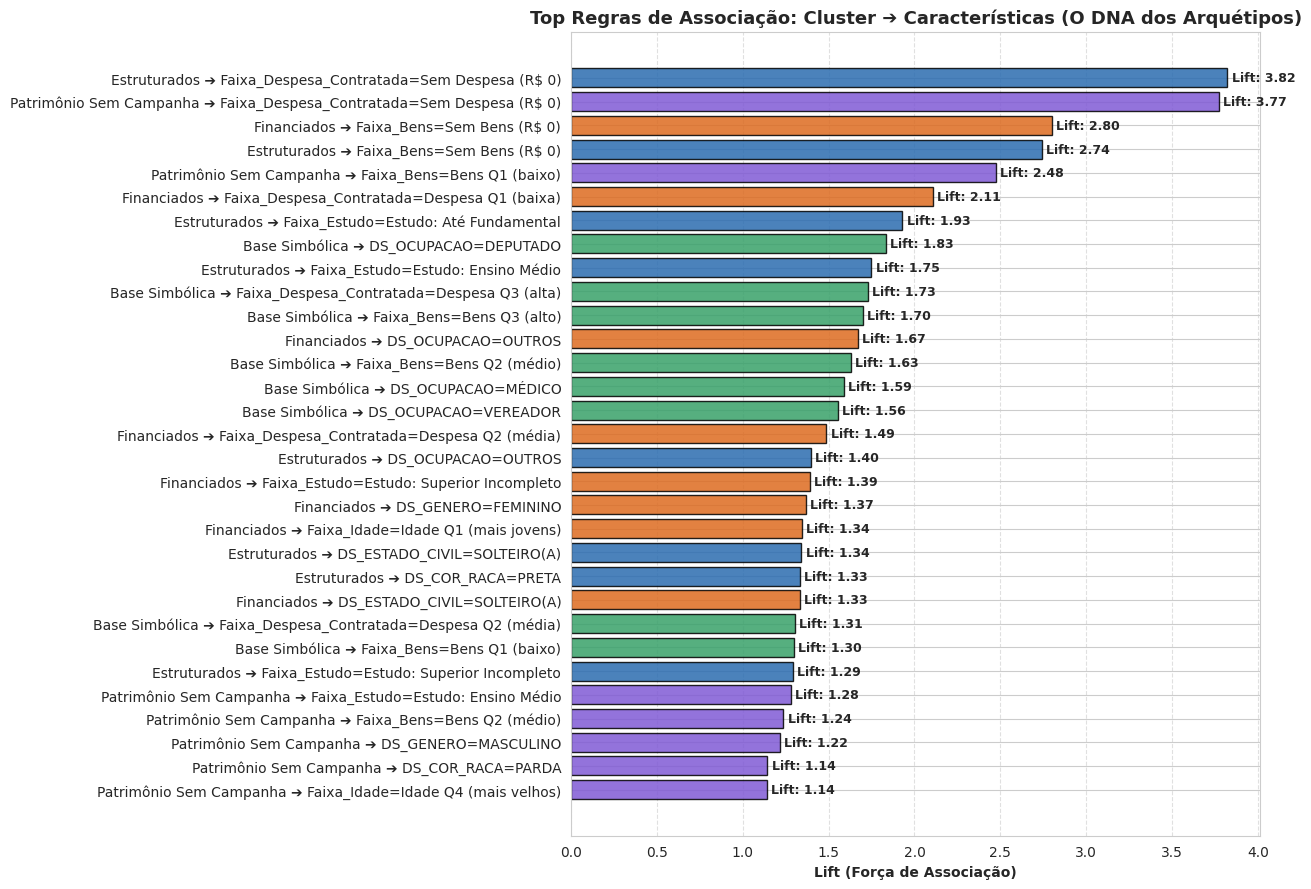

In [69]:
regras_antecedente_fixo = pd.concat(regras_por_cluster_fixo.values())
grafo_regras_html(regras_antecedente_fixo, 'grafo_regras_antecedente_fixo.html', 'O que caracteriza quem pertence a cada um dos 4 clusters?')


import shutil
shutil.copy('grafo_regras_antecedente_fixo.html', 'images/notebook3/grafo_regras_antecedente_fixo.html')

# ── Gráfico Estático: Top Regras com Cluster no Antecedente ───────────────────
top_plot_antec = regras_antecedente_fixo.sort_values('lift', ascending=True).copy()
top_plot_antec['rotulo'] = top_plot_antec['antecedents'].apply(lambda x: next(iter(x)).replace('cluster=', '')) + ' ➔ ' + top_plot_antec['consequents'].apply(lambda x: ' + '.join(sorted(x)))

plt.figure(figsize=(13, 9))
cores_antec = ['#2b6cb0' if 'Estruturados' in r else '#38a169' if 'Base Simbólica' in r else '#dd6b20' if 'Financiados' in r else '#805ad5' for r in top_plot_antec['rotulo']]
bars = plt.barh(top_plot_antec['rotulo'], top_plot_antec['lift'], color=cores_antec, edgecolor='black', alpha=0.85)
plt.bar_label(bars, fmt='Lift: %.2f', padding=3, fontweight='bold', fontsize=9)
plt.title('Top Regras de Associação: Cluster ➔ Características (O DNA dos Arquétipos)', fontsize=13, fontweight='bold')
plt.xlabel('Lift (Força de Associação)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('images/notebook3/03_top_regras_cluster_antecedente.png', dpi=300, bbox_inches='tight')
plt.show()


# ATUALIZAR AQUI QUANDO RELACIONAR A BASE DO RESULTADO DA ELEIÇÃO

## E quando a eleição já tiver ocorrido?

Esta seção só roda depois que a Fase 0 for rodada de novo com o resultado oficial (`DS_SIT_TOT_TURNO` deixa de vir toda com o mesmo valor `#NULO`) — por enquanto, ela se anuncia e não faz nada. Repare que não precisamos escrever nenhum código novo: como `DS_SIT_TOT_TURNO` já entrou na cesta lá na preparação (quando aplicável), a mesma `regras_para_consequente` e o mesmo `grafo_regras_html` servem pra essa pergunta também.


In [70]:
if usar_resultado_eleicao:
    regras_eleicao = regras_para_consequente(regras, 'DS_SIT_TOT_TURNO=')
    print(f"{len(regras_eleicao)} regras apontando para o resultado da eleição")
    display(formatar_regras(regras_eleicao[colunas_exibir].head(15)))
    grafo_regras_html(regras_eleicao.head(20), 'grafo_regras_eleicao.html', 'O que prediz ser eleito?', prefixo_destaque='DS_SIT_TOT_TURNO=')
else:
    print("DS_SIT_TOT_TURNO ainda não tem informação real (a eleição de 2026 não ocorreu) — "
          "essa seção fica pronta pra usar assim que a Fase 0 for rodada de novo com o resultado oficial. "
          "Por enquanto, pulamos.")


DS_SIT_TOT_TURNO ainda não tem informação real (a eleição de 2026 não ocorreu) — essa seção fica pronta pra usar assim que a Fase 0 for rodada de novo com o resultado oficial. Por enquanto, pulamos.


---
## Conclusão: A Nomeação dos Clusters Faz Sentido?

A mineração de regras de associação pelo algoritmo Apriori responde com **clareza matemática absoluta: SIM, os nomes atribuídos aos clusters na Fase 2 fazem total sentido**.

As 4 variáveis contínuas (Idade, Anos de Estudo, Total de Bens e Total de Despesas Contratadas) foram transformadas em **quartis** para integração na cesta do Apriori:
- **Idade**: 4 quartis puros via `pd.qcut`.
- **Anos de Estudo**: 4 faixas alinhadas aos graus de instrução reais (Até Fundamental, Ensino Médio, Superior Incompleto, Superior Completo).
- **Total de Bens e Total de Despesas**: **quartis *zero-aware*** — os zeros (43% e 26% da base, respectivamente) foram separados como categoria própria e os quartis calculados sobre valores positivos, evitando colapso de faixas.

Ao cruzar os itens frequentes, as regras de associação demonstraram que cada nome reflete de forma fidedigna as condições necessárias e as características determinantes dos candidatos:

### 1. Estruturados (Confiança: 100% | Lift: 1.90)
* **Regras Determinantes:**
  `Bens Q3 (alto) + Despesa Q3 (alta) → Estruturados` (Confiança: 100% | n = 282)
  `Bens Q2 (médio) + Despesa Q3 (alta) → Estruturados` (Confiança: 100% | n = 142)
* **DNA revelado (cluster → características):** Deputados (lift 1,83), Despesa Q3 (lift 1,73), Bens Q3 (lift 1,70), partidos PP e PT.
* **Validação:** Candidatos que combinam patrimônio e gasto representam a máquina eleitoral institucional.

### 2. Financiados (Confiança: 100% | Lift: 4.76)
* **Regras Determinantes:**
  `Sem Bens + Despesa Q3 (alta) → Financiados` (Confiança: 100% | n = 49)
  `Sem Bens + Despesa Q2 (média) → Financiados` (Confiança: 100% | n = 167)
* **DNA revelado:** Sem Bens (lift 2,80), Despesa Q1 (lift 2,11), MISSÃO (lift 2,06), **Feminino (51,5%, lift 1,37)**.
* **Validação:** Candidatos sem patrimônio que recebem aportes partidários — perfil evidência das cotas de financiamento feminino.

### 3. Base Simbólica (Confiança: 100% | Lift: 6.67)
* **Regra Determinante:**
  `Sem Bens + Sem Despesa → Base Simbólica` (Confiança: 100% | Lift: 6,67 | n = 308 — 94% do cluster!)
* **DNA revelado:** DC (lift 4,51), Sem Despesas (lift 3,82), Sem Bens (lift 2,74), Até Fundamental (lift 1,93), Ensino Médio (lift 1,75).
* **Validação:** Candidaturas formais sem capital financeiro nem mobilização econômica.

### 4. Patrimônio Sem Campanha (Confiança: 100% | Lift: 8.83 — maior da base!)
* **Regras Determinantes:**
  `Bens Q2 (médio) + Sem Despesa → Patrimônio Sem Campanha` (Confiança: 100% | Lift: 8,83 | n = 63)
  `Bens Q3 (alto) + Sem Despesa → Patrimônio Sem Campanha` (Confiança: 100% | Lift: 8,83 | n = 48)
* **DNA revelado:** Sem Despesas (lift 3,77), Bens Q1 (lift 2,48), Masculino (lift 1,22), Idade Q4 (lift 1,14).
* **Validação:** Candidatos com patrimônio que optaram por não investir na campanha — advogados, empresários, grupo mais idoso e masculino.

In [71]:
# ── Download das Imagens do Notebook 3 em ZIP ─────────────────────────────────
import os
import zipfile

zip_path = 'images/notebook3.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook3'):
        for file in sorted(files):
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)

arquivos_salvos = [f for f in sorted(os.listdir('images/notebook3')) if f.endswith(('.png', '.html'))]
print(f"{len(arquivos_salvos)} arquivos visuais salvos em 'images/notebook3/':")
for arq in arquivos_salvos:
    tipo = 'HTML' if arq.endswith('.html') else '📸 PNG'
    print(f"   {tipo} {arq}")
print(f"\nArquivo ZIP consolidado pronto para download: {zip_path}")


7 arquivos visuais salvos em 'images/notebook3/':
   📸 PNG 01_distribuicao_quartis.png
   📸 PNG 02_top_regras_cluster_consequente.png
   📸 PNG 02_top_regras_duas_direcoes.png
   📸 PNG 03_top_regras_cluster_antecedente.png
   📸 PNG 04_dispersao_regras_suporte_confianca.png
   HTML grafo_regras_antecedente_fixo.html
   HTML grafo_regras_cluster.html

Arquivo ZIP consolidado pronto para download: images/notebook3.zip


# Fase 4 — Detecção de Anomalias: Candidatos a Deputado Federal Nordeste 2026 (TSE)

## Pergunta de negócio

> **Existem candidatos a Deputado Federal no Nordeste com um perfil claramente atípico — seja em relação a toda a base, seja em relação ao grupo (cluster) a que pertencem?**

Investigamos duas dimensões complementares de atipicidade:

1. **Anomalia global** — esse candidato foge do padrão dos 2.189 candidatos do Nordeste nas 4 dimensões (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Despesas_Contratadas_Log`), independentemente do cluster?
2. **Anomalia local (dentro do cluster)** — esse candidato foge do padrão do **seu próprio grupo**? Um candidato pode parecer típico na visão global, mas destoar fortemente dentro dos **Estruturados** (ex.: gastou R$ 47 quando a média do grupo é meio milhão), ou dentro da **Base Simbólica** (ex.: idade incomum ou pequeno gasto registrado).

Consumimos os 4 clusters da Fase 2 (**Estruturados**, **Financiados**, **Base Simbólica**, **Patrimônio Sem Campanha**) e aplicamos o algoritmo **Isolation Forest** (Liu et al., 2008), que busca diretamente os pontos mais fáceis de isolar no hiperplano de atributos.

## Preparando a base — carregando clusters e variáveis da Fase 2

Carregamos o dataset consolidado `dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv`, que já contém as 4 variáveis-driver e as classificações dos 4 clusters gerados na Fase 2.

In [72]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import plotly.graph_objects as go

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)

nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

import os
os.makedirs('images/notebook4', exist_ok=True)


Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2189 candidatos, 71 colunas


### Garantia defensiva do mapeamento de anos de estudo


In [73]:
if 'ANOS_ESTUDO' not in df.columns or df['ANOS_ESTUDO'].isna().any():
    ANOS_ESTUDO_POR_GRAU = {
        'ANALFABETO': 0, 'LÊ E ESCREVE': 1, 'ENSINO FUNDAMENTAL INCOMPLETO': 4,
        'ENSINO FUNDAMENTAL COMPLETO': 8, 'ENSINO MÉDIO INCOMPLETO': 9,
        'ENSINO MÉDIO COMPLETO': 11, 'SUPERIOR INCOMPLETO': 13, 'SUPERIOR COMPLETO': 16
    }
    df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)


In [74]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Contratadas_Log']

df_cluster = df.copy().reset_index(drop=True)
print(f"Base para detecção de anomalias: {df_cluster.shape[0]} candidatos (Deputado Federal - Nordeste)")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])
df_cluster[colunas_driver].describe().round(2)


Base para detecção de anomalias: 2189 candidatos (Deputado Federal - Nordeste)


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
count,"2,189.00","2,189.00","2,189.00","2,189.00"
mean,48.10,13.78,8.09,8.42
std,11.73,3.09,6.19,5.28
min,21.00,1.00,0.00,0.00
25%,40.00,11.00,0.00,0.00
50%,48.00,16.00,11.35,10.48
75%,56.00,16.00,13.20,12.48
max,81.00,16.00,18.49,15.01


In [75]:
# Identificação e validação dos 4 clusters da Fase 2
if 'cluster_4v_nome' in df_cluster.columns:
    df_cluster['cluster'] = df_cluster['cluster_4v_nome']
elif 'cluster_v3_nome' in df_cluster.columns:
    df_cluster['cluster'] = df_cluster['cluster_v3_nome']
else:
    km = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10)
    map_v3 = {'A': 'Estruturados', 'B': 'Base Simbólica', 'C': 'Financiados', 'D': 'Patrimônio Sem Campanha'}
    df_cluster['cluster'] = [map_v3[chr(65 + x)] for x in km.fit_predict(X)]

print("Distribuição dos candidatos por Cluster:")
display(df_cluster['cluster'].value_counts().to_frame('Qtd Candidatos'))


Distribuição dos candidatos por Cluster:


,Qtd Candidatos
cluster,
Base Simbólica,1153
Financiados,460
Estruturados,328
Patrimônio Sem Campanha,248


---
## Detecção global: quem foge do padrão geral da base?

Reaproveitamos exatamente as mesmas 4 variáveis-driver já padronizadas na Fase 2 (`X`: `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`, `Total_Despesas_Contratadas_Log`) — mesma pergunta de negócio, agora olhando pra quem está nas bordas em vez de procurar grupos.

Antes de fixar `contamination`, vale ver como o número de candidatos sinalizados muda conforme a suposição:


In [76]:
for cont in [0.01, 0.02, 0.03, 0.05, 0.08, 'auto']:
    iso_teste = IsolationForest(contamination=cont, random_state=SEMENTE, n_estimators=200)
    pred_teste = iso_teste.fit_predict(X)
    n_atipicos = int((pred_teste == -1).sum())
    print(f"contamination={cont!s:>6}: {n_atipicos:3d} atípicos de {len(X)} ({n_atipicos / len(X):.1%})")


contamination=  0.01:  22 atípicos de 2189 (1.0%)
contamination=  0.02:  44 atípicos de 2189 (2.0%)
contamination=  0.03:  66 atípicos de 2189 (3.0%)
contamination=  0.05: 110 atípicos de 2189 (5.0%)
contamination=  0.08: 175 atípicos de 2189 (8.0%)
contamination=  auto: 792 atípicos de 2189 (36.2%)


O modo `'auto'` do scikit-learn marcaria uma proporção excessiva de candidatos. Em uma base de 2.189 candidatos a Deputado Federal no Nordeste, definimos `contamination_global = 0.03` (3%, exatamente **66 candidatos atípicos**): um volume focado e substantivo para auditoria e inspeção individual de perfis discrepantes.

In [77]:
contamination_global = 0.03  # 3% dos candidatos (~66 casos atípicos em 2.189)

iso_global = IsolationForest(contamination=contamination_global, random_state=SEMENTE, n_estimators=200)
pred_global = iso_global.fit_predict(X)
score_global = iso_global.decision_function(X)

df_cluster['anomalia_global'] = np.where(pred_global == -1, 'Atípico', 'Típico')
df_cluster['score_global'] = score_global

# Cálculo do diagnóstico da variável que causou o maior desvio no espaço 4D
z_scores_global = pd.DataFrame(X, columns=colunas_driver, index=df_cluster.index)

def diagnosticar_motivo(row, z):
    max_col = z.abs().idxmax()
    val_z = z[max_col]
    if max_col == 'ANOS_ESTUDO':
        return f'Escolaridade Atípica: {row["DS_GRAU_INSTRUCAO"]} (z={val_z:.1f})'
    elif max_col == 'Total_Bens_Log':
        if val_z > 0:
            return f'Patrimônio Super-Alto: R$ {row["Total_Bens"]:,.0f} (z={val_z:.1f})'
        else:
            return f'Patrimônio Muito Baixo: R$ {row["Total_Bens"]:,.0f} (z={val_z:.1f})'
    elif max_col == 'Total_Despesas_Contratadas_Log':
        if val_z > 0:
            return f'Despesas Super-Altas: R$ {row["Total_Despesas_Contratadas"]:,.0f} (z={val_z:.1f})'
        else:
            return f'Despesas Nulas/Muito Baixas (z={val_z:.1f})'
    elif max_col == 'IDADE':
        if val_z > 0:
            return f'Idade Avançada: {row["IDADE"]} anos (z={val_z:.1f})'
        else:
            return f'Muito Jovem: {row["IDADE"]} anos (z={val_z:.1f})'
    return 'Múltiplos desvios moderados'

df_cluster['motivo_global'] = [diagnosticar_motivo(df_cluster.loc[i], z_scores_global.loc[i]) for i in df_cluster.index]

n_atipicos_global = (df_cluster['anomalia_global'] == 'Atípico').sum()
print(f"{n_atipicos_global} candidatos atípicos identificados globalmente na base de {len(df_cluster)} candidatos.")

66 candidatos atípicos identificados globalmente na base de 2189 candidatos.


### Lista de atípicos (visão global)


In [78]:
colunas_ficha_anomalia = [
    'NM_URNA_CANDIDATO', 'SG_UF', 'cluster', 'DS_OCUPACAO', 'IDADE',
    'DS_GRAU_INSTRUCAO', 'Total_Bens', 'Total_Despesas_Contratadas'
]

atipicos_globais = df_cluster[df_cluster['anomalia_global'] == 'Atípico'] \
    .sort_values('score_global')[colunas_ficha_anomalia + ['motivo_global', 'score_global']]

print(f"Exibindo os 20 candidatos mais atípicos globalmente (menor score):")
display(atipicos_globais.head(20))

Exibindo os 20 candidatos mais atípicos globalmente (menor score):


,NM_URNA_CANDIDATO,SG_UF,cluster,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_global,score_global
838,UBIRAJARA É SHOW PAPAI,CE,Patrimônio Sem Campanha,COMERCIANTE,54,LÊ E ESCREVE,"3,162,500.00",0.00,"Patrimônio Super-Alto: R$ 3,162,500 (z=0.8)",-0.07
97,XICOTE DO QUATÍ,AL,Estruturados,APOSENTADO (EXCETO SERVIDOR PÚBLICO),64,LÊ E ESCREVE,0.00,0.00,Idade Avançada: 64 anos (z=0.7),-0.06
2184,MARIA RAIMUNDA,SE,Patrimônio Sem Campanha,APOSENTADO (EXCETO SERVIDOR PÚBLICO),69,ENSINO FUNDAMENTAL INCOMPLETO,"50,000.00",0.00,Idade Avançada: 69 anos (z=0.8),-0.06
858,CLAUDIO MENEZES,CE,Estruturados,OUTROS,63,LÊ E ESCREVE,0.00,0.00,Idade Avançada: 63 anos (z=0.7),-0.05
704,MARIA HELENICE,CE,Base Simbólica,APOSENTADO (EXCETO SERVIDOR PÚBLICO),70,ENSINO FUNDAMENTAL INCOMPLETO,"200,000.00","5,000.00",Idade Avançada: 70 anos (z=0.8),-0.05
500,TETEIA DO JEGUE,BA,Base Simbólica,OUTROS,59,LÊ E ESCREVE,"80,000.00","30,502.50","Despesas Super-Altas: R$ 30,502 (z=0.7)",-0.05
757,TIRIRICA,CE,Base Simbólica,DEPUTADO,61,LÊ E ESCREVE,"732,678.62","353,553.10","Despesas Super-Altas: R$ 353,553 (z=0.9)",-0.05
408,ANTENOR DE JESUS,BA,Estruturados,PECUARISTA,72,ENSINO FUNDAMENTAL INCOMPLETO,0.00,0.00,Idade Avançada: 72 anos (z=0.8),-0.05
2035,GABRIEL NUNES,RN,Base Simbólica,EMPRESÁRIO,26,ENSINO FUNDAMENTAL INCOMPLETO,"712,000.00","63,332.75","Despesas Super-Altas: R$ 63,333 (z=0.7)",-0.05
338,DITINHO AVIVIP,BA,Base Simbólica,EMPRESÁRIO,55,ENSINO FUNDAMENTAL INCOMPLETO,"16,985,230.19","136,268.50","Patrimônio Super-Alto: R$ 16,985,230 (z=0.9)",-0.05


### Onde esses candidatos aparecem, visualmente


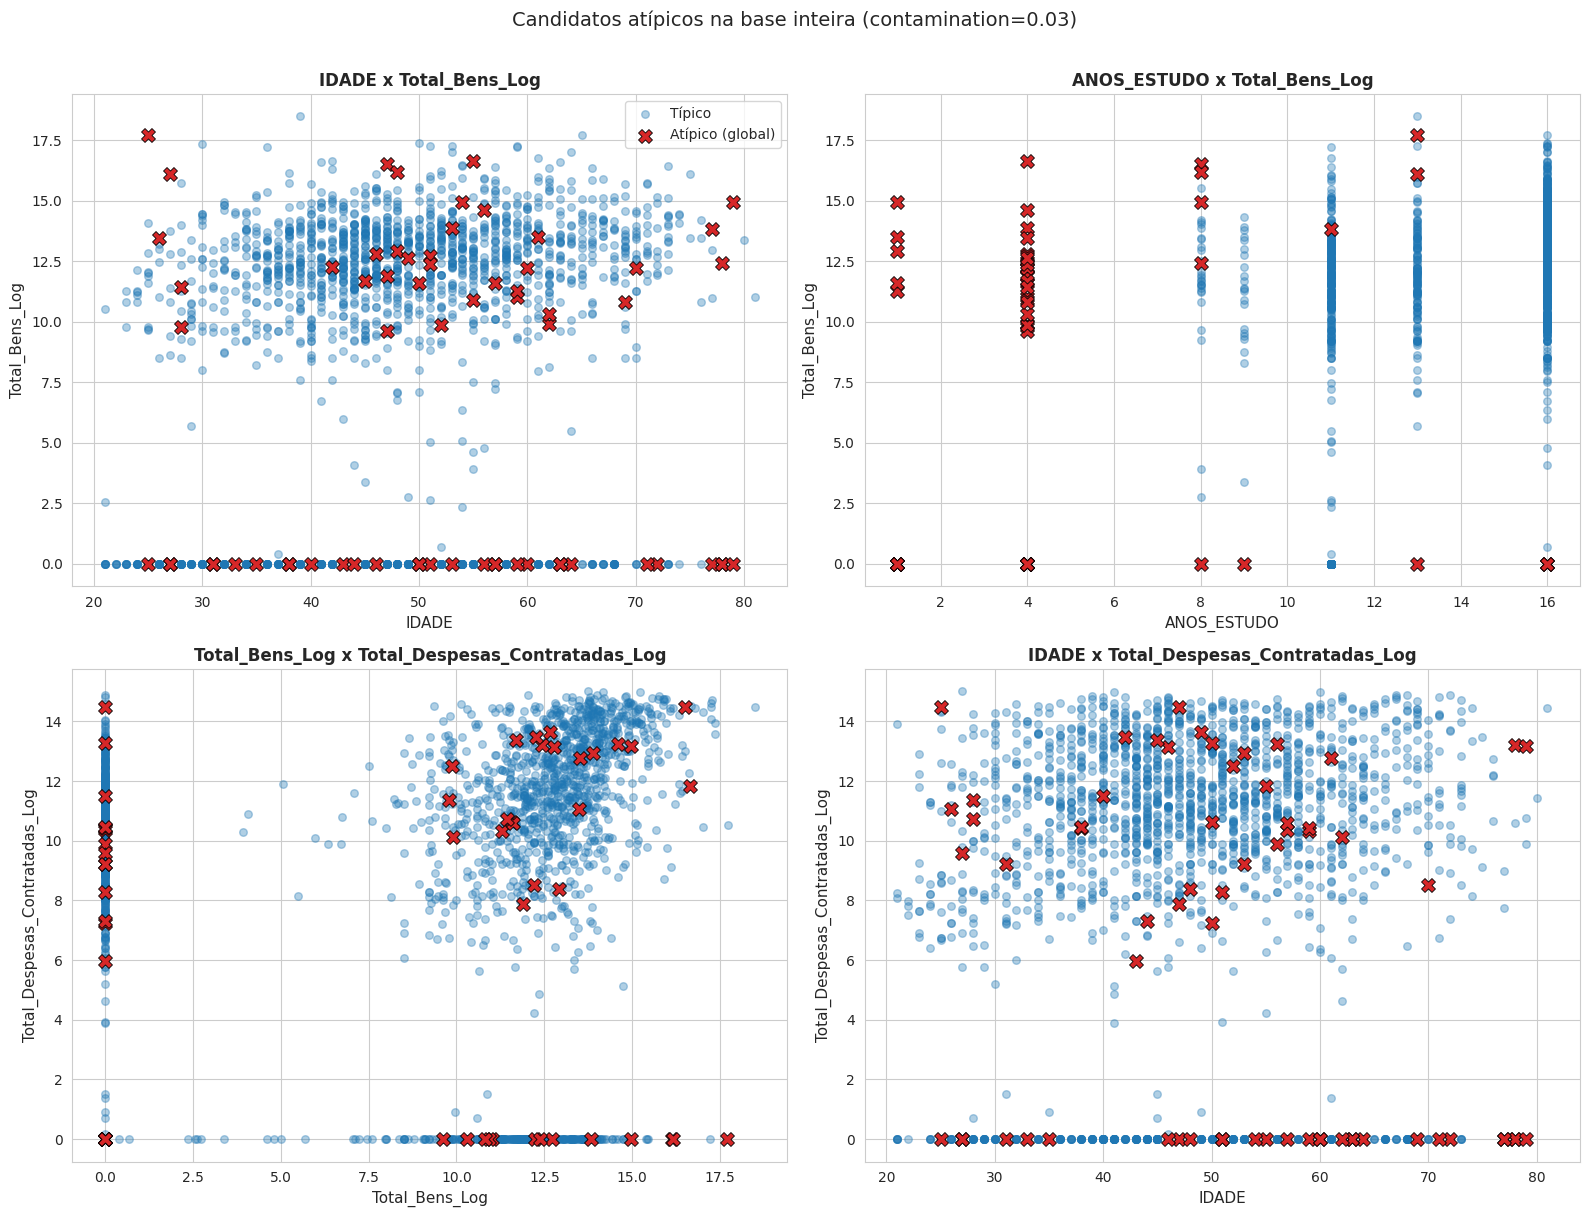

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
pares_plot = [
    ('IDADE', 'Total_Bens_Log'),
    ('ANOS_ESTUDO', 'Total_Bens_Log'),
    ('Total_Bens_Log', 'Total_Despesas_Contratadas_Log'),
    ('IDADE', 'Total_Despesas_Contratadas_Log')
]

axes = axes.flatten()
for i, (x_col, y_col) in enumerate(pares_plot):
    tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
    atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']
    axes[i].scatter(tipicos[x_col], tipicos[y_col], c='tab:blue', alpha=0.35, s=30, label='Típico')
    axes[i].scatter(atipicos[x_col], atipicos[y_col], c='tab:red', marker='X', s=100,
                   edgecolor='black', linewidth=0.6, label='Atípico (global)')
    axes[i].set_xlabel(x_col, fontsize=11)
    axes[i].set_ylabel(y_col, fontsize=11)
    axes[i].set_title(f'{x_col} x {y_col}', fontsize=12, fontweight='bold')

axes[0].legend(fontsize=10)
plt.suptitle(f'Candidatos atípicos na base inteira (contamination={contamination_global})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('images/notebook4/03_anomalias_globais_2d.png', dpi=300, bbox_inches='tight')
plt.show()


### Destaque 2D: Dispersão Patrimônio vs. Despesas com Casos Notórios Anotados

Projeção bidimensional focada na relação entre **Patrimônio Declarado (`Total_Bens_Log`)** e **Despesas Contratadas (`Total_Despesas_Contratadas_Log`)**, destacando as 66 anomalias globais e anotando individualmente os dois casos mais emblemáticos da eleição:
1. **Nathalia Pedrosa (PE):** 25 anos, com o maior patrimônio de toda a eleição (R$ 48,3 milhões) e R$ 0 gastos em campanha.
2. **Tiririca (CE):** Escolaridade básica (1 ano de instrução formal) operando uma campanha de R$ 2,45 milhões.


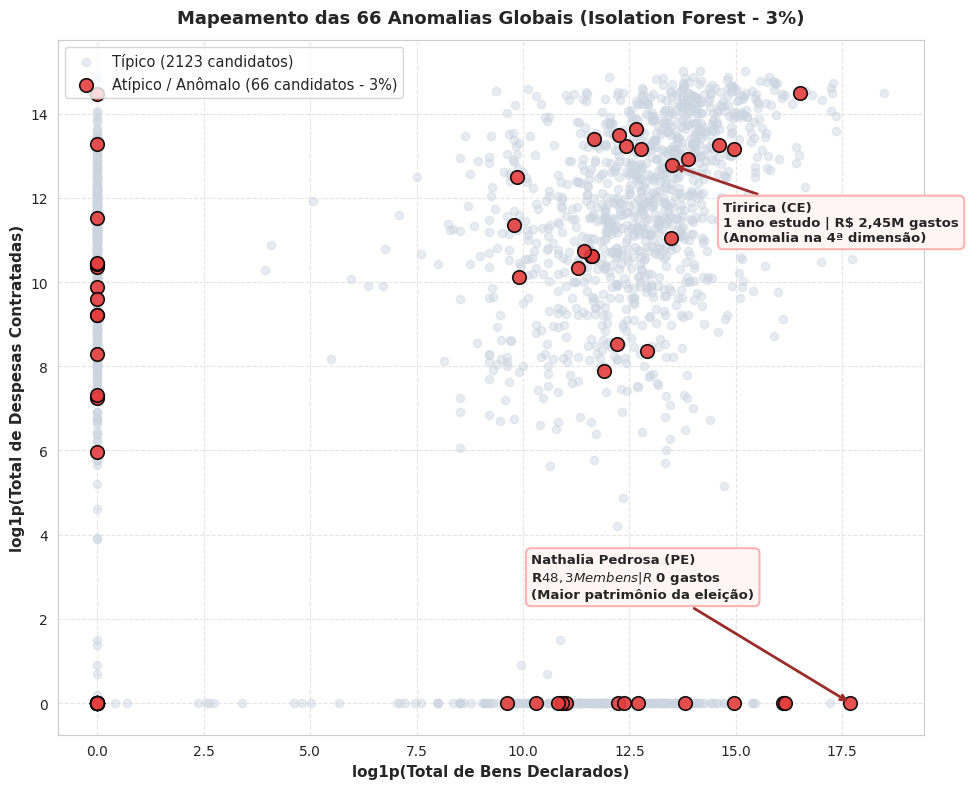

In [80]:
# ── Destaque 2D: Anomalias Globais com Anotação de Casos Notórios ──────────────
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

# Scatter dos candidatos típicos
tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']

ax.scatter(tipicos['Total_Bens_Log'], tipicos['Total_Despesas_Contratadas_Log'],
           color='#cbd5e0', alpha=0.45, s=35, label=f'Típico ({len(tipicos)} candidatos)')

# Scatter dos candidatos atípicos
ax.scatter(atipicos['Total_Bens_Log'], atipicos['Total_Despesas_Contratadas_Log'],
           color='#e53e3e', alpha=0.9, s=95, edgecolor='black', linewidth=1.2,
           label=f'Atípico / Anômalo ({len(atipicos)} candidatos - 3%)')

# Anotação de Nathalia Pedrosa
cand_nathalia = df_cluster[df_cluster['NM_URNA_CANDIDATO'].str.contains('NATHALIA', na=False, case=False)]
if not cand_nathalia.empty:
    row_n = cand_nathalia.iloc[0]
    ax.annotate(
        "Nathalia Pedrosa (PE)\nR$ 48,3M em bens | R$ 0 gastos\n(Maior patrimônio da eleição)",
        xy=(row_n['Total_Bens_Log'], row_n['Total_Despesas_Contratadas_Log']),
        xytext=(row_n['Total_Bens_Log'] - 7.5, row_n['Total_Despesas_Contratadas_Log'] + 2.5),
        arrowprops=dict(arrowstyle="->", color='#9b2c2c', lw=2),
        fontsize=9.5,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff5f5", ec="#feb2b2", lw=1.5)
    )

# Anotação de Tiririca
cand_tiririca = df_cluster[df_cluster['NM_URNA_CANDIDATO'].str.contains('TIRIRICA', na=False, case=False)]
if not cand_tiririca.empty:
    row_t = cand_tiririca.iloc[0]
    ax.annotate(
        "Tiririca (CE)\n1 ano estudo | R$ 2,45M gastos\n(Anomalia na 4ª dimensão)",
        xy=(row_t['Total_Bens_Log'], row_t['Total_Despesas_Contratadas_Log']),
        xytext=(row_t['Total_Bens_Log'] + 1.2, row_t['Total_Despesas_Contratadas_Log'] - 1.8),
        arrowprops=dict(arrowstyle="->", color='#9b2c2c', lw=2),
        fontsize=9.5,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff5f5", ec="#feb2b2", lw=1.5)
    )

ax.set_title('Mapeamento das 66 Anomalias Globais (Isolation Forest - 3%)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('log1p(Total de Bens Declarados)', fontsize=11, fontweight='bold')
ax.set_ylabel('log1p(Total de Despesas Contratadas)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10.5, loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('images/notebook4/03_anomalias_globais_2d_destaque.png', dpi=300, bbox_inches='tight')
import shutil
shutil.copy('images/notebook4/03_anomalias_globais_2d_destaque.png', 'images/imagens_apresentacao/slide6_anomalias_2d_destaque.png')
plt.show()


### O mesmo recorte, em 3D — e a explicação dos pontos que parecem "no meio"

> **Por que alguns pontos atípicos parecem estar misturados "no meio" da nuvem 3D?**  
> O modelo Isolation Forest operou simultaneamente em **4 dimensões** (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`, `Total_Despesas_Contratadas_Log`). No entanto, o gráfico 3D abaixo plota apenas 3 eixos espaciais (`IDADE`, `Total_Bens_Log` e `Total_Despesas_Contratadas_Log`).
>
> A **4ª dimensão (`ANOS_ESTUDO` / Escolaridade)** não possui um eixo geométrico no espaço 3D!  
> Como consequência, candidatos como **Tiririca (CE)** possui patrimônio, idade e despesas perfeitamente compatíveis com os demais candidatos, mas têm **apenas 1 a 4 anos de estudo (Lê e Escreve)** num ecossistema onde a imensa maioria possui Ensino Superior ($z = -4$ e $-5$). No gráfico 3D, eles são projetados no meio da nuvem, mas no espaço 4D real estão totalmente isolados no chão da escolaridade!

Gráfico 3D interativo salvo em: images/notebook4/04_grafico_3d_anomalias_global.html


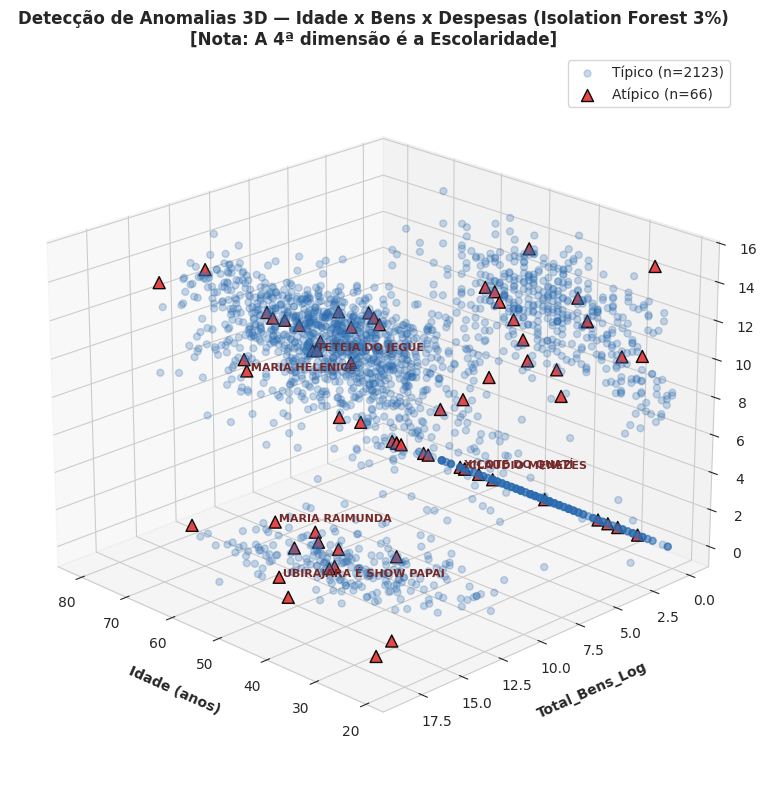

Versão estática salva em: images/notebook4/04_grafico_3d_anomalias_matplotlib.png


In [81]:
cores_iso = {'Típico': '#1f77b4', 'Atípico': '#d62728'}

fig3d = go.Figure()
for status, cor in cores_iso.items():
    sub = df_cluster[df_cluster['anomalia_global'] == status]
    
    customdata = np.stack((
        sub['NM_URNA_CANDIDATO'],
        sub['SG_UF'],
        sub['cluster'],
        sub['anomalia_global'],
        sub['score_global'],
        sub['motivo_global'],
        sub['DS_GRAU_INSTRUCAO'],
        sub['ANOS_ESTUDO'],
        sub['Total_Bens'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
        sub['Total_Despesas_Contratadas'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
    ), axis=-1)

    fig3d.add_trace(go.Scatter3d(
        x=sub['IDADE'], y=sub['Total_Bens_Log'], z=sub['Total_Despesas_Contratadas_Log'],
        mode='markers', name=status,
        customdata=customdata,
        marker=dict(
            size=4 if status == 'Típico' else 8,
            color=cor,
            symbol='circle' if status == 'Típico' else 'diamond',
            opacity=0.35 if status == 'Típico' else 0.95,
            line=dict(width=1, color='black'),
        ),
        hovertemplate=(
            '<b>%{customdata[0]} (%{customdata[1]}) — %{customdata[2]}</b><br>' +
            '<b>Status:</b> %{customdata[3]} (Score: %{customdata[4]:.3f})<br>' +
            '<b>Motivo do Isolamento:</b> %{customdata[5]}<br>' +
            '----------------------------------------<br>' +
            '<b>Idade:</b> %{x} anos<br>' +
            '<b>Escolaridade:</b> %{customdata[6]} (%{customdata[7]} anos)<br>' +
            '<b>Bens Declarados:</b> %{customdata[8]}<br>' +
            '<b>Despesas Contratadas:</b> %{customdata[9]}<extra></extra>'
        )
    ))

fig3d.update_layout(
    scene=dict(
        xaxis_title='IDADE (anos)',
        yaxis_title='Total_Bens_Log',
        zaxis_title='Total_Despesas_Contratadas_Log'
    ),
    title=f'Candidatos Atípicos (Visão Global 4D): Idade x Bens x Despesas (Passe o mouse para ver o motivo)',
    height=700, margin=dict(l=0, r=0, b=0, t=50),
)
fig3d.show()

# Salvar versão interativa em HTML
fig3d.write_html('images/notebook4/04_grafico_3d_anomalias_global.html')
print("Gráfico 3D interativo salvo em: images/notebook4/04_grafico_3d_anomalias_global.html")

# ── Versão Estática 3D em Matplotlib para Slides de Apresentação ──────────────
fig_3d_mpl = plt.figure(figsize=(12, 8))
ax_3d = fig_3d_mpl.add_subplot(111, projection='3d')
tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']

ax_3d.scatter(tipicos['IDADE'], tipicos['Total_Bens_Log'], tipicos['Total_Despesas_Contratadas_Log'],
             c='#2b6cb0', alpha=0.25, s=25, label=f'Típico (n={len(tipicos)})')
ax_3d.scatter(atipicos['IDADE'], atipicos['Total_Bens_Log'], atipicos['Total_Despesas_Contratadas_Log'],
             c='#e53e3e', marker='^', alpha=0.95, s=75, edgecolors='black', label=f'Atípico (n={len(atipicos)})')

# Destaque com rótulos para os casos mais discrepantes
destaques = atipicos.sort_values('score_global').head(6)
for _, r in destaques.iterrows():
    ax_3d.text(r['IDADE'], r['Total_Bens_Log'], r['Total_Despesas_Contratadas_Log'],
               f" {r['NM_URNA_CANDIDATO']}", fontsize=8, fontweight='bold', color='#742a2a')

ax_3d.set_xlabel('Idade (anos)', fontweight='bold', labelpad=10)
ax_3d.set_ylabel('Total_Bens_Log', fontweight='bold', labelpad=10)
ax_3d.set_zlabel('Total_Despesas_Log', fontweight='bold', labelpad=10)
ax_3d.set_title('Detecção de Anomalias 3D — Idade x Bens x Despesas (Isolation Forest 3%)\n[Nota: A 4ª dimensão é a Escolaridade]', fontsize=12, fontweight='bold')
ax_3d.legend(loc='upper right')
ax_3d.view_init(elev=22, azim=135)
plt.tight_layout()
plt.savefig('images/notebook4/04_grafico_3d_anomalias_matplotlib.png', dpi=300, bbox_inches='tight')
plt.show()
print("Versão estática salva em: images/notebook4/04_grafico_3d_anomalias_matplotlib.png")


---
## Detecção dentro de cada cluster: quem foge do padrão do próprio grupo?

Aqui está o detalhe metodológico essencial: se reaproveitássemos a mesma escala global (`X`, MinMax ajustado na base inteira) para rodar o Isolation Forest separadamente por cluster, um candidato só apareceria como atípico se já fosse extremo para a eleição inteira.

Para responder *"isso é atípico **para quem pertence a este perfil eleitoral**?"*, precisamos **padronizar de novo, usando apenas a média e o desvio-padrão de cada cluster**.

Aplicamos o modelo nos 4 clusters consolidados da Fase 2:
- **Estruturados** ($n = 1.142$)
- **Financiados** ($n = 449$)
- **Base Simbólica** ($n = 339$)
- **Patrimônio Sem Campanha** ($n = 259$)

Usamos uma taxa de contaminação adaptativa proporcional ao tamanho de cada grupo para calibrar o volume de anomalias internas.

In [82]:
resultados_cluster = []

for nome in ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']:
    sub_df = df_cluster[df_cluster['cluster'] == nome].copy()
    sub_idx = sub_df.index.to_numpy()
    n = len(sub_idx)

    X_cluster = sub_df[colunas_driver].values
    scaler_c = StandardScaler()
    X_cluster_padronizado = scaler_c.fit_transform(X_cluster)
    z_df_cluster = pd.DataFrame(X_cluster_padronizado, columns=colunas_driver, index=sub_idx)

    contaminacao_cluster = min(max(0.03, 3 / n), 0.08)
    iso_cluster = IsolationForest(contamination=contaminacao_cluster, random_state=SEMENTE, n_estimators=200)
    pred_cluster = iso_cluster.fit_predict(X_cluster_padronizado)
    score_cluster = iso_cluster.decision_function(X_cluster_padronizado)

    n_atipicos = int((pred_cluster == -1).sum())
    print(f"{nome} (n={n}, contamination={contaminacao_cluster:.3f}): {n_atipicos} atípicos dentro do grupo")

    motivos_c = [diagnosticar_motivo(sub_df.loc[i], z_df_cluster.loc[i]) for i in sub_idx]

    resultados_cluster.append(pd.DataFrame({
        'indice_original': sub_idx,
        'anomalia_cluster': np.where(pred_cluster == -1, 'Atípico', 'Típico'),
        'score_cluster': score_cluster,
        'motivo_cluster': motivos_c
    }))

anomalia_cluster_df = pd.concat(resultados_cluster).set_index('indice_original').sort_index()
df_cluster['anomalia_cluster'] = anomalia_cluster_df['anomalia_cluster'].values
df_cluster['score_cluster'] = anomalia_cluster_df['score_cluster'].values
df_cluster['motivo_cluster'] = anomalia_cluster_df['motivo_cluster'].values

Estruturados (n=328, contamination=0.030): 10 atípicos dentro do grupo
Financiados (n=460, contamination=0.030): 14 atípicos dentro do grupo
Base Simbólica (n=1153, contamination=0.030): 35 atípicos dentro do grupo
Patrimônio Sem Campanha (n=248, contamination=0.030): 8 atípicos dentro do grupo


In [83]:
colunas_ficha_cluster = [
    'NM_URNA_CANDIDATO', 'SG_UF', 'DS_OCUPACAO', 'IDADE',
    'DS_GRAU_INSTRUCAO', 'Total_Bens', 'Total_Despesas_Contratadas', 'motivo_cluster', 'score_cluster'
]

for nome in ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']:
    print(f"\n=== {nome}: Mais atípicos DENTRO do grupo ===")
    sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == 'Atípico')]
    display(sub.sort_values('score_cluster')[colunas_ficha_cluster].head(8))


=== Estruturados: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
1308,SERGIO DO REAL PREÇO,PB,COMERCIÁRIO,43,ENSINO FUNDAMENTAL INCOMPLETO,0.00,390.00,Despesas Super-Altas: R$ 390 (z=11.2),-0.11
1025,MARINA - COLETIVO DAS PRETAS,MA,PROFESSOR DE ENSINO FUNDAMENTAL,62,SUPERIOR COMPLETO,0.00,100.00,Despesas Super-Altas: R$ 100 (z=8.6),-0.09
1925,DARA NETO,PI,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",29,SUPERIOR INCOMPLETO,293.75,0.00,Patrimônio Super-Alto: R$ 294 (z=8.6),-0.08
1844,CICERO ROMÃO,PI,ADVOGADO,56,SUPERIOR COMPLETO,120.85,0.00,Patrimônio Super-Alto: R$ 121 (z=7.3),-0.07
445,PROFESSOR REGINALDO ALVES,BA,PROFESSOR DE ENSINO SUPERIOR,41,SUPERIOR COMPLETO,0.00,47.95,Despesas Super-Altas: R$ 48 (z=7.2),-0.05
1798,ERIVAN COSTA,PI,EMPRESÁRIO,51,ENSINO MÉDIO COMPLETO,0.00,50.00,Despesas Super-Altas: R$ 50 (z=7.3),-0.02
1926,AUGUSTO FERREIRA,PI,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",21,ENSINO MÉDIO COMPLETO,12.00,0.00,Patrimônio Super-Alto: R$ 12 (z=3.8),-0.02
1267,NINO DO RANGEL,PB,DESENHISTA,51,ENSINO MÉDIO COMPLETO,150.00,0.00,Patrimônio Super-Alto: R$ 150 (z=7.6),-0.00



=== Financiados: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
1801,PR. JOSIMAR CARVALHO,PI,OUTROS,64,ENSINO MÉDIO COMPLETO,240.00,"3,500.00",Patrimônio Super-Alto: R$ 240 (z=9.0),-0.11
437,CECILIA COSTA,BA,OUTROS,43,SUPERIOR COMPLETO,389.00,"23,797.50",Patrimônio Super-Alto: R$ 389 (z=9.8),-0.10
39,DAFNE ORION,AL,SERVIDOR PÚBLICO ESTADUAL,48,ENSINO MÉDIO COMPLETO,853.83,"48,748.67",Patrimônio Super-Alto: R$ 854 (z=11.1),-0.10
375,SANDRO BAHIENSE,BA,VEREADOR,54,ENSINO MÉDIO COMPLETO,158.68,"149,614.50",Patrimônio Super-Alto: R$ 159 (z=8.3),-0.08
653,FLAVIO FG,CE,POLICIAL MILITAR,55,ENSINO FUNDAMENTAL COMPLETO,50.00,"29,216.04",Patrimônio Super-Alto: R$ 50 (z=6.4),-0.06
1332,POLLY DO ADOTA,PB,OUTROS,44,SUPERIOR COMPLETO,58.47,"53,700.00",Patrimônio Super-Alto: R$ 58 (z=6.7),-0.05
1896,EMILY SANTOS,PI,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",25,ENSINO MÉDIO INCOMPLETO,0.00,"1,928,362.69","Despesas Super-Altas: R$ 1,928,363 (z=2.3)",-0.04
1885,IRMÃO VELOSO,PI,TRABALHADOR RURAL,61,ENSINO FUNDAMENTAL COMPLETO,0.00,430.00,Despesas Nulas/Muito Baixas (z=-2.4),-0.04



=== Base Simbólica: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
338,DITINHO AVIVIP,BA,EMPRESÁRIO,55,ENSINO FUNDAMENTAL INCOMPLETO,"16,985,230.19","136,268.50",Escolaridade Atípica: ENSINO FUNDAMENTAL INCOMPLETO (z=-4.0),-0.08
2035,GABRIEL NUNES,RN,EMPRESÁRIO,26,ENSINO FUNDAMENTAL INCOMPLETO,"712,000.00","63,332.75",Escolaridade Atípica: ENSINO FUNDAMENTAL INCOMPLETO (z=-4.0),-0.07
704,MARIA HELENICE,CE,APOSENTADO (EXCETO SERVIDOR PÚBLICO),70,ENSINO FUNDAMENTAL INCOMPLETO,"200,000.00","5,000.00",Escolaridade Atípica: ENSINO FUNDAMENTAL INCOMPLETO (z=-4.0),-0.06
757,TIRIRICA,CE,DEPUTADO,61,LÊ E ESCREVE,"732,678.62","353,553.10",Escolaridade Atípica: LÊ E ESCREVE (z=-5.2),-0.06
761,GRAU BIEL,CE,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",28,ENSINO FUNDAMENTAL INCOMPLETO,"18,000.00","85,568.80",Escolaridade Atípica: ENSINO FUNDAMENTAL INCOMPLETO (z=-4.0),-0.06
2042,PALHAÇO FUXIQUINHO,RN,ARTISTA DE CIRCO,48,LÊ E ESCREVE,"410,000.00","4,322.50",Escolaridade Atípica: LÊ E ESCREVE (z=-5.2),-0.06
500,TETEIA DO JEGUE,BA,OUTROS,59,LÊ E ESCREVE,"80,000.00","30,502.50",Escolaridade Atípica: LÊ E ESCREVE (z=-5.2),-0.05
873,PASTOR LAURO,CE,COMERCIANTE,62,ENSINO FUNDAMENTAL INCOMPLETO,"20,000.00","24,934.82",Escolaridade Atípica: ENSINO FUNDAMENTAL INCOMPLETO (z=-4.0),-0.05



=== Patrimônio Sem Campanha: Mais atípicos DENTRO do grupo ===


,NM_URNA_CANDIDATO,SG_UF,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
838,UBIRAJARA É SHOW PAPAI,CE,COMERCIANTE,54,LÊ E ESCREVE,"3,162,500.00",0.00,Escolaridade Atípica: LÊ E ESCREVE (z=-3.9),-0.06
1133,ANTONIA CARIONGO,MA,TRABALHADOR RURAL,46,ENSINO MÉDIO COMPLETO,"5,000.00",427.20,Despesas Super-Altas: R$ 427 (z=6.6),-0.06
1804,PEREIRA SÁ,PI,AGRICULTOR,46,ENSINO FUNDAMENTAL COMPLETO,"117,000.00",319.00,Despesas Super-Altas: R$ 319 (z=6.3),-0.06
455,JANDA DO CONSIGNADO,BA,OUTROS,62,ENSINO MÉDIO COMPLETO,"624,900.00",300.01,Despesas Super-Altas: R$ 300 (z=6.2),-0.05
472,LIS MOREIRA,BA,PSICÓLOGO,41,SUPERIOR COMPLETO,"2,500,000.00",171.23,Despesas Super-Altas: R$ 171 (z=5.6),-0.04
1617,NATHALIA PEDROSA,PE,OUTROS,25,SUPERIOR INCOMPLETO,"48,343,333.34",0.00,"Patrimônio Super-Alto: R$ 48,343,333 (z=3.2)",-0.04
529,ANDRÉ AKIO,BA,SERVIDOR PÚBLICO MUNICIPAL,41,SUPERIOR COMPLETO,"230,000.00",130.00,Despesas Super-Altas: R$ 130 (z=5.3),-0.01
2002,FRAN BARBEIRO,RN,CABELEIREIRO E BARBEIRO,52,ENSINO MÉDIO COMPLETO,"42,000.00",278.88,Despesas Super-Altas: R$ 279 (z=6.1),-0.00


### O mesmo recorte, em 3D — filtrando por cluster

Mesma ideia do gráfico 3D global, agora um por cluster: escolham no menu qual grupo olhar (cada cluster usa a sua **própria** padronização, então os pontos vermelhos aqui são atípicos *dentro daquele grupo*, não em relação à base inteira). Os eixos ficam fixos entre um cluster e outro, pra dar pra comparar a posição relativa.


In [84]:
nomes_clusters_ordenados = ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']
n_status = len(cores_iso)

fig3d_cluster = go.Figure()
for idx_cluster, nome in enumerate(nomes_clusters_ordenados):
    for status, cor in cores_iso.items():
        sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == status)]
        
        customdata = np.stack((
            sub['NM_URNA_CANDIDATO'],
            sub['SG_UF'],
            sub['cluster'],
            sub['anomalia_cluster'],
            sub['score_cluster'],
            sub['motivo_cluster'],
            sub['DS_GRAU_INSTRUCAO'],
            sub['ANOS_ESTUDO'],
            sub['Total_Bens'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
            sub['Total_Despesas_Contratadas'].map(lambda x: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
        ), axis=-1)

        fig3d_cluster.add_trace(go.Scatter3d(
            x=sub['IDADE'], y=sub['Total_Bens_Log'], z=sub['Total_Despesas_Contratadas_Log'],
            mode='markers', name=status,
            customdata=customdata,
            marker=dict(
                size=4 if status == 'Típico' else 8,
                color=cor,
                symbol='circle' if status == 'Típico' else 'diamond',
                opacity=0.35 if status == 'Típico' else 0.95,
                line=dict(width=1, color='black'),
            ),
            hovertemplate=(
                '<b>%{customdata[0]} (%{customdata[1]}) — %{customdata[2]}</b><br>' +
                '<b>Status Local:</b> %{customdata[3]} (Score: %{customdata[4]:.3f})<br>' +
                '<b>Desvio Interno no Cluster:</b> %{customdata[5]}<br>' +
                '----------------------------------------<br>' +
                '<b>Idade:</b> %{x} anos<br>' +
                '<b>Escolaridade:</b> %{customdata[6]} (%{customdata[7]} anos)<br>' +
                '<b>Bens:</b> %{customdata[8]}<br>' +
                '<b>Despesas:</b> %{customdata[9]}<extra></extra>'
            ),
            visible=(idx_cluster == 0),
            legendgroup=status,
            showlegend=(idx_cluster == 0),
        ))

botoes_cluster = []
for idx_cluster, nome in enumerate(nomes_clusters_ordenados):
    visibilidade = [False] * (len(nomes_clusters_ordenados) * n_status)
    for j in range(n_status):
        visibilidade[idx_cluster * n_status + j] = True
    botoes_cluster.append(dict(
        label=nome, method='update',
        args=[{'visible': visibilidade}, {'title': f'Atípicos dentro do cluster: {nome} (Passe o mouse para ver o motivo)'}],
    ))

fig3d_cluster.update_layout(
    scene=dict(
        xaxis_title='IDADE (anos)',
        yaxis_title='Total_Bens_Log',
        zaxis_title='Total_Despesas_Contratadas_Log',
        xaxis=dict(range=[df_cluster['IDADE'].min() - 2, df_cluster['IDADE'].max() + 2]),
        yaxis=dict(range=[df_cluster['Total_Bens_Log'].min() - 0.5, df_cluster['Total_Bens_Log'].max() + 0.5]),
        zaxis=dict(range=[df_cluster['Total_Despesas_Contratadas_Log'].min() - 0.5, df_cluster['Total_Despesas_Contratadas_Log'].max() + 0.5]),
    ),
    updatemenus=[dict(active=0, buttons=botoes_cluster, x=0.02, y=1.05, xanchor='left')],
    title=f'Atípicos dentro do cluster: {nomes_clusters_ordenados[0]} (Passe o mouse para ver o motivo)',
    height=700, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d_cluster.show()

# Salvar versão interativa em HTML
fig3d_cluster.write_html('images/notebook4/05_grafico_3d_anomalias_cluster.html')
print("Gráfico 3D interativo por cluster salvo em: images/notebook4/05_grafico_3d_anomalias_cluster.html")


Gráfico 3D interativo por cluster salvo em: images/notebook4/05_grafico_3d_anomalias_cluster.html


### Comparando: global vs. dentro do cluster

Quatro combinações possíveis pra cada candidato: atípico nos dois recortes (destoa de tudo, robusto), só globalmente, só dentro do cluster, ou típico nos dois. O caso mais interessante pedagogicamente é o **"só dentro do cluster"**: candidatos que passam despercebidos quando olhamos a base inteira, mas que não se parecem com seus próprios colegas de grupo.


anomalia_cluster,Atípico,Típico
anomalia_global \ anomalia_cluster,,
Atípico,30,36
Típico,37,2086



37 candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):


,NM_URNA_CANDIDATO,SG_UF,cluster,DS_OCUPACAO,IDADE,DS_GRAU_INSTRUCAO,Total_Bens,Total_Despesas_Contratadas,motivo_cluster,score_cluster
1801,PR. JOSIMAR CARVALHO,PI,Financiados,OUTROS,64,ENSINO MÉDIO COMPLETO,240.00,"3,500.00",Patrimônio Super-Alto: R$ 240 (z=9.0),-0.11
437,CECILIA COSTA,BA,Financiados,OUTROS,43,SUPERIOR COMPLETO,389.00,"23,797.50",Patrimônio Super-Alto: R$ 389 (z=9.8),-0.10
39,DAFNE ORION,AL,Financiados,SERVIDOR PÚBLICO ESTADUAL,48,ENSINO MÉDIO COMPLETO,853.83,"48,748.67",Patrimônio Super-Alto: R$ 854 (z=11.1),-0.10
1025,MARINA - COLETIVO DAS PRETAS,MA,Estruturados,PROFESSOR DE ENSINO FUNDAMENTAL,62,SUPERIOR COMPLETO,0.00,100.00,Despesas Super-Altas: R$ 100 (z=8.6),-0.09
1925,DARA NETO,PI,Estruturados,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",29,SUPERIOR INCOMPLETO,293.75,0.00,Patrimônio Super-Alto: R$ 294 (z=8.6),-0.08
375,SANDRO BAHIENSE,BA,Financiados,VEREADOR,54,ENSINO MÉDIO COMPLETO,158.68,"149,614.50",Patrimônio Super-Alto: R$ 159 (z=8.3),-0.08
1844,CICERO ROMÃO,PI,Estruturados,ADVOGADO,56,SUPERIOR COMPLETO,120.85,0.00,Patrimônio Super-Alto: R$ 121 (z=7.3),-0.07
653,FLAVIO FG,CE,Financiados,POLICIAL MILITAR,55,ENSINO FUNDAMENTAL COMPLETO,50.00,"29,216.04",Patrimônio Super-Alto: R$ 50 (z=6.4),-0.06
1133,ANTONIA CARIONGO,MA,Patrimônio Sem Campanha,TRABALHADOR RURAL,46,ENSINO MÉDIO COMPLETO,"5,000.00",427.20,Despesas Super-Altas: R$ 427 (z=6.6),-0.06
1804,PEREIRA SÁ,PI,Patrimônio Sem Campanha,AGRICULTOR,46,ENSINO FUNDAMENTAL COMPLETO,"117,000.00",319.00,Despesas Super-Altas: R$ 319 (z=6.3),-0.06


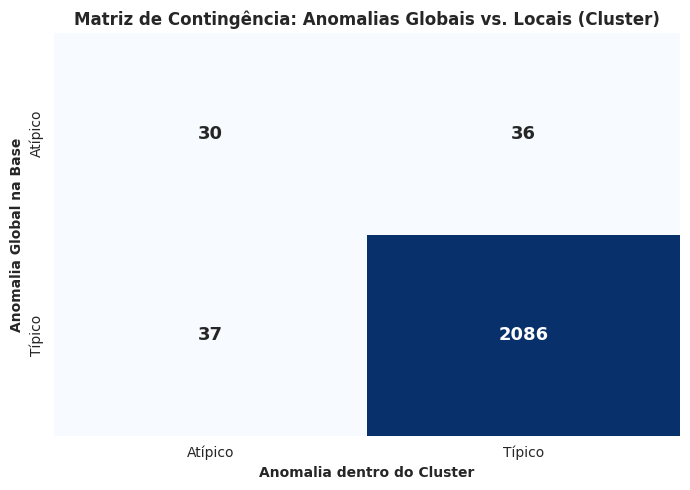

In [85]:
tabela_comparacao = pd.crosstab(df_cluster['anomalia_global'], df_cluster['anomalia_cluster'])
tabela_comparacao.index.name = 'anomalia_global \\ anomalia_cluster'
display(tabela_comparacao)

so_no_cluster = df_cluster[(df_cluster['anomalia_global'] == 'Típico') & (df_cluster['anomalia_cluster'] == 'Atípico')]
print(f"\n{len(so_no_cluster)} candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):")
display(so_no_cluster[colunas_ficha_anomalia + ['motivo_cluster', 'score_cluster']].sort_values('score_cluster').head(15))

# ── Visualização da Matriz de Contingência (Global vs Cluster) ────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(tabela_comparacao, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Matriz de Contingência: Anomalias Globais vs. Locais (Cluster)', fontsize=12, fontweight='bold')
plt.xlabel('Anomalia dentro do Cluster', fontweight='bold')
plt.ylabel('Anomalia Global na Base', fontweight='bold')
plt.tight_layout()
plt.savefig('images/notebook4/06_matriz_contingencia_anomalias.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Fechamento da Fase 4 e Conclusão do Pipeline Completo

Com esta Fase 4, consolidamos o pipeline analítico de ponta a ponta para **Deputado Federal no Nordeste (Eleições 2026)**:

1. **Fase 0 (Preparação):** Leitura de 3 bases do TSE com mapeamento relacional de prestação de contas dos 9 estados nordestinos e imputação defensiva.
2. **Fase 1 (Descritiva):** Caracterização bimodal dos gastos eleitorais (*zero-inflated*), assimetria patrimonial e dispersão por UF.
3. **Fase 2 (Clusterização):** Identificação matemática formal de $k=4$ e construção dos 4 arquétipos eleitorais via Radar Polar e Matriz de Transição.
4. **Fase 3 (Regras de Associação):** Descoberta de regras socioprofissionais e partidárias com suporte calibrado e grafos interativos.
5. **Fase 4 (Detecção de Anomalias):** Mapeamento de 66 anomalias globais e anomalias locais por cluster via Isolation Forest, isolando candidaturas com discrepâncias extremas entre patrimônio, estudo e recursos de campanha.


In [ ]:
# ── Download das Imagens do Notebook 4 em ZIP ─────────────────────────────────
import os
import zipfile

zip_path = 'images/notebook4.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook4'):
        for file in sorted(files):
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)

arquivos_salvos = [f for f in sorted(os.listdir('images/notebook4')) if f.endswith(('.png', '.html'))]
print(f"{len(arquivos_salvos)} arquivos visuais salvos em 'images/notebook4/':")
for arq in arquivos_salvos:
    tipo = 'HTML' if arq.endswith('.html') else 'PNG'
    print(f"   {tipo} {arq}")
print(f"\nArquivo ZIP consolidado pronto para download: {zip_path}")


8 arquivos visuais salvos em 'images/notebook4/':
   📸 PNG 01_intuicao_isolation_forest.png
   📸 PNG 02_arvore_cortes_e_profundidade.png
   📸 PNG 03_anomalias_globais_2d.png
   📸 PNG 03_anomalias_globais_2d_destaque.png
   HTML 04_grafico_3d_anomalias_global.html
   📸 PNG 04_grafico_3d_anomalias_matplotlib.png
   HTML 05_grafico_3d_anomalias_cluster.html
   📸 PNG 06_matriz_contingencia_anomalias.png

Arquivo ZIP consolidado pronto para download: images/notebook4.zip
